<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**
Why is this problem important to solve?

ChicStyle is a growing fashion retail platform that sees massive spikes in customer activity during festive seasons and holiday sales. As shoppers buy clothing and accessories for celebrations, the volume of incoming reviews rises sharply — they arrive every hour, ranging from positive praise to urgent complaints about fit, delivery delays, product defects, or sizing issues. During these high-pressure periods, even a slight delay in reading or responding to feedback can have serious consequences. If the retail team fails to act quickly, customers feel ignored at an emotionally significant time, which leads to frustration, spoiled shopping experiences, and reduced trust in the brand. The cost is twofold: immediate lost sales, and longer-term damage to repeat purchases and loyalty. To protect both revenue and reputation at peak periods, ChicStyle needs a system that can process thousands of reviews instantly, accurately, and with business context.

Customer reviews are direct, unsolicited signals about what is working and what is failing across the product and service experience. Analyzing them well lets a retailer:

- **Catch problems early** — defects, sizing inconsistencies, and delivery failures surface in reviews before they show up in returns and churn.
- **Prioritize action** — separating urgent complaints from minor suggestions lets limited support and operations capacity focus where it matters most.
- **Improve products faster** — recurring themes (e.g., a dress that runs small) feed directly back to merchandising and quality teams.
- **Protect brand reputation and loyalty** — responding promptly, especially to negative feedback, signals that the brand listens and converts a bad experience into a recoverable one.
- **Turn unstructured text into business intelligence** — at scale, reviews become a measurable, trackable input to decisions rather than anecdotes.

The challenge is volume and nuance. Traditional rule-based NLP struggles with mixed feedback — for example, *"The fit is great but the color was not as per the product image"* contains both a positive and a negative opinion, and older systems tend to collapse it into a single sentiment, losing critical detail. This is precisely the gap a Generative AI approach is meant to close.


### **Objective**
What is the intended goal?

Build a **Generative AI feedback system** that uses prompt engineering — **Zero-Shot, Few-Shot, and Chain-of-Thought (CoT)** prompting — to transform large volumes of raw customer reviews into structured, actionable intelligence. Specifically, the system should:

- **Analyze and categorize sentiment in real time** (positive, negative, neutral), including mixed feedback.
- **Detect which product or service** each piece of feedback refers to (e.g., fit, quality, delivery, price), even though there is no explicit service column — it is inferred from the review text.
- **Summarize insights by product category and urgency level**, where category comes from existing department data and urgency (high / medium / low) is inferred from the language of the review.
- **Automatically send short, personalized messages** to customers based on sentiment — thanking them for positive feedback, acknowledging neutral comments, and apologizing for negative ones while letting them know a team member will follow up.
- **Generate short, actionable reports** for retail teams.

Manual review reading does not scale to thousands of reviews per hour during peak sales, and it is slow, inconsistent, and expensive. Automating it lets ChicStyle:

- **Respond in real time** rather than hours or days later, so customers feel heard during emotionally important purchases.
- **Act on issues quickly** — high-urgency complaints are flagged and routed instead of being buried in a backlog.
- **Improve product quality faster** by surfacing recurring themes automatically.
- **Apply consistent, context-aware judgment** at scale, capturing nuance that rule-based models miss.
- **Free up human teams** to focus on resolution and relationships instead of triage.

In short, the goal is to turn massive unstructured feedback into meaningful, real-time business intelligence that protects revenue, reputation, and loyalty during the moments that matter most.

### **Dataset Used for the Notebook**
Describe dataset used for this project.

#### **Description**

The project uses the **"Women's E-Commerce Clothing Reviews"** dataset: **23,486 reviews with 10 columns**. 
Each row is a single customer review of a clothing item, combining structured metadata (rating, recommendation, department) with unstructured review text.

| Column                  | Description                                                  | Type             |
| ----------------------- | ------------------------------------------------------------ | ---------------- |
| Clothing.ID             | Unique ID for each piece of clothing                         | Integer          |
| Age                     | Age of the reviewer                                          | Positive integer |
| Title                   | Title of the review                                          | String           |
| Review.Text             | Main body of the review                                      | String           |
| Rating                  | Product score, 1 (worst) to 5 (best)                         | Ordinal integer  |
| Recommended.IND         | Whether the customer recommends the product (1 = yes, 0 = no) | Binary           |
| Positive.Feedback.Count | Number of other customers who found the review helpful       | Positive integer |
| Division.Name           | High-level division of the product                           | Categorical      |
| Department.Name         | Specific department of the product                           | Categorical      |
| Class.Name              | Product class (finer than department)                        | Categorical      |

Reviewers skew middle-aged: ages range from **18 to 99** with a **mean of ~43** and a median of 41. Reviews average about **60 words** each.

> **Note on scope:** For the GenAI prompt-engineering and evaluation work, only a **sample of 50 reviews** is processed (5–10 during initial prompt testing, scaling to 50 for final evaluation) to stay within the API budget. The full 23,486-row dataset is only used for the exploratory analysis.

#### **Key Patterns Summary**
*Ratings — strongly skewed positive:*

| Rating | Count  | Share |
| ------ | ------ | ----- |
| 5      | 13,131 | 55.9% |
| 4      | 5,077  | 21.6% |
| 3      | 2,871  | 12.2% |
| 2      | 1,565  | 6.7%  |
| 1      | 842    | 3.6%  |

About **77.5% of reviews are 4–5 stars** and **82.2% of customers recommend** the product. This class imbalance matters: negative reviews are the minority but carry the highest business urgency, so the system must not let the volume of praise drown out the smaller stream of complaints. Rating aligns tightly with recommendation — the average rating is **4.6 among recommenders vs. 2.3 among non-recommenders** — confirming the two signals are consistent.

*Departments — concentrated in a few categories:*

| Department | Count  |
| ---------- | ------ |
| Tops       | 10,468 |
| Dresses    | 6,319  |
| Bottoms    | 3,799  |
| Intimate   | 1,735  |
| Jackets    | 1,032  |
| Trend      | 119    |

**Tops and Dresses together account for ~71%** of all reviews, so feedback volume — and therefore the operational load and the biggest opportunity for product improvement — is concentrated there. At the division level, **General (13,850)** and **General Petite (8,120)** dominate, with Intimates smallest. The finest level (Class.Name) is led by Dresses, Knits, and Blouses.

*Fit and sizing dominate both ends:*

- **Positive reviews (4–5★):** *love, great, perfect, fit, size, fabric, color, dress, top, comfortable* — praise centers on fit, fabric, and overall delight.
- **Negative reviews (1–2★):** *too, small, fabric, fit, size, ordered, look, back* — complaints cluster around **fit/sizing** ("too small"), **fabric quality**, and **returns** ("ordered… back").

The recurring takeaway is that **fit and sizing are the single most important theme across the entire experience** — they drive both the strongest praise and the strongest complaints. Fabric/quality and color-vs-image expectations are the next most common pain points.

#### **Data treatments / preprocessing required**
- **Missing values:** `Review.Text` is missing in **845 rows** and `Title` in **3,810 rows**; `Division.Name`, `Department.Name`, and `Class.Name` are each missing in **14 rows**. Rows with no review text cannot be analyzed by the language model and should be dropped (or excluded from the sampled set); the 14 rows missing category fields can be dropped or imputed as "Unknown."
- **CSV parsing:** the file is **semicolon-delimited** with an unnamed leading index column — it must be read with the correct separator and index handling, and review text contains embedded quotes/commas that must be parsed cleanly.
- **Text cleaning for analysis:** for EDA and word clouds, lowercase the text, strip punctuation, and remove stopwords; keep the raw text intact for the LLM so it retains nuance.
- **Sampling:** draw a representative ~50-review sample for prompt experiments, ideally spanning the rating range and major departments so evaluation isn't dominated by 5-star Tops reviews.
- **Type checks:** confirm `Rating` (1–5) and `Recommended.IND` (0/1) fall in valid ranges; treat `Rating`, `Department.Name`, and `Division.Name` as categ/ordinal as appropriate.
- **No new labels needed for category/urgency:** the project intentionally does **not** add sentiment, "Category," or "urgency" columns to the data — these are generated by the LLM from the review text at analysis time, with product category drawn from the existing `Department.Name`.

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [1]:
# Install the required libraries for the project
# We use `uv` (a fast Python package manager) instead of pip.
# The `!` prefix runs these as shell commands from within the notebook.
# `uv add` adds each package to the project's environment (pyproject.toml / uv.lock).

# --- Data handling & numerical computing ---
!uv add numpy pandas

# --- Visualization libraries ---
!uv add matplotlib seaborn wordcloud plotly

# --- Machine learning metrics (scikit-learn) ---
!uv add scikit-learn

# --- Progress bars for long-running loops ---
!uv add tqdm

# --- OpenAI client for LLM-based analysis ---
!uv add openai

# --- IPython for rich in-notebook display (display, etc.) ---
!uv add ipython


Resolved 76 packages in 16ms
Checked 71 packages in 5ms
Resolved 76 packages in 2ms
Checked 71 packages in 0.96ms
Resolved 76 packages in 2ms
Checked 71 packages in 0.99ms
Resolved 76 packages in 2ms
Checked 71 packages in 0.96ms
Resolved 76 packages in 2ms
Checked 71 packages in 0.97ms
Resolved 76 packages in 2ms
Checked 71 packages in 0.96ms


In [2]:
# Import the required libraries for the project

# --- Core Utilities ---
import time
import json
import re
import numpy as np
from typing import Dict, List, Optional, Any, Tuple

# --- Data Handling ---
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

# --- Machine Learning Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --- Progress Bar ---
from tqdm import tqdm

# --- OpenAI Client ---
import openai

# Set global plot style
sns.set_style("whitegrid")


### **Data Loading**
### Loading and Understanding the Data


In [3]:
### Loading and Understanding the Data
# Load the dataset from 'data/Dataset - Real-Time Retail Feedback Intelligence.csv'. 
# Note: the separator is a semicolon (';') and the first column should be used as the index.

# Path to the dataset file:
data_path = "data/Dataset - Real-Time Retail Feedback Intelligence.csv"

# Read the CSV into a DataFrame:
# - sep=";"      -> the file uses a semicolon as the column separator
# - index_col=0  -> use the first (unnamed) column as the DataFrame index
df = pd.read_csv(data_path, sep=";", index_col=0)

# Display the loaded DataFrame to verify it was read correctly
display(df)

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


### **Data Overview**


#### Dimensions and First few rows of the dataset

In [4]:
# ----------------------------------------------------------------------
# Data Overview
# A quick, structured look at the dataset before any cleaning/analysis.
# ----------------------------------------------------------------------

# First few rows of the dataset
# head() shows the top 5 rows so we can eyeball the structure and values.
print("First few rows of the dataset:")
display(df.head())

# Dimensions
# shape returns a (rows, columns) tuple describing the size of the data.
print(f"\nDimensions (rows, columns): {df.shape}")
print(f"- Number of rows (records): {df.shape[0]}")
print(f"- Number of columns (features): {df.shape[1]}")



First few rows of the dataset:


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Dimensions (rows, columns): (23486, 10)
- Number of rows (records): 23486
- Number of columns (features): 10


#### Column Details

In [5]:
# Column Names
# The list of all column labels in the DataFrame.
print("\nColumn Names:")
print(df.columns.tolist())

# Column Types, total and non-null Counts
# info() summarizes the dtype and the number of non-null values per column, which helps quickly spot columns with missing data.
print("\nColumn Types, total and non-null counts:")
df.info()



Column Names:
['Clothing.ID', 'Age', 'Title', 'Review.Text', 'Rating', 'Recommended.IND', 'Positive.Feedback.Count', 'Division.Name', 'Department.Name', 'Class.Name']

Column Types, total and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing.ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review.Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended.IND          23486 non-null  int64
 6   Positive.Feedback.Count  23486 non-null  int64
 7   Division.Name            23472 non-null  str  
 8   Department.Name          23472 non-null  str  
 9   Class.Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB


#### Statistical summary of numerical columns

In [6]:
# Statistical summary of numerical columns
# describe() reports count, mean, std, min, quartiles and max for numeric columns.
print("\nStatistical summary of numerical columns:")
display(df.describe())



Statistical summary of numerical columns:


,Clothing.ID,Age,Rating,Recommended.IND,Positive.Feedback.Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


In [7]:
# Memory Usage
# memory_usage(deep=True) accounts for the true size of object/string columns. Printing both per-column breakdown and the total footprint in MB.
print("\nMemory Usage (bytes per column):")
mem_usage = df.memory_usage(deep=True)
display(mem_usage)
print(f"- Total memory usage: {mem_usage.sum() / (1024 ** 2):.2f} MB")


Memory Usage (bytes per column):


Index                          132
Clothing.ID                 187888
Age                         187888
Title                      1461792
Review.Text                8127461
Rating                      187888
Recommended.IND             187888
Positive.Feedback.Count     187888
Division.Name              1374724
Department.Name            1284973
Class.Name                 1302280
dtype: int64

- Total memory usage: 13.82 MB


### **Sanity checks**

#### Duplicate Rows

In [8]:
# ----------------------------------------------------------------------
# Dataset Sanity Checks
# Basic data-quality checks before cleaning and analysis.
# ----------------------------------------------------------------------

# Duplicate Rows
# duplicated() identifies rows that exactly match an earlier row.
print("Duplicate Rows:")
num_duplicates = df.duplicated().sum()
print(f"- Total duplicate rows: {num_duplicates}")

# If duplicates exist, show a small sample to inspect them.
if num_duplicates > 0:
    print("- Sample duplicate rows:")
    display(df[df.duplicated(keep=False)].head())


Duplicate Rows:
- Total duplicate rows: 21
- Sample duplicate rows:


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
299,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses
494,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses
1005,1094,30,NaN,NaN,5,1,0,General,Dresses,Dresses
2740,1094,36,NaN,NaN,5,1,0,General Petite,Dresses,Dresses
2942,829,66,NaN,NaN,5,1,0,General Petite,Tops,Blouses


#### Missing Values

In [9]:
# Missing Values
# isna() counts NaN/None values per column; percentages help compare columns.
print("\nMissing Values:")
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_pct,
})

# Show only columns that actually have missing values.
display(missing_summary[missing_summary["missing_count"] > 0])



Missing Values:


,missing_count,missing_percentage
Title,3810,16.22
Review.Text,845,3.60
Division.Name,14,0.06
Department.Name,14,0.06
Class.Name,14,0.06


#### Unique Values

In [10]:

# Unique Values
# nunique() counts distinct values in each column (NaN is excluded by default).
print("\nUnique Values (per column):")
unique_counts = df.nunique()
display(unique_counts.to_frame(name="unique_count"))

# Non-empty and unique value counts for each column
# For text columns, blank strings are treated as empty in addition to NaN.
print("\nNon-empty and unique value counts for each column:")

def count_non_empty(series: pd.Series) -> int:
    """Count values that are present and not blank (for string/object columns)."""
    if series.dtype == "object" or pd.api.types.is_string_dtype(series):
        return series.dropna().astype(str).str.strip().ne("").sum()
    return series.notna().sum()

sanity_summary = pd.DataFrame({
    "non_empty_count": [count_non_empty(df[col]) for col in df.columns],
    "unique_count": [df[col].nunique() for col in df.columns],
}, index=df.columns)

# Derived count: rows that are missing or blank for each column.
sanity_summary["empty_or_missing_count"] = len(df) - sanity_summary["non_empty_count"]

display(sanity_summary)


Unique Values (per column):


,unique_count
Clothing.ID,1206
Age,77
Title,13993
Review.Text,22634
Rating,5
Recommended.IND,2
Positive.Feedback.Count,82
Division.Name,3
Department.Name,6
Class.Name,20



Non-empty and unique value counts for each column:


,non_empty_count,unique_count,empty_or_missing_count
Clothing.ID,23486,1206,0
Age,23486,77,0
Title,19676,13993,3810
Review.Text,22641,22634,845
Rating,23486,5,0
Recommended.IND,23486,2,0
Positive.Feedback.Count,23486,82,0
Division.Name,23472,3,14
Department.Name,23472,6,14
Class.Name,23472,20,14


### Data Observation Summary

In [11]:
# ----------------------------------------------------------------------
# Summary of all observations from Data Overview and Sanity Checks
# Consolidates key findings into a readable narrative before cleaning/EDA.
# ----------------------------------------------------------------------

# Recompute helper metrics so this cell can run independently if needed.
def count_non_empty(series: pd.Series) -> int:
    """Count values that are present and not blank (for string/object columns)."""
    if series.dtype == "object" or pd.api.types.is_string_dtype(series):
        return series.dropna().astype(str).str.strip().ne("").sum()
    return series.notna().sum()

column_counts = pd.DataFrame({
    "non_empty_count": [count_non_empty(df[col]) for col in df.columns],
    "unique_count": [df[col].nunique() for col in df.columns],
}, index=df.columns)

num_duplicates = df.duplicated().sum()
total_missing = df.isna().sum().sum()
missing_by_col = df.isna().sum()
cols_with_missing = missing_by_col[missing_by_col > 0]
int_cols = df.select_dtypes(include=["int64"]).columns.tolist()
str_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
total_memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print("=" * 80)
print("SUMMARY OF OBSERVATIONS")
print("=" * 80)

print("")
print("1. DATASET LOADING")
print(f"   - The Real-Time Retail Feedback Intelligence dataset has been loaded successfully.")
print(f"   - The dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")
print(f"   - The file was read as a semicolon-delimited CSV with the first column used as the index.")
print(f"   - The first few rows show customer review records with product, rating, and category fields.")
print(f"   - No obvious loading issues such as misaligned columns or unexpected headers were observed.")

print("")
print("2. DATASET DIMENSIONS & COLUMNS")
print(f"   - Shape: {df.shape[0]:,} observations x {df.shape[1]} variables")
print(f"   - Columns: {', '.join(df.columns.tolist())}")
print(f"   - `Review.Text` is the most critical feature for LLM-based analysis.")
print(f"   - `Recommended.IND` is the binary recommendation label (1 = yes, 0 = no).")
print(f"   - `Rating`, `Division.Name`, `Department.Name`, and `Class.Name` provide review score and product context.")

print("")
print("3. DATA TYPES")
print(f"   - The dataset contains a mix of numeric and text fields suitable for NLP and classification tasks.")
print(f"   - {len(int_cols)} columns are int64: {', '.join(int_cols)}.")
print(f"   - {len(str_cols)} columns are string/object: {', '.join(str_cols)}.")
print(f"   - `Recommended.IND` is a binary indicator with values {sorted(df['Recommended.IND'].unique().tolist())}.")
print(f"   - `Rating` is an ordinal score from {df['Rating'].min()} to {df['Rating'].max()}.")

print("")
print("4. MISSING VALUES")
print(f"   - Total missing values in the dataset: {total_missing:,}")
if len(cols_with_missing) > 0:
    for col_name, miss_count in cols_with_missing.items():
        miss_pct = (miss_count / len(df) * 100)
        print(f"   - {col_name}: {miss_count:,} missing ({miss_pct:.2f}%)")
    print(f"   - Rows with missing `Review.Text` cannot be analyzed by the language model and should be dropped.")
    print(f"   - Rows with missing category fields can be dropped or imputed as 'Unknown'.")
else:
    print(f"   - Each column has 0 missing values.")
    print(f"   - No missing value treatment is required at this stage.")

print("")
print("5. DUPLICATE ROWS")
print(f"   - Number of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    print(f"   - A small number of exact duplicate records were found and should be reviewed during cleaning.")
else:
    print(f"   - The dataset does not contain duplicate records.")

print("")
print("6. NON-EMPTY & UNIQUE VALUE COUNTS")
print("   - Display counts in aligned columns for easier reading:")

# Display counts in aligned columns for easier reading.
aligned_counts = column_counts.astype(int).rename(
    columns={"non_empty_count": "Non-Empty", "unique_count": "Unique"}
)
aligned_counts.index.name = "Column"
print(aligned_counts.to_string())

print("")
print("7. KEY STATISTICAL OBSERVATIONS")
print(f"   - Rating: mean = {df['Rating'].mean():.2f}, median = {df['Rating'].median():.0f}, "
      f"std = {df['Rating'].std():.2f}, range = {df['Rating'].min()} to {df['Rating'].max()}")
print(f"   - Recommended.IND: mean = {df['Recommended.IND'].mean():.2f} "
      f"({df['Recommended.IND'].mean() * 100:.1f}% of reviews recommend the product)")
print(f"   - Age: mean = {df['Age'].mean():.2f}, range = {df['Age'].min()} to {df['Age'].max()}")
print(f"   - Positive.Feedback.Count: mean = {df['Positive.Feedback.Count'].mean():.2f}, "
      f"max = {df['Positive.Feedback.Count'].max()} (right-skewed; most reviews have few helpful votes)")
print(f"   - Clothing.ID: {df['Clothing.ID'].nunique():,} unique product IDs across the review records")
print(f"   - Division.Name: {df['Division.Name'].nunique()} unique values "
      f"({', '.join(df['Division.Name'].dropna().unique().astype(str).tolist())})")
print(f"   - Department.Name: {df['Department.Name'].nunique()} unique departments; "
      f"top department is '{df['Department.Name'].value_counts().idxmax()}'")
print(f"   - Class.Name: {df['Class.Name'].nunique()} unique product classes")

print("")
print("8. MEMORY USAGE")
print(f"   - Total memory usage: {total_memory_mb:.2f} MB")
print(f"   - Text columns (`Title`, `Review.Text`) contribute most of the memory footprint.")

print("")
print("9. OVERALL CONCLUSION")
print(f"   - The dataset is structurally consistent and suitable for retail feedback analysis.")
print(f"   - Missing review text and a small number of duplicate rows require attention before modeling.")
print(f"   - Numeric fields (`Rating`, `Recommended.IND`, `Positive.Feedback.Count`) are complete and valid.")
print(f"   - The data is ready for cleaning, exploratory data analysis, and LLM prompt experimentation.")

print("")
print("=" * 80)

SUMMARY OF OBSERVATIONS

1. DATASET LOADING
   - The Real-Time Retail Feedback Intelligence dataset has been loaded successfully.
   - The dataset contains 23,486 rows and 10 columns.
   - The file was read as a semicolon-delimited CSV with the first column used as the index.
   - The first few rows show customer review records with product, rating, and category fields.
   - No obvious loading issues such as misaligned columns or unexpected headers were observed.

2. DATASET DIMENSIONS & COLUMNS
   - Shape: 23,486 observations x 10 variables
   - Columns: Clothing.ID, Age, Title, Review.Text, Rating, Recommended.IND, Positive.Feedback.Count, Division.Name, Department.Name, Class.Name
   - `Review.Text` is the most critical feature for LLM-based analysis.
   - `Recommended.IND` is the binary recommendation label (1 = yes, 0 = no).
   - `Rating`, `Division.Name`, `Department.Name`, and `Class.Name` provide review score and product context.

3. DATA TYPES
   - The dataset contains a mix o

### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

In [12]:
# ----------------------------------------------------------------------
# Data Cleaning and Preprocessing - Initial Cleaning (Before EDA)
# Goal: fix structural issues and remove unusable records only.
# Deeper missing-value treatment and text normalization will be performed after EDA.
# ----------------------------------------------------------------------

# Keep a snapshot of the original shape for a before/after summary.
rows_before = df.shape[0]
print("=" * 80)
print("INITIAL DATA CLEANING (BEFORE EDA)")
print("=" * 80)
print(f"Starting shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Work on a copy so the raw-loaded data is not overwritten in memory.
df_clean = df.copy()

# ------------------------------------------------------------------
# 1. Identify and remove duplicate rows
# ------------------------------------------------------------------
duplicate_count = df_clean.duplicated().sum()
print(f"\n1. Duplicate Rows")
print(f"   - Duplicate rows found: {duplicate_count}")

df_clean = df_clean.drop_duplicates(keep="first")
print(f"   - Rows removed: {duplicate_count}")
print(f"   - Shape after duplicate removal: {df_clean.shape[0]:,} rows")

# ------------------------------------------------------------------
# 2. Fix incorrect or mixed data types
# ------------------------------------------------------------------
print(f"\n2. Data Type Corrections")

# Numeric fields should be stored as integers for downstream analysis.
numeric_cols = [
    "Clothing.ID",
    "Age",
    "Rating",
    "Recommended.IND",
    "Positive.Feedback.Count",
]

for col in numeric_cols:
    # errors='coerce' turns any non-numeric values into NaN so they can be flagged later.
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Text fields should be consistently stored as pandas string dtype.
text_cols = ["Title", "Review.Text", "Division.Name", "Department.Name", "Class.Name"]
for col in text_cols:
    df_clean[col] = df_clean[col].astype("string")

# Cast valid numeric columns back to nullable integer types where appropriate.
for col in numeric_cols:
    df_clean[col] = df_clean[col].astype("Int64")

print(f"   - Enforced integer types for: {', '.join(numeric_cols)}")
print(f"   - Enforced string types for: {', '.join(text_cols)}")

# ------------------------------------------------------------------
# 3. Handle obvious, fatal errors in key numeric fields
# ------------------------------------------------------------------
print(f"\n3. Fatal Error Handling")

# Build a single mask for rows that are clearly invalid and cannot be used safely.
invalid_mask = (
    df_clean["Clothing.ID"].isna() | (df_clean["Clothing.ID"] <= 0)
    | df_clean["Age"].isna() | (df_clean["Age"] < 10) | (df_clean["Age"] > 100)
    | df_clean["Rating"].isna() | ~df_clean["Rating"].isin([1, 2, 3, 4, 5])
    | df_clean["Recommended.IND"].isna() | ~df_clean["Recommended.IND"].isin([0, 1])
    | df_clean["Positive.Feedback.Count"].isna() | (df_clean["Positive.Feedback.Count"] < 0)
)

fatal_error_count = invalid_mask.sum()
print(f"   - Rows with invalid numeric values: {fatal_error_count}")

# Review text is required for LLM-based analysis; blank or whitespace-only text is unusable.
blank_review_mask = df_clean["Review.Text"].fillna("").str.strip().eq("")
blank_review_count = blank_review_mask.sum()
print(f"   - Rows with missing or blank Review.Text: {blank_review_count}")

# Remove all fatal-error rows in one step.
rows_to_drop = invalid_mask | blank_review_mask
df_clean = df_clean.loc[~rows_to_drop].copy()
print(f"   - Total rows removed for fatal errors: {rows_to_drop.sum()}")
print(f"   - Shape after fatal-error removal: {df_clean.shape[0]:,} rows")

# ------------------------------------------------------------------
# 4. Other critical pre-EDA fixes (without deeper imputation yet)
# ------------------------------------------------------------------
print(f"\n4. Other Critical Pre-EDA Fixes")

# Strip leading/trailing whitespace from text columns to avoid hidden formatting issues.
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# Replace empty strings created by stripping with missing values for consistency.
for col in text_cols:
    df_clean[col] = df_clean[col].replace("", pd.NA)

# Reset the index after row removals so downstream sampling/indexing is clean.
df_clean = df_clean.reset_index(drop=True)

print(f"   - Trimmed whitespace in text columns: {', '.join(text_cols)}")
print(f"   - Converted empty strings to missing values (no imputation yet)")
print(f"   - Reset index after row removals")

# Replace the working DataFrame used in later notebook steps.
df = df_clean

# ------------------------------------------------------------------
# Cleaning summary
# ------------------------------------------------------------------
rows_removed = rows_before - df.shape[0]
print(f"\n5. Cleaning Summary")
print(f"   - Rows before cleaning: {rows_before:,}")
print(f"   - Rows after cleaning:  {df.shape[0]:,}")
print(f"   - Total rows removed:   {rows_removed:,}")
print(f"   - Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

print(f"\nRemaining missing values (to be handled after EDA):")
display(df.isna().sum().to_frame(name="missing_count"))

print(f"\nFinal data types:")
df.info()

print("=" * 80)

INITIAL DATA CLEANING (BEFORE EDA)
Starting shape: 23,486 rows x 10 columns

1. Duplicate Rows
   - Duplicate rows found: 21
   - Rows removed: 21
   - Shape after duplicate removal: 23,465 rows

2. Data Type Corrections
   - Enforced integer types for: Clothing.ID, Age, Rating, Recommended.IND, Positive.Feedback.Count
   - Enforced string types for: Title, Review.Text, Division.Name, Department.Name, Class.Name

3. Fatal Error Handling
   - Rows with invalid numeric values: 1
   - Rows with missing or blank Review.Text: 825
   - Total rows removed for fatal errors: 825
   - Shape after fatal-error removal: 22,640 rows

4. Other Critical Pre-EDA Fixes
   - Trimmed whitespace in text columns: Title, Review.Text, Division.Name, Department.Name, Class.Name
   - Converted empty strings to missing values (no imputation yet)
   - Reset index after row removals

5. Cleaning Summary
   - Rows before cleaning: 23,486
   - Rows after cleaning:  22,640
   - Total rows removed:   846
   - Final sh

,missing_count
Clothing.ID,0
Age,0
Title,2965
Review.Text,0
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,13
Department.Name,13
Class.Name,13



Final data types:
<class 'pandas.DataFrame'>
RangeIndex: 22640 entries, 0 to 22639
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing.ID              22640 non-null  Int64 
 1   Age                      22640 non-null  Int64 
 2   Title                    19675 non-null  string
 3   Review.Text              22640 non-null  string
 4   Rating                   22640 non-null  Int64 
 5   Recommended.IND          22640 non-null  Int64 
 6   Positive.Feedback.Count  22640 non-null  Int64 
 7   Division.Name            22627 non-null  string
 8   Department.Name          22627 non-null  string
 9   Class.Name               22627 non-null  string
dtypes: Int64(5), string(5)
memory usage: 1.8 MB


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

In [13]:
# ----------------------------------------------------------------------
# Exploratory Data Analysis (EDA)
# Structured analysis to answer the five EDA questions with visuals and observations.
# ----------------------------------------------------------------------

# EDA setup: apply a consistent visual style for all plots in this section.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Numeric and categorical columns used throughout EDA.
numeric_eda_cols = ["Age", "Rating", "Positive.Feedback.Count", "Recommended.IND"]
categorical_eda_cols = ["Division.Name", "Department.Name", "Class.Name"]

# Helper function to plot a histogram (with KDE) and a boxplot together.
# The boxplot highlights the median and outliers; the histogram shows shape/skew.
def histogram_boxplot(data, feature, bins=30):
    fig, (ax_box, ax_hist) = plt.subplots(
        2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=(8, 5),
    )

    sns.boxplot(x=data[feature], ax=ax_box, color="skyblue")
    ax_box.axvline(data[feature].mean(), color="red", linestyle="--", label="Mean")
    ax_box.legend()
    ax_box.set(xlabel="")

    sns.histplot(data=data, x=feature, ax=ax_hist, bins=bins, kde=True, color="steelblue")
    ax_hist.axvline(data[feature].mean(), color="red", linestyle="--", label="Mean")
    ax_hist.axvline(data[feature].median(), color="green", linestyle="-", label="Median")
    ax_hist.legend()

    ax_box.set_title(f"Distribution of {feature}", fontsize=14, fontweight="bold", color="blue", pad=10)
    plt.tight_layout()
    plt.show()


In [14]:
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

EXPLORATORY DATA ANALYSIS



Question 1: Summary statistics of numerical data
--------------------------------------------------------------------------------


,Age,Rating,Positive.Feedback.Count,Recommended.IND
count,22640.0,22640.0,22640.0,22640.0
mean,43.280654,4.183525,2.630698,0.81886
std,12.327181,1.115774,5.786265,0.385142
min,18.0,1.0,0.0,0.0
25%,34.0,4.0,0.0,1.0
50%,41.0,5.0,1.0,1.0
75%,52.0,5.0,3.0,1.0
max,99.0,5.0,122.0,1.0


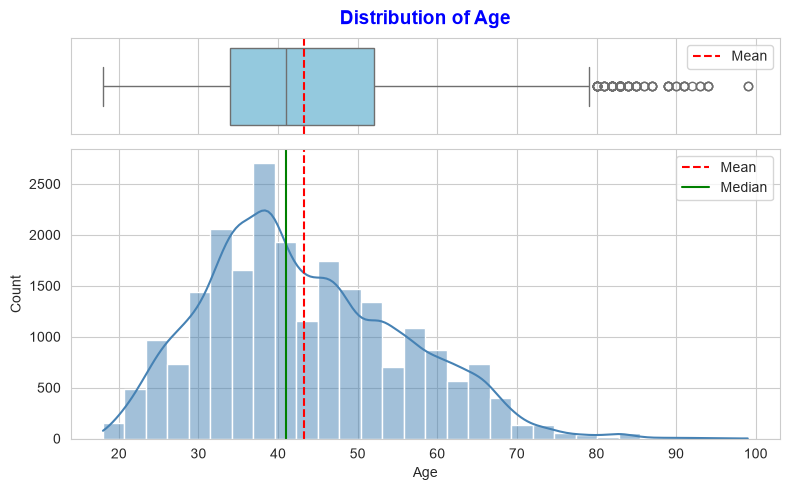

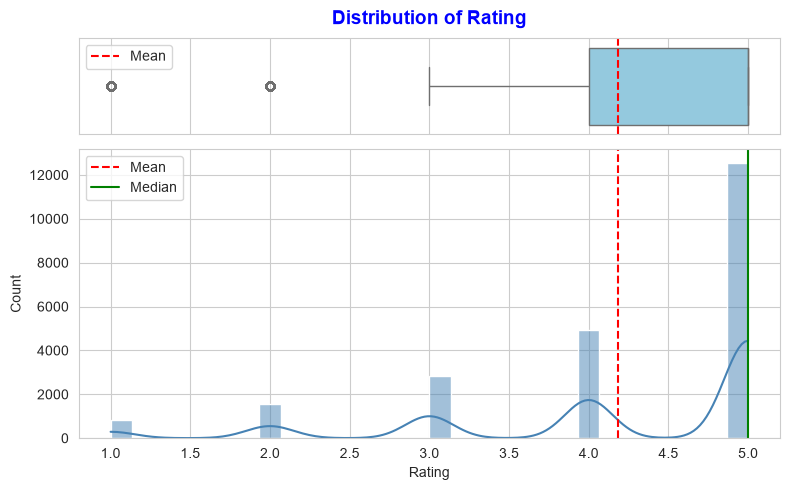

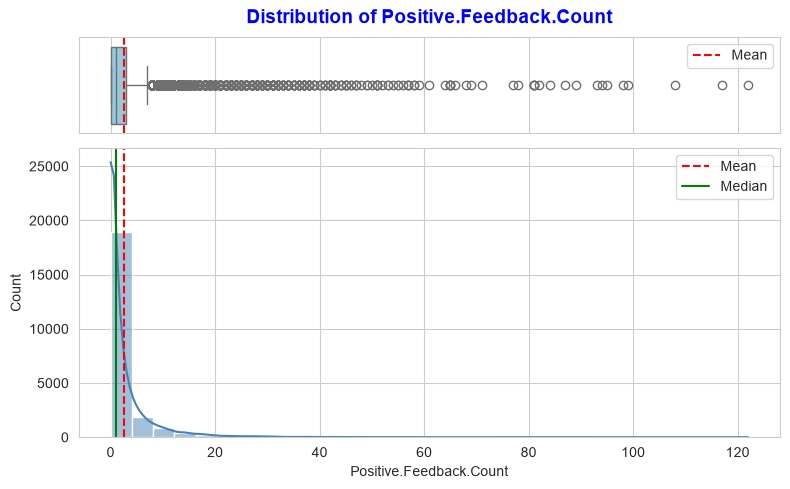

Observations:
   - Age: mean = 43.28, median = 41, range = 18 to 99. The distribution is fairly symmetric with most reviewers between 30 and 50.
   - Rating: mean = 4.18, median = 5, std = 1.12. Ratings cluster at 4 and 5, indicating predominantly positive feedback.
   - Positive.Feedback.Count: mean = 2.63, median = 1, max = 122. The variable is strongly right-skewed because most reviews receive very few helpful votes.


In [15]:
# ------------------------------------------------------------------
# Question 1: Summary statistics of numerical data
# ------------------------------------------------------------------
print("\nQuestion 1: Summary statistics of numerical data")
print("-" * 80)

# Summary table for all numeric fields.
display(df[numeric_eda_cols].describe())

# Focus on Age, Rating, and Positive.Feedback.Count with distribution plots.
for col in ["Age", "Rating", "Positive.Feedback.Count"]:
    histogram_boxplot(df, col)

print("Observations:")
print(f"   - Age: mean = {df['Age'].mean():.2f}, median = {df['Age'].median():.0f}, "
      f"range = {df['Age'].min()} to {df['Age'].max()}. The distribution is fairly symmetric with most reviewers between 30 and 50.")
print(f"   - Rating: mean = {df['Rating'].mean():.2f}, median = {df['Rating'].median():.0f}, "
      f"std = {df['Rating'].std():.2f}. Ratings cluster at 4 and 5, indicating predominantly positive feedback.")
print(f"   - Positive.Feedback.Count: mean = {df['Positive.Feedback.Count'].mean():.2f}, "
      f"median = {df['Positive.Feedback.Count'].median():.0f}, max = {df['Positive.Feedback.Count'].max()}. "
      f"The variable is strongly right-skewed because most reviews receive very few helpful votes.")


In [16]:
# ------------------------------------------------------------------
# Question 2: Unique values in categorical columns
# ------------------------------------------------------------------
print("\nQuestion 2: Unique values in categorical columns")
print("-" * 80)

unique_summary = pd.DataFrame({
    "unique_count": [df[col].nunique() for col in categorical_eda_cols],
    "top_value": [df[col].value_counts().idxmax() for col in categorical_eda_cols],
    "top_value_count": [df[col].value_counts().max() for col in categorical_eda_cols],
}, index=categorical_eda_cols)

display(unique_summary)

for col in categorical_eda_cols:
    print(f"\n{col} value counts:")
    display(df[col].value_counts(dropna=False).to_frame(name="count"))

print("Observations:")
print(f"   - Division.Name has {df['Division.Name'].nunique()} unique divisions; 'General' dominates the review volume.")
print(f"   - Department.Name has {df['Department.Name'].nunique()} unique departments; 'Tops' and 'Dresses' account for most reviews.")
print(f"   - Class.Name has {df['Class.Name'].nunique()} unique product classes, showing finer-grained product variation.")
print(f"   - A small number of rows still have missing category labels and should be handled in post-EDA cleaning.")



Question 2: Unique values in categorical columns
--------------------------------------------------------------------------------


,unique_count,top_value,top_value_count
Division.Name,3,General,13364
Department.Name,6,Tops,10048
Class.Name,20,Dresses,6145



Division.Name value counts:


,count
Division.Name,
General,13364
General Petite,7837
Initmates,1426
<NA>,13



Department.Name value counts:


,count
Department.Name,
Tops,10048
Dresses,6145
Bottoms,3661
Intimate,1653
Jackets,1002
Trend,118
<NA>,13



Class.Name value counts:


,count
Class.Name,
Dresses,6145
Knits,4626
Blouses,2983
Sweaters,1380
Pants,1350
Jeans,1103
Fine gauge,1059
Skirts,903
Jackets,683


Observations:
   - Division.Name has 3 unique divisions; 'General' dominates the review volume.
   - Department.Name has 6 unique departments; 'Tops' and 'Dresses' account for most reviews.
   - Class.Name has 20 unique product classes, showing finer-grained product variation.
   - A small number of rows still have missing category labels and should be handled in post-EDA cleaning.


In [17]:
# ------------------------------------------------------------------
# Question 3: Overall distribution of product Rating
# ------------------------------------------------------------------
print("\nQuestion 3: Overall distribution of product Rating")
print("-" * 80)

rating_counts = df["Rating"].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(2)

display(pd.DataFrame({"count": rating_counts, "percentage": rating_pct}))

# Plotly histogram for interactive exploration of rating distribution.
fig_rating = px.histogram(
    df,
    x="Rating",
    color="Rating",
    title="Distribution of Product Ratings",
    category_orders={"Rating": [1, 2, 3, 4, 5]},
)
fig_rating.update_layout(
    xaxis_title="Rating (1-5)",
    yaxis_title="Number of Reviews",
)
fig_rating.show()

positive_share = ((df["Rating"] >= 4).sum() / len(df) * 100)
negative_share = ((df["Rating"] <= 2).sum() / len(df) * 100)

print("Observations:")
print(f"   - The dataset is strongly skewed toward positive reviews: {positive_share:.1f}% are 4-5 stars.")
print(f"   - Only {negative_share:.1f}% of reviews are 1-2 stars, so negative feedback is a smaller but important segment.")
print(f"   - The median rating is {df['Rating'].median():.0f} and the mean is {df['Rating'].mean():.2f}, confirming positive sentiment dominance.")
print(f"   - This imbalance should be considered when sampling reviews for LLM evaluation.")



Question 3: Overall distribution of product Rating
--------------------------------------------------------------------------------


,count,percentage
Rating,,
1,821,3.63
2,1549,6.84
3,2823,12.47
4,4908,21.68
5,12539,55.38


Observations:
   - The dataset is strongly skewed toward positive reviews: 77.1% are 4-5 stars.
   - Only 10.5% of reviews are 1-2 stars, so negative feedback is a smaller but important segment.
   - The median rating is 5 and the mean is 4.18, confirming positive sentiment dominance.
   - This imbalance should be considered when sampling reviews for LLM evaluation.


In [18]:
# ------------------------------------------------------------------
# Question 4: Average rating by Department Name
# ------------------------------------------------------------------
print("\nQuestion 4: Average rating by Department Name")
print("-" * 80)

avg_rating_by_dept = (
    df.groupby("Department.Name")["Rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

display(avg_rating_by_dept)

highest_dept = avg_rating_by_dept.iloc[0]["Department.Name"]
lowest_dept = avg_rating_by_dept.iloc[-1]["Department.Name"]

fig_dept = px.bar(
    avg_rating_by_dept,
    x="mean",
    y="Department.Name",
    orientation="h",
    title="Average Customer Rating by Department",
    color="mean",
    text="mean",
)
fig_dept.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig_dept.update_layout(xaxis_title="Average Rating", yaxis_title="Department")
fig_dept.show()

print("Observations:")
print(f"   - Highest average rating: {highest_dept} ({avg_rating_by_dept.iloc[0]['mean']:.2f}).")
print(f"   - Lowest average rating: {lowest_dept} ({avg_rating_by_dept.iloc[-1]['mean']:.2f}).")
print(f"   - Differences between departments are modest because most ratings are 4-5 stars.")
print(f"   - Departments with lower averages may reflect fit, quality, or expectation issues rather than broad dissatisfaction.")



Question 4: Average rating by Department Name
--------------------------------------------------------------------------------


,Department.Name,mean,count
0,Bottoms,4.278612,3661
1,Intimate,4.271022,1653
2,Jackets,4.254491,1002
3,Tops,4.157743,10048
4,Dresses,4.138812,6145
5,Trend,3.838983,118


Observations:
   - Highest average rating: Bottoms (4.28).
   - Lowest average rating: Trend (3.84).
   - Differences between departments are modest because most ratings are 4-5 stars.
   - Departments with lower averages may reflect fit, quality, or expectation issues rather than broad dissatisfaction.



Question 5: Word clouds for positive vs negative reviews
--------------------------------------------------------------------------------
   - Positive review records (Rating >= 4): 17,447
   - Negative review records (Rating <= 2): 2,370


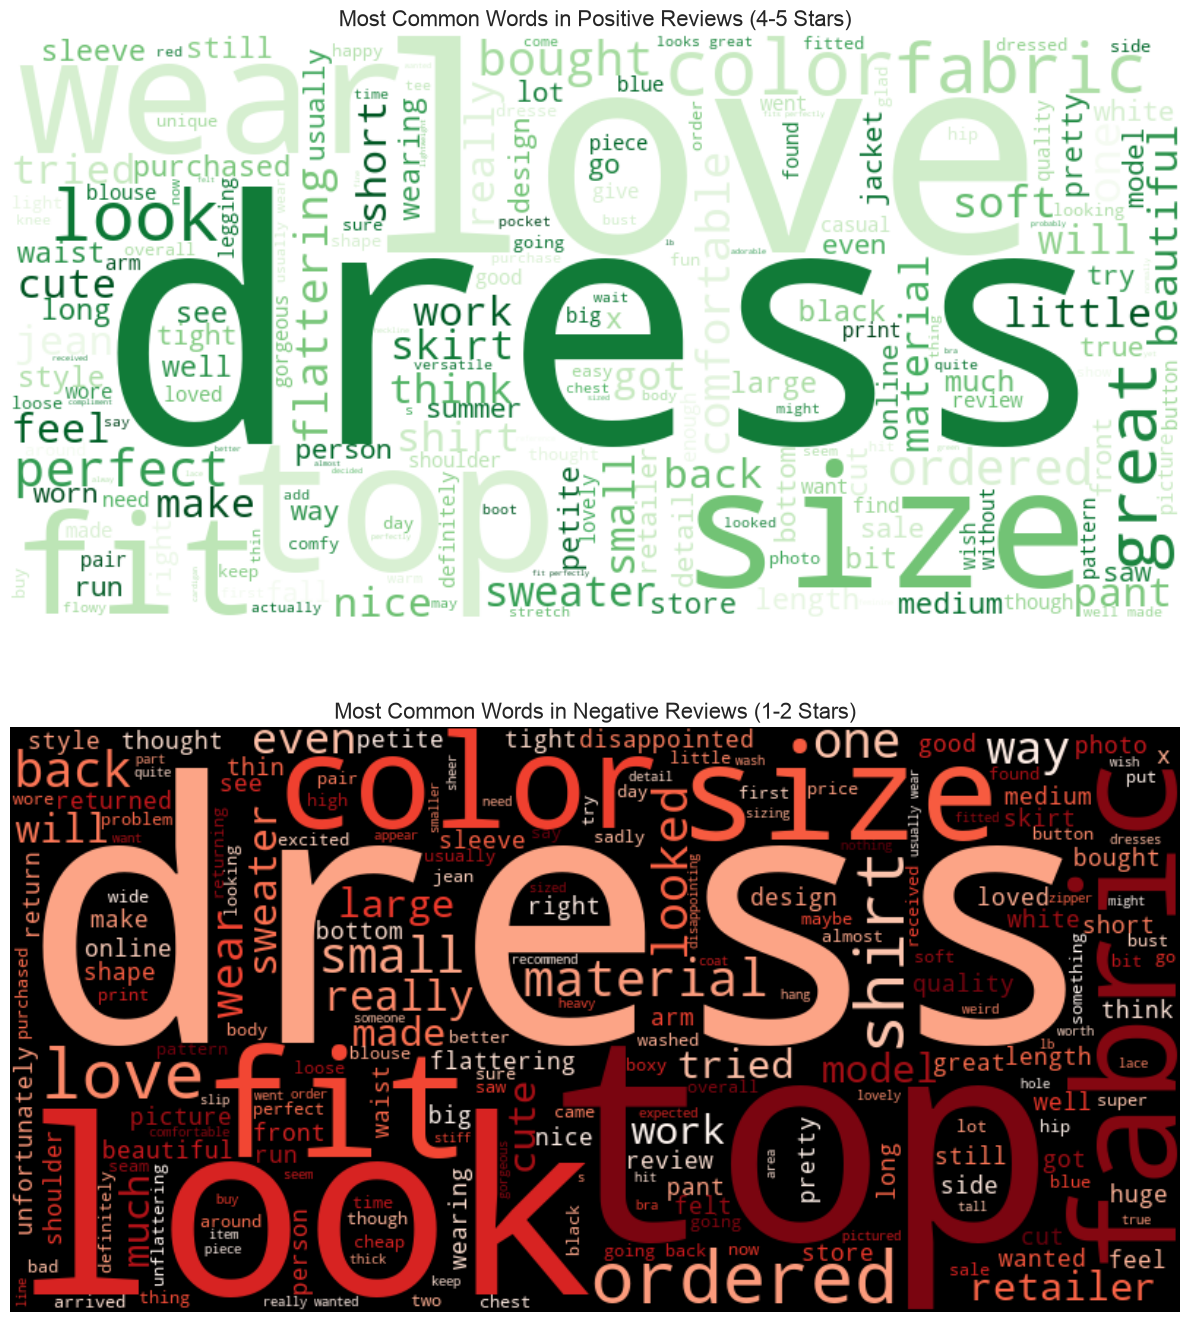

Observations:
   - Positive reviews frequently mention fit, fabric, color, comfort, and words like 'love' and 'perfect'.
   - Negative reviews emphasize sizing problems ('small', 'large', 'fit'), fabric quality, and returns/exchanges.
   - Fit and sizing appear to be the strongest shared theme across both satisfaction and dissatisfaction.
   - Initial hypothesis: improving size guidance and fit consistency could reduce negative reviews and strengthen loyalty.


In [19]:
# ------------------------------------------------------------------
# Question 5: Word clouds for high-rated vs low-rated reviews
# ------------------------------------------------------------------
print("\nQuestion 5: Word clouds for positive vs negative reviews")
print("-" * 80)

# Combine review text for each sentiment group.
positive_reviews = " ".join(df.loc[df["Rating"] >= 4, "Review.Text"].dropna().astype(str))
negative_reviews = " ".join(df.loc[df["Rating"] <= 2, "Review.Text"].dropna().astype(str))

print(f"   - Positive review records (Rating >= 4): {(df['Rating'] >= 4).sum():,}")
print(f"   - Negative review records (Rating <= 2): {(df['Rating'] <= 2).sum():,}")

# Generate word clouds to compare language patterns across sentiment groups.
wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens",
).generate(positive_reviews)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="Reds",
).generate(negative_reviews)

# Stack word clouds vertically (positive on top, negative below) with spacing between them.
fig_wc, (ax_pos, ax_neg) = plt.subplots(2, 1, figsize=(12, 14))
fig_wc.subplots_adjust(hspace=0.35)

ax_pos.imshow(wordcloud_positive, interpolation="bilinear")
ax_pos.set_title("Most Common Words in Positive Reviews (4-5 Stars)", fontsize=16)
ax_pos.axis("off")

ax_neg.imshow(wordcloud_negative, interpolation="bilinear")
ax_neg.set_title("Most Common Words in Negative Reviews (1-2 Stars)", fontsize=16)
ax_neg.axis("off")

plt.tight_layout()
plt.show()

print("Observations:")
print("   - Positive reviews frequently mention fit, fabric, color, comfort, and words like 'love' and 'perfect'.")
print("   - Negative reviews emphasize sizing problems ('small', 'large', 'fit'), fabric quality, and returns/exchanges.")
print("   - Fit and sizing appear to be the strongest shared theme across both satisfaction and dissatisfaction.")
print("   - Initial hypothesis: improving size guidance and fit consistency could reduce negative reviews and strengthen loyalty.")


In [20]:
# ----------------------------------------------------------------------
# Additional Exploratory Data Analysis
# Supplementary analyses beyond the five core EDA questions.
# ----------------------------------------------------------------------

print("\n" + "=" * 80)
print("ADDITIONAL EDA ANALYSES")
print("=" * 80)



ADDITIONAL EDA ANALYSES



Additional Analysis 1: Rating vs. Recommended.IND consistency
--------------------------------------------------------------------------------


Recommended.IND,0,1,Total
Rating,,,
1,806,15,821
2,1455,94,1549
3,1653,1170,2823
4,164,4744,4908
5,23,12516,12539
Total,4101,18539,22640


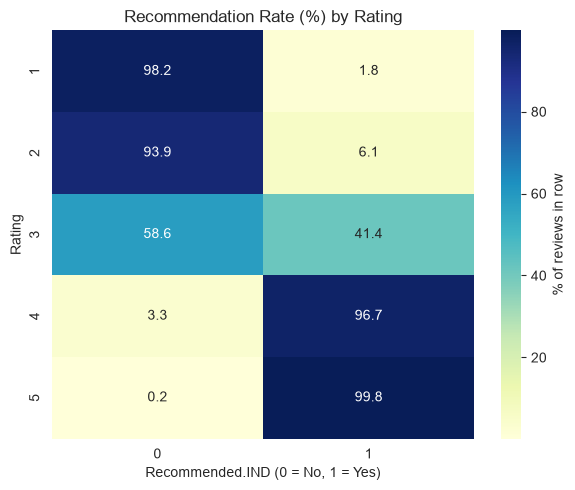

Observations:
   - Overall recommendation rate: 81.9% of reviews recommend the product.
   - At 5-star rating, 99.8% of reviewers still recommend the product (near-universal alignment).
   - 187 reviews have Rating >= 4 but Recommended.IND = 0 (qualified praise without recommendation).
   - 109 reviews have Rating <= 2 but Recommended.IND = 1 (rare conflicting signals worth manual review).
   - Rating and Recommended.IND are strongly aligned; mismatches are a small but actionable subset for the LLM pipeline.


In [21]:
# ------------------------------------------------------------------
# Additional Analysis 1: Rating vs. Recommended.IND consistency
# Compare star ratings with the binary recommendation flag to identify aligned vs. conflicting satisfaction signals.
# ------------------------------------------------------------------
print("\nAdditional Analysis 1: Rating vs. Recommended.IND consistency")
print("-" * 80)

rating_rec_crosstab = pd.crosstab(
    df["Rating"], df["Recommended.IND"], margins=True, margins_name="Total"
)
display(rating_rec_crosstab)

crosstab_pct = pd.crosstab(df["Rating"], df["Recommended.IND"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    crosstab_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "% of reviews in row"},
    ax=ax,
)
ax.set_title("Recommendation Rate (%) by Rating")
ax.set_xlabel("Recommended.IND (0 = No, 1 = Yes)")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.show()

mismatch_high = ((df["Rating"] >= 4) & (df["Recommended.IND"] == 0)).sum()
mismatch_low = ((df["Rating"] <= 2) & (df["Recommended.IND"] == 1)).sum()
pct_recommend_at_5 = crosstab_pct.loc[5, 1] if 5 in crosstab_pct.index else np.nan

print("Observations:")
print(f"   - Overall recommendation rate: {df['Recommended.IND'].mean() * 100:.1f}% of reviews recommend the product.")
print(f"   - At 5-star rating, {pct_recommend_at_5:.1f}% of reviewers still recommend the product (near-universal alignment).")
print(f"   - {mismatch_high:,} reviews have Rating >= 4 but Recommended.IND = 0 (qualified praise without recommendation).")
print(f"   - {mismatch_low:,} reviews have Rating <= 2 but Recommended.IND = 1 (rare conflicting signals worth manual review).")
print(f"   - Rating and Recommended.IND are strongly aligned; mismatches are a small but actionable subset for the LLM pipeline.")



Additional Analysis 2: Rating and recommendation by Class and Division
--------------------------------------------------------------------------------
Class.Name summary:


,Class.Name,review_count,mean_rating,recommend_rate,recommend_pct
0,Layering,132,4.348485,0.878788,87.878788
1,Jeans,1103,4.347235,0.87942,87.941976
2,Lounge,669,4.301943,0.857997,85.799701
3,Sleep,214,4.294393,0.85514,85.514019
4,Jackets,683,4.288433,0.843338,84.333821
5,Intimates,147,4.278912,0.857143,85.714286
6,Pants,1350,4.261481,0.832593,83.259259
7,Shorts,304,4.253289,0.838816,83.881579
8,Legwear,158,4.246835,0.85443,85.443038
9,Fine gauge,1059,4.23796,0.832861,83.286119


Division.Name summary:


,Division.Name,review_count,mean_rating,recommend_rate,recommend_pct
0,Initmates,1426,4.275596,0.847826,84.782609
1,General Petite,7837,4.196631,0.822509,82.250861
2,General,13364,4.16522,0.813454,81.345406


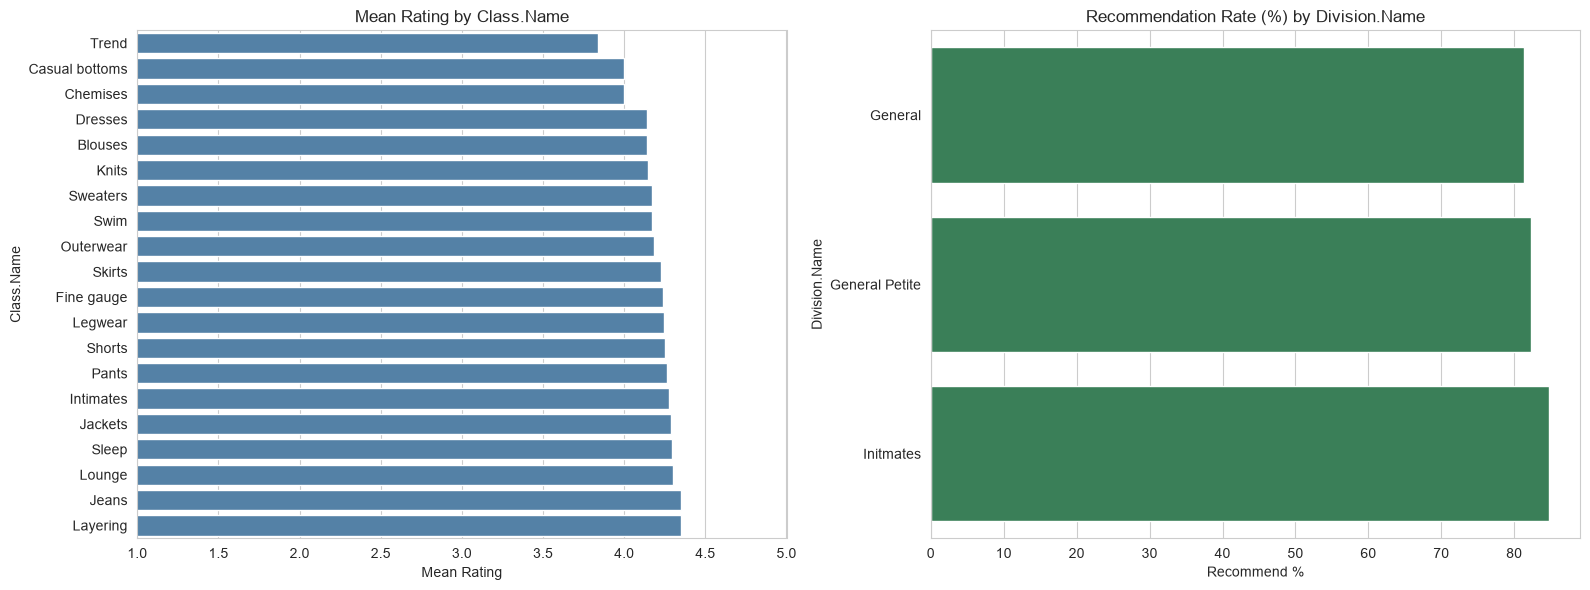

Observations:
   - Class.Name has 20 categories; Division.Name has 3 divisions.
   - Highest-rated class: Layering (mean rating = 4.35, n = 132).
   - Lowest-rated class: Trend (mean rating = 3.84, n = 118).
   - Lowest recommendation rate by division: General (81.3% recommend).
   - Class-level breakdowns reveal category-specific issues that department averages may mask.


In [22]:
# ------------------------------------------------------------------
# Additional Analysis 2: Recommendation rate and rating by Class.Name and Division.Name
# Extend department-level insights to division and class to pinpoint granular product categories with satisfaction gaps.
# ------------------------------------------------------------------
print("\nAdditional Analysis 2: Rating and recommendation by Class and Division")
print("-" * 80)

def category_satisfaction_summary(group_col):
    summary = (
        df.groupby(group_col)
        .agg(
            review_count=("Rating", "count"),
            mean_rating=("Rating", "mean"),
            recommend_rate=("Recommended.IND", "mean"),
        )
        .assign(recommend_pct=lambda x: x["recommend_rate"] * 100)
        .sort_values("mean_rating", ascending=False)
        .reset_index()
    )
    return summary

class_summary = category_satisfaction_summary("Class.Name")
division_summary = category_satisfaction_summary("Division.Name")

print("Class.Name summary:")
display(class_summary)

print("Division.Name summary:")
display(division_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=class_summary.sort_values("mean_rating", ascending=True),
    y="Class.Name",
    x="mean_rating",
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Mean Rating by Class.Name")
axes[0].set_xlabel("Mean Rating")
axes[0].set_xlim(1, 5)

sns.barplot(
    data=division_summary.sort_values("recommend_pct", ascending=True),
    y="Division.Name",
    x="recommend_pct",
    ax=axes[1],
    color="seagreen",
)
axes[1].set_title("Recommendation Rate (%) by Division.Name")
axes[1].set_xlabel("Recommend %")
plt.tight_layout()
plt.show()

lowest_class = class_summary.iloc[-1]
highest_class = class_summary.iloc[0]
lowest_div = division_summary.iloc[-1]

print("Observations:")
print(f"   - Class.Name has {class_summary['Class.Name'].nunique()} categories; Division.Name has {division_summary['Division.Name'].nunique()} divisions.")
print(f"   - Highest-rated class: {highest_class['Class.Name']} (mean rating = {highest_class['mean_rating']:.2f}, n = {int(highest_class['review_count']):,}).")
print(f"   - Lowest-rated class: {lowest_class['Class.Name']} (mean rating = {lowest_class['mean_rating']:.2f}, n = {int(lowest_class['review_count']):,}).")
print(f"   - Lowest recommendation rate by division: {lowest_div['Division.Name']} ({lowest_div['recommend_pct']:.1f}% recommend).")
print(f"   - Class-level breakdowns reveal category-specific issues that department averages may mask.")



Additional Analysis 3: Product-level risk (Clothing.ID)
--------------------------------------------------------------------------------
Products with at least 10 reviews: 228 of 1,179 total products


,Clothing.ID,review_count,mean_rating,recommend_rate
218,229,11,2.181818,0.272727
905,929,19,3.105263,0.526316
860,884,11,3.181818,0.636364
924,948,10,3.2,0.5
1030,1055,24,3.291667,0.541667
992,1016,24,3.333333,0.625
962,986,31,3.419355,0.612903
1059,1084,72,3.458333,0.708333
462,482,10,3.5,0.4
818,841,25,3.52,0.6


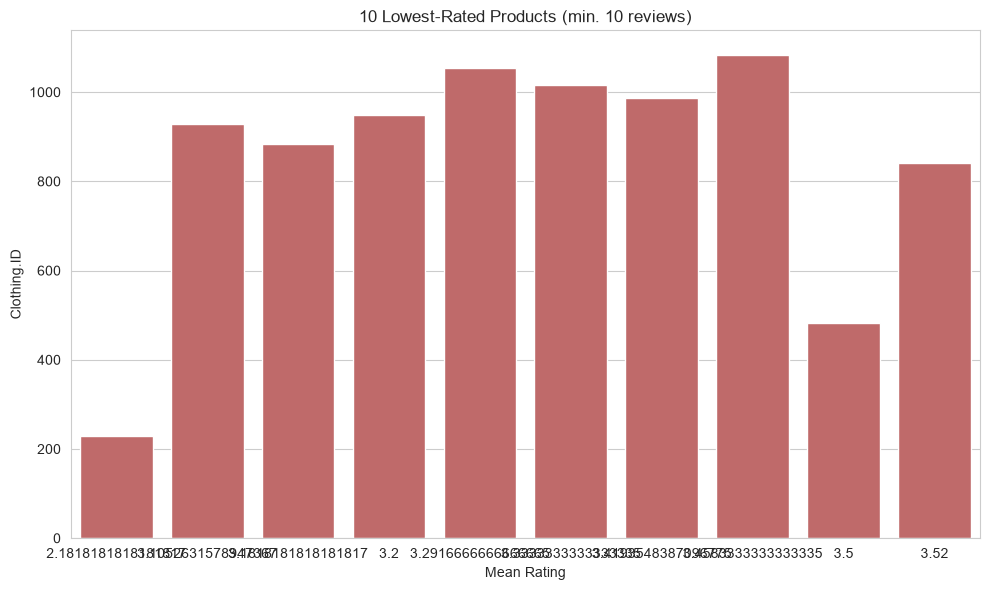

Observations:
   - 1,179 unique Clothing.ID values appear in the dataset.
   - Worst-rated product (min. 10 reviews): ID 229 (mean rating = 2.18, n = 11).
   - Best-rated product (min. 10 reviews): ID 252 (mean rating = 4.82, n = 11).
   - Product-level monitoring complements category averages and supports targeted interventions during peak seasons.


In [23]:
# ------------------------------------------------------------------
# Additional Analysis 3: Product-level risk — worst-rated items (Clothing.ID)
# Flag individual products with persistently low ratings so the retail team can investigate defects, sizing, or listing issues.
# ------------------------------------------------------------------
print("\nAdditional Analysis 3: Product-level risk (Clothing.ID)")
print("-" * 80)

MIN_REVIEWS = 10

product_stats = (
    df.groupby("Clothing.ID")
    .agg(
        review_count=("Rating", "count"),
        mean_rating=("Rating", "mean"),
        recommend_rate=("Recommended.IND", "mean"),
    )
    .reset_index()
)

reliable_products = product_stats[product_stats["review_count"] >= MIN_REVIEWS].copy()
worst_rated = reliable_products.nsmallest(10, "mean_rating")
best_rated = reliable_products.nlargest(10, "mean_rating")

print(f"Products with at least {MIN_REVIEWS} reviews: {len(reliable_products):,} of {product_stats['Clothing.ID'].nunique():,} total products")
display(worst_rated.sort_values("mean_rating"))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=worst_rated.sort_values("mean_rating", ascending=False),
    y="Clothing.ID",
    x="mean_rating",
    ax=ax,
    color="indianred",
)
ax.set_title(f"10 Lowest-Rated Products (min. {MIN_REVIEWS} reviews)")
ax.set_xlabel("Mean Rating")
ax.set_ylabel("Clothing.ID")
plt.tight_layout()
plt.show()

print("Observations:")
print(f"   - {product_stats['Clothing.ID'].nunique():,} unique Clothing.ID values appear in the dataset.")
print(f"   - Worst-rated product (min. {MIN_REVIEWS} reviews): ID {worst_rated.iloc[0]['Clothing.ID']:.0f} "
      f"(mean rating = {worst_rated.iloc[0]['mean_rating']:.2f}, n = {int(worst_rated.iloc[0]['review_count']):,}).")
print(f"   - Best-rated product (min. {MIN_REVIEWS} reviews): ID {best_rated.iloc[0]['Clothing.ID']:.0f} "
      f"(mean rating = {best_rated.iloc[0]['mean_rating']:.2f}, n = {int(best_rated.iloc[0]['review_count']):,}).")
print(f"   - Product-level monitoring complements category averages and supports targeted interventions during peak seasons.")



Additional Analysis 4: Review text length by rating
--------------------------------------------------------------------------------


,count,mean,median,max
Rating,,,,
1,821,58.6,57.0,111
2,1549,62.1,62.0,110
3,2823,64.2,64.0,115
4,4908,63.3,64.0,113
5,12539,57.9,56.0,115


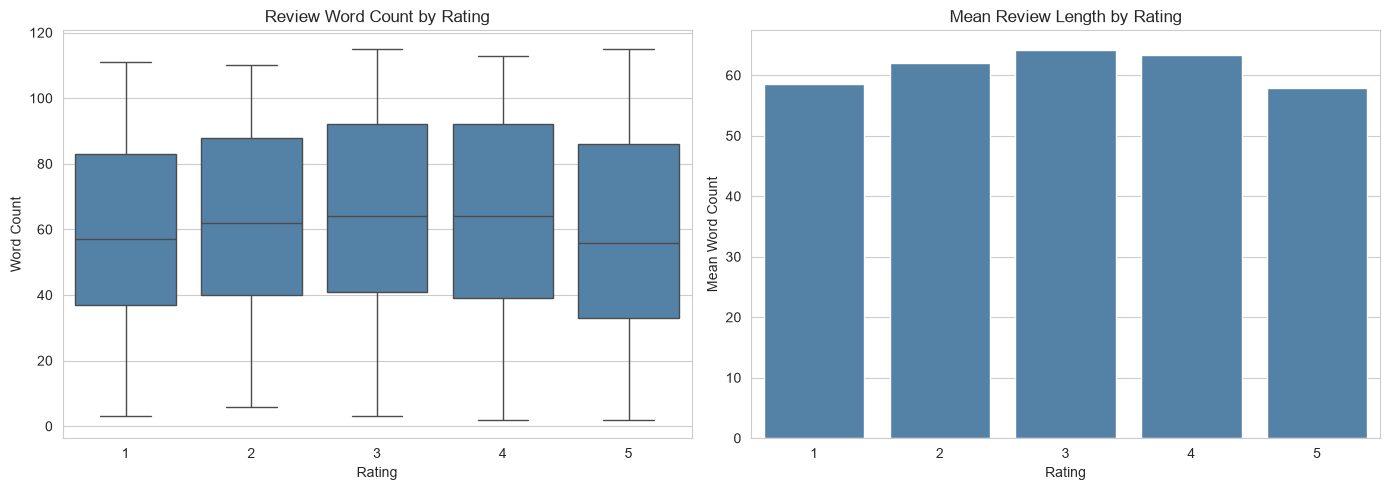

Observations:
   - Overall mean review length: 60.2 words; median = 59.
   - Longest average reviews occur at rating 3 (64.2 words on average).
   - Shortest average reviews occur at rating 5 (57.9 words on average).
   - Review length varies modestly across ratings; the LLM pipeline should handle both brief and detailed feedback.


In [24]:
# ------------------------------------------------------------------
# Additional Analysis 4: Review text length by rating
# Understand how much text customers write at each rating level, which informs GenAI input length and urgency triage rules.
# ------------------------------------------------------------------
print("\nAdditional Analysis 4: Review text length by rating")
print("-" * 80)

df_eda = df.copy()
df_eda["review_word_count"] = df_eda["Review.Text"].astype(str).str.split().str.len()

length_summary = (
    df_eda.groupby("Rating")["review_word_count"]
    .agg(["count", "mean", "median", "max"])
    .round(1)
)
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_eda, x="Rating", y="review_word_count", ax=axes[0], color="steelblue")
axes[0].set_title("Review Word Count by Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Word Count")

sns.barplot(
    data=length_summary.reset_index(),
    x="Rating",
    y="mean",
    ax=axes[1],
    color="steelblue",
)
axes[1].set_title("Mean Review Length by Rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Mean Word Count")
plt.tight_layout()
plt.show()

longest_rating = length_summary["mean"].idxmax()
shortest_rating = length_summary["mean"].idxmin()

print("Observations:")
print(f"   - Overall mean review length: {df_eda['review_word_count'].mean():.1f} words; median = {df_eda['review_word_count'].median():.0f}.")
print(f"   - Longest average reviews occur at rating {longest_rating} ({length_summary.loc[longest_rating, 'mean']:.1f} words on average).")
print(f"   - Shortest average reviews occur at rating {shortest_rating} ({length_summary.loc[shortest_rating, 'mean']:.1f} words on average).")
print(f"   - Review length varies modestly across ratings; the LLM pipeline should handle both brief and detailed feedback.")



Additional Analysis 5: Numeric correlation heatmap
--------------------------------------------------------------------------------


,Age,Rating,Positive.Feedback.Count,Recommended.IND
Age,1.000,0.030,0.041,0.034
Rating,0.030,1.000,-0.061,0.793
Positive.Feedback.Count,0.041,-0.061,1.000,-0.066
Recommended.IND,0.034,0.793,-0.066,1.000


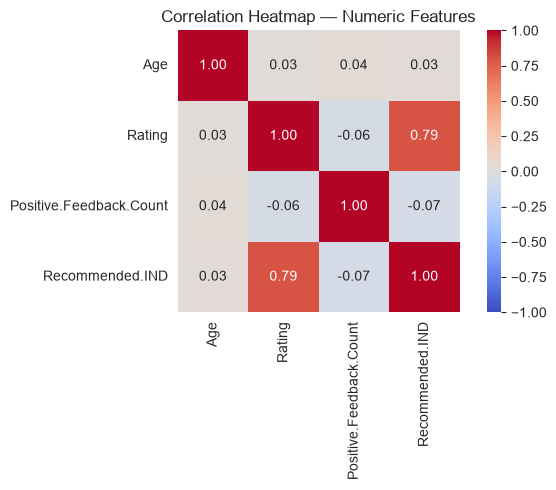

Observations:
   - Strongest correlation with Rating: Recommended.IND (r = 0.79).
   - Rating vs. Positive.Feedback.Count: r = -0.06 (slightly more helpful votes on lower-rated reviews).
   - Age vs. Rating: r = 0.03 (demographics have limited linear association with scores).
   - No numeric pair shows problematic multicollinearity for downstream analysis.


In [25]:
# ------------------------------------------------------------------
# Additional Analysis 5: Numeric correlation heatmap
# Examine linear relationships among numeric fields to guide feature understanding before modeling or GenAI evaluation.
# ------------------------------------------------------------------
print("\nAdditional Analysis 5: Numeric correlation heatmap")
print("-" * 80)

corr_matrix = df[numeric_eda_cols].corr().round(3)
display(corr_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

rating_rec_corr = corr_matrix.loc["Rating", "Recommended.IND"]
rating_feedback_corr = corr_matrix.loc["Rating", "Positive.Feedback.Count"]
age_rating_corr = corr_matrix.loc["Age", "Rating"]

print("Observations:")
print(f"   - Strongest correlation with Rating: Recommended.IND (r = {rating_rec_corr:.2f}).")
print(f"   - Rating vs. Positive.Feedback.Count: r = {rating_feedback_corr:.2f} (slightly more helpful votes on lower-rated reviews).")
print(f"   - Age vs. Rating: r = {age_rating_corr:.2f} (demographics have limited linear association with scores).")
print(f"   - No numeric pair shows problematic multicollinearity for downstream analysis.")



Additional Analysis 6: Positive.Feedback.Count vs. rating
--------------------------------------------------------------------------------


,count,mean,median,max
Rating,,,,
1,821,3.55,1.0,108
2,1549,3.36,1.0,65
3,2823,3.2,1.0,122
4,4908,2.49,1.0,95
5,12539,2.41,1.0,117


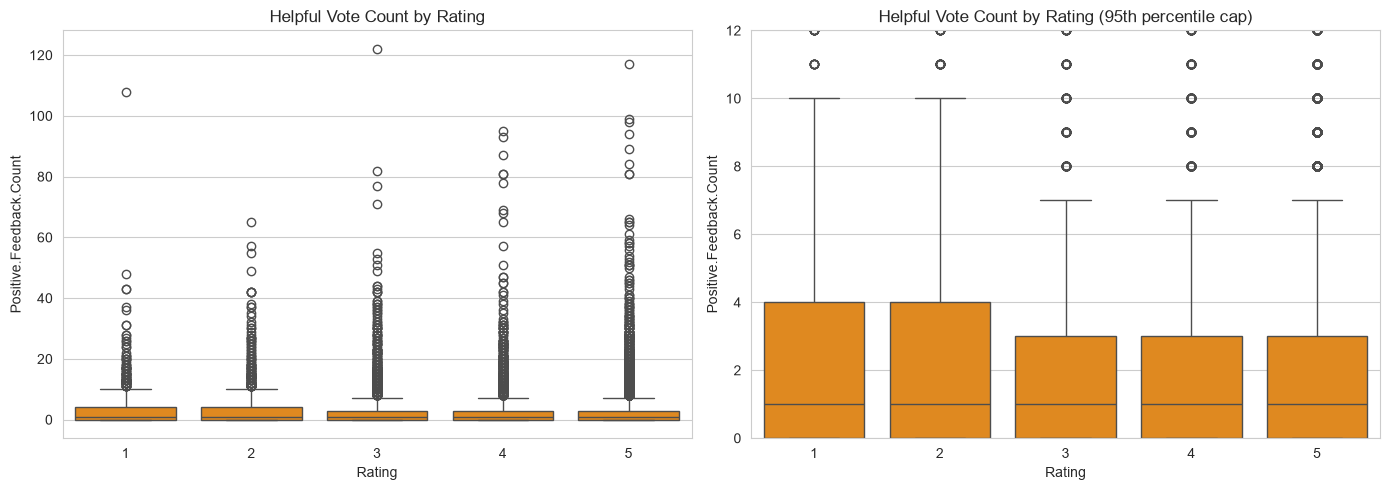

Observations:
   - 45.6% of reviews have zero helpful votes (right-skewed engagement).
   - Highest mean helpful votes by rating: 1 stars (mean = 3.55).
   - Maximum helpful votes on a single review: 122 (outlier engagement).
   - Helpful votes are weakly tied to rating; highly-voted negative reviews may signal widespread product issues.


In [26]:
# ------------------------------------------------------------------
# Additional Analysis 6: Positive.Feedback.Count vs. rating
# See whether low-rated reviews attract more 'helpful' votes, indicating issues many customers agree with.
# ------------------------------------------------------------------
print("\nAdditional Analysis 6: Positive.Feedback.Count vs. rating")
print("-" * 80)

feedback_by_rating = (
    df.groupby("Rating")["Positive.Feedback.Count"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)
display(feedback_by_rating)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Rating", y="Positive.Feedback.Count", ax=axes[0], color="darkorange")
axes[0].set_title("Helpful Vote Count by Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Positive.Feedback.Count")

cap = df["Positive.Feedback.Count"].quantile(0.95)
sns.boxplot(data=df, x="Rating", y="Positive.Feedback.Count", ax=axes[1], color="darkorange")
axes[1].set_ylim(0, cap)
axes[1].set_title("Helpful Vote Count by Rating (95th percentile cap)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Positive.Feedback.Count")
plt.tight_layout()
plt.show()

top_feedback_rating = feedback_by_rating["mean"].idxmax()
zero_feedback_pct = (df["Positive.Feedback.Count"] == 0).mean() * 100

print("Observations:")
print(f"   - {zero_feedback_pct:.1f}% of reviews have zero helpful votes (right-skewed engagement).")
print(f"   - Highest mean helpful votes by rating: {top_feedback_rating} stars "
      f"(mean = {feedback_by_rating.loc[top_feedback_rating, 'mean']:.2f}).")
print(f"   - Maximum helpful votes on a single review: {df['Positive.Feedback.Count'].max()} (outlier engagement).")
print(f"   - Helpful votes are weakly tied to rating; highly-voted negative reviews may signal widespread product issues.")



Additional Analysis 7: Age segments vs. satisfaction
--------------------------------------------------------------------------------


,age_segment,review_count,mean_rating,recommend_rate,recommend_pct
0,18-30,3221,4.180689,0.809686,80.968643
1,31-45,10551,4.157047,0.809876,80.987584
2,46-60,6484,4.190469,0.825879,82.587909
3,61+,2384,4.285654,0.85193,85.192953


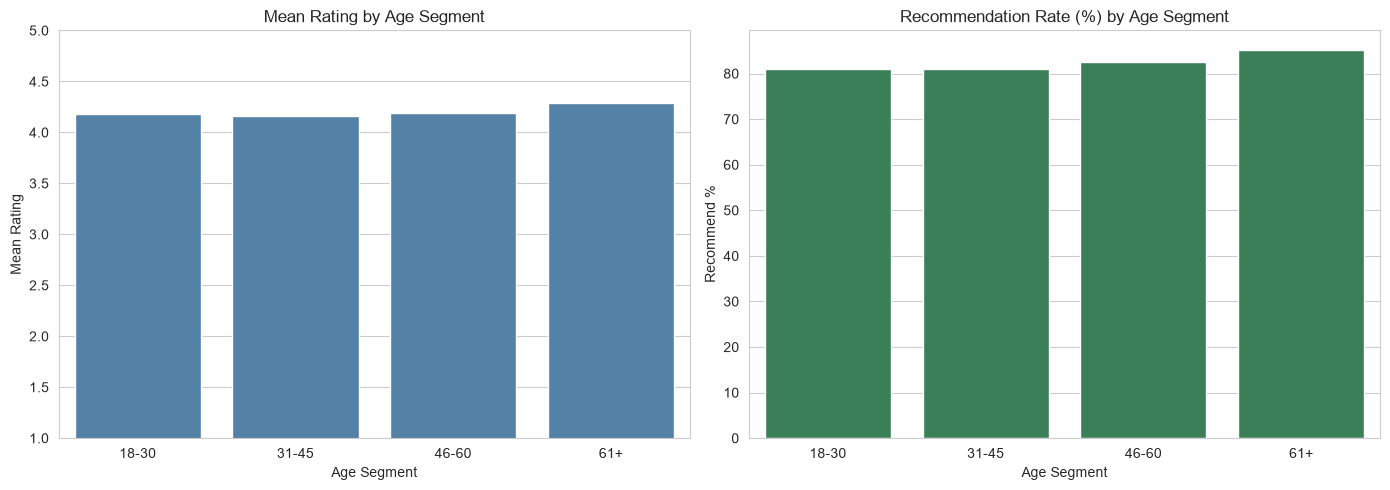

Observations:
   - Largest age segment by volume: 31-45 (10,551 reviews).
   - Highest mean rating: 61+ (mean = 4.29).
   - Lowest mean rating: 31-45 (mean = 4.16).
   - Age segments show modest differences in satisfaction; product and fit issues dominate over demographics.


In [27]:
# ------------------------------------------------------------------
# Additional Analysis 7: Age segments vs. satisfaction
# Compare satisfaction across reviewer age groups for targeted messaging, sizing guidance, and service recovery strategies.
# ------------------------------------------------------------------
print("\nAdditional Analysis 7: Age segments vs. satisfaction")
print("-" * 80)

df_age = df.copy()
df_age["age_segment"] = pd.cut(
    df_age["Age"],
    bins=[17, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "61+"],
)

age_summary = (
    df_age.groupby("age_segment", observed=True)
    .agg(
        review_count=("Rating", "count"),
        mean_rating=("Rating", "mean"),
        recommend_rate=("Recommended.IND", "mean"),
    )
    .assign(recommend_pct=lambda x: x["recommend_rate"] * 100)
    .reset_index()
)
display(age_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=age_summary, x="age_segment", y="mean_rating", ax=axes[0], color="steelblue")
axes[0].set_title("Mean Rating by Age Segment")
axes[0].set_xlabel("Age Segment")
axes[0].set_ylabel("Mean Rating")
axes[0].set_ylim(1, 5)

sns.barplot(data=age_summary, x="age_segment", y="recommend_pct", ax=axes[1], color="seagreen")
axes[1].set_title("Recommendation Rate (%) by Age Segment")
axes[1].set_xlabel("Age Segment")
axes[1].set_ylabel("Recommend %")
plt.tight_layout()
plt.show()

highest_age = age_summary.loc[age_summary["mean_rating"].idxmax()]
lowest_age = age_summary.loc[age_summary["mean_rating"].idxmin()]

print("Observations:")
print(f"   - Largest age segment by volume: {age_summary.loc[age_summary['review_count'].idxmax(), 'age_segment']} "
      f"({int(age_summary['review_count'].max()):,} reviews).")
print(f"   - Highest mean rating: {highest_age['age_segment']} (mean = {highest_age['mean_rating']:.2f}).")
print(f"   - Lowest mean rating: {lowest_age['age_segment']} (mean = {lowest_age['mean_rating']:.2f}).")
print(f"   - Age segments show modest differences in satisfaction; product and fit issues dominate over demographics.")



Additional Analysis 8: Review volume concentration
--------------------------------------------------------------------------------


,Clothing.ID,review_count,cumulative_pct
0,1078,987,4.359541
1,862,778,7.795936
2,1094,735,11.042403
3,1081,561,13.520318
4,872,519,15.812721
5,829,512,18.074205
6,1110,471,20.154594
7,868,414,21.983216
8,895,384,23.679329
9,936,348,25.216431


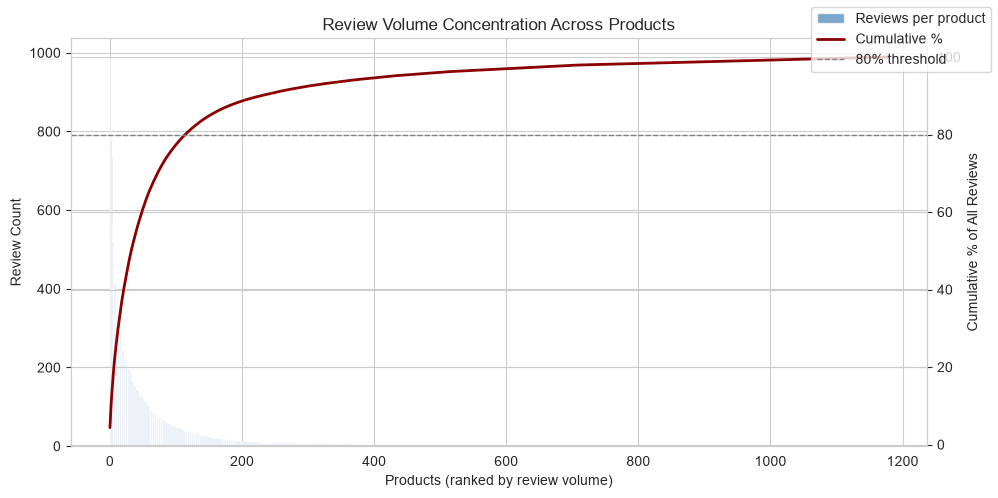

Observations:
   - 1,179 products received at least one review.
   - Top 10 products account for 25.2% of all reviews.
   - Approximately 115 products (~9.8% of catalog) drive 80% of review volume.
   - Monitoring high-volume SKUs during peak seasons yields disproportionate impact on customer perception.


In [28]:
# ------------------------------------------------------------------
# Additional Analysis 8: Review volume concentration (Pareto view)
# Check whether feedback is concentrated on a few products, which matters for prioritization during high-volume sales periods.
# ------------------------------------------------------------------
print("\nAdditional Analysis 8: Review volume concentration")
print("-" * 80)

volume_by_product = (
    df.groupby("Clothing.ID")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="review_count")
)
volume_by_product["cumulative_pct"] = (
    volume_by_product["review_count"].cumsum() / volume_by_product["review_count"].sum() * 100
)

top_n = 10
top_share = volume_by_product.head(top_n)["review_count"].sum() / volume_by_product["review_count"].sum() * 100
products_for_80pct = (volume_by_product["cumulative_pct"] <= 80).sum() + 1

display(volume_by_product.head(15))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = range(len(volume_by_product))
ax1.bar(x, volume_by_product["review_count"], color="steelblue", alpha=0.7, label="Reviews per product")
ax2.plot(x, volume_by_product["cumulative_pct"], color="darkred", linewidth=2, label="Cumulative %")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1, label="80% threshold")

ax1.set_xlabel("Products (ranked by review volume)")
ax1.set_ylabel("Review Count")
ax2.set_ylabel("Cumulative % of All Reviews")
ax1.set_title("Review Volume Concentration Across Products")
fig.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("Observations:")
print(f"   - {volume_by_product['Clothing.ID'].nunique():,} products received at least one review.")
print(f"   - Top {top_n} products account for {top_share:.1f}% of all reviews.")
print(f"   - Approximately {products_for_80pct} products (~{products_for_80pct / volume_by_product['Clothing.ID'].nunique() * 100:.1f}% of catalog) drive 80% of review volume.")
print(f"   - Monitoring high-volume SKUs during peak seasons yields disproportionate impact on customer perception.")


In [29]:
# ------------------------------------------------------------------
# Additional Analysis 9: Bigram and trigram comparison (beyond word clouds)
# Purpose: Surface multi-word phrases (e.g., sizing complaints) that
#          single-word clouds miss, guiding root-cause and prompt design.
# ------------------------------------------------------------------
print("\nAdditional Analysis 9: Bigram and trigram comparison")
print("-" * 80)

from sklearn.feature_extraction.text import CountVectorizer

positive_text = df.loc[df["Rating"] >= 4, "Review.Text"].dropna().astype(str)
negative_text = df.loc[df["Rating"] <= 2, "Review.Text"].dropna().astype(str)


def top_ngrams(corpus, ngram_range, top_n=15):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words="english", min_df=5)
    matrix = vectorizer.fit_transform(corpus)
    counts = matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    ranking = pd.Series(counts, index=terms).sort_values(ascending=False).head(top_n)
    return ranking


pos_bigrams = top_ngrams(positive_text, (2, 2))
neg_bigrams = top_ngrams(negative_text, (2, 2))
pos_trigrams = top_ngrams(positive_text, (3, 3))
neg_trigrams = top_ngrams(negative_text, (3, 3))

print("Top bigrams — positive reviews (Rating >= 4):")
display(pos_bigrams.to_frame(name="count"))

print("Top bigrams — negative reviews (Rating <= 2):")
display(neg_bigrams.to_frame(name="count"))

print("Top trigrams — positive reviews (Rating >= 4):")
display(pos_trigrams.to_frame(name="count"))

print("Top trigrams — negative reviews (Rating <= 2):")
display(neg_trigrams.to_frame(name="count"))

print("Observations:")
print(f"   - Top positive bigram: '{pos_bigrams.index[0]}' ({int(pos_bigrams.iloc[0]):,} occurrences).")
print(f"   - Top negative bigram: '{neg_bigrams.index[0]}' ({int(neg_bigrams.iloc[0]):,} occurrences).")
print(f"   - Positive trigrams often reflect fit satisfaction (e.g., '{pos_trigrams.index[0]}').")
print(f"   - Negative trigrams highlight sizing and quality phrases (e.g., '{neg_trigrams.index[0]}').")
print(f"   - Phrase-level analysis confirms fit/sizing as the dominant theme for both satisfaction and dissatisfaction.")

print("\n" + "=" * 80)
print("EDA COMPLETE")
print("=" * 80)



Additional Analysis 9: Bigram and trigram comparison
--------------------------------------------------------------------------------
Top bigrams — positive reviews (Rating >= 4):


,count
true size,1203
love dress,649
looks great,571
usually wear,551
fit perfectly,538
fits perfectly,477
size small,427
just right,400
usual size,393
highly recommend,362


Top bigrams — negative reviews (Rating <= 2):


,count
looked like,135
looks like,127
wanted love,125
look like,84
really wanted,81
felt like,68
usually wear,66
size small,55
didn work,55
true size,51


Top trigrams — positive reviews (Rating >= 4):


,count
fits true size,265
fit true size,193
runs true size,138
love love love,135
usually wear size,111
does run large,87
ordered usual size,79
small fit perfectly,72
looks great jeans,69
fits like glove,65


Top trigrams — negative reviews (Rating <= 2):


,count
really wanted love,40
really wanted like,28
wanted love dress,24
fit true size,18
ordered usual size,16
just didn work,16
usually wear size,16
looked like wearing,14
felt like wearing,12
looked like maternity,11


Observations:
   - Top positive bigram: 'true size' (1,203 occurrences).
   - Top negative bigram: 'looked like' (135 occurrences).
   - Positive trigrams often reflect fit satisfaction (e.g., 'fits true size').
   - Negative trigrams highlight sizing and quality phrases (e.g., 'really wanted love').
   - Phrase-level analysis confirms fit/sizing as the dominant theme for both satisfaction and dissatisfaction.

EDA COMPLETE


### **Deep Cleaning & Preprocessing (After EDA)**

In [30]:
# ----------------------------------------------------------------------
# Data Cleaning and Preprocessing - Deep Cleaning & Preprocessing (After EDA)
# Goal: prepare a modeling-ready dataset while preserving Review.Text for GenAI.
# Items Identified in EDA:
# - Title is missing in ~13% of rows but Review.Text is complete -> impute Title.
# - 13 rows missing category labels -> impute as "Unknown" (too few to drop).
# - Positive.Feedback.Count is right-skewed (max 122, median 1) -> cap extreme values.
# - Categorical hierarchy (Division / Department / Class) -> one-hot encode.
# - Age and helpful-vote counts -> standard-scale for downstream ML features.
# ----------------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

rows_before_deep = df.shape[0]

print("=" * 80)
print("DEEP CLEANING & PREPROCESSING (AFTER EDA)")
print("=" * 80)
print(f"Starting shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Work on a copy so pre-deep-cleaning data can still be referenced if needed.
df_deep = df.copy()


DEEP CLEANING & PREPROCESSING (AFTER EDA)
Starting shape: 22,640 rows x 10 columns


In [31]:
# ------------------------------------------------------------------
# 1. Missing value analysis and treatment
# ------------------------------------------------------------------
print("\n1. Missing Value Treatment")
print("-" * 80)

missing_before = df_deep.isna().sum()
missing_before = missing_before[missing_before > 0]
print("Missing values before deep cleaning:")
display(missing_before.to_frame(name="missing_count"))

# Title: optional metadata; Review.Text is present for all rows -> impute placeholder.
title_missing = df_deep["Title"].isna().sum()
df_deep["Title"] = df_deep["Title"].fillna("No Title")
print(f"   - Title: imputed {title_missing:,} missing values with 'No Title' (Review.Text retained for analysis).")

# Category hierarchy: only 13 rows affected -> impute rather than drop usable reviews.
category_cols = ["Division.Name", "Department.Name", "Class.Name"]
for col in category_cols:
    cat_missing = df_deep[col].isna().sum()
    df_deep[col] = df_deep[col].fillna("Unknown")
    print(f"   - {col}: imputed {cat_missing:,} missing values with 'Unknown'.")

missing_after = df_deep.isna().sum().sum()
print(f"   - Total missing values after imputation: {missing_after:,}")



1. Missing Value Treatment
--------------------------------------------------------------------------------
Missing values before deep cleaning:


,missing_count
Title,2965
Division.Name,13
Department.Name,13
Class.Name,13


   - Title: imputed 2,965 missing values with 'No Title' (Review.Text retained for analysis).
   - Division.Name: imputed 13 missing values with 'Unknown'.
   - Department.Name: imputed 13 missing values with 'Unknown'.
   - Class.Name: imputed 13 missing values with 'Unknown'.
   - Total missing values after imputation: 0


In [32]:
# ------------------------------------------------------------------
# 2. Treat complex outliers and erroneous noise
# ------------------------------------------------------------------
print("\n2. Outlier and Noise Treatment")
print("-" * 80)

# Helpful-vote counts are heavily right-skewed; extreme values can distort scaling/ML.
feedback_cap = df_deep["Positive.Feedback.Count"].quantile(0.99)
feedback_outliers = (df_deep["Positive.Feedback.Count"] > feedback_cap).sum()
df_deep["Positive.Feedback.Count_raw"] = df_deep["Positive.Feedback.Count"]
df_deep["Positive.Feedback.Count"] = df_deep["Positive.Feedback.Count"].clip(upper=feedback_cap)
print(f"   - Positive.Feedback.Count: capped {feedback_outliers:,} values above 99th percentile ({feedback_cap:.0f}).")
print(f"   - Original values preserved in Positive.Feedback.Count_raw.")

# Normalize review text noise (extra whitespace) without altering semantic content.
df_deep["Review.Text"] = (
    df_deep["Review.Text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df_deep["review_word_count"] = df_deep["Review.Text"].str.split().str.len()

# Flag rating/recommendation mismatches identified in EDA for downstream triage.
df_deep["rating_recommend_mismatch"] = (
    ((df_deep["Rating"] >= 4) & (df_deep["Recommended.IND"] == 0))
    | ((df_deep["Rating"] <= 2) & (df_deep["Recommended.IND"] == 1))
).astype(int)
mismatch_count = df_deep["rating_recommend_mismatch"].sum()
print(f"   - Review.Text: collapsed repeated whitespace; added review_word_count feature.")
print(f"   - rating_recommend_mismatch flag added for {mismatch_count:,} conflicting rows (kept for GenAI review).")



2. Outlier and Noise Treatment
--------------------------------------------------------------------------------
   - Positive.Feedback.Count: capped 211 values above 99th percentile (27).
   - Original values preserved in Positive.Feedback.Count_raw.
   - Review.Text: collapsed repeated whitespace; added review_word_count feature.
   - rating_recommend_mismatch flag added for 296 conflicting rows (kept for GenAI review).


In [33]:
# ------------------------------------------------------------------
# 3. Encode categorical variables into numbers
# ------------------------------------------------------------------
print("\n3. Categorical Encoding")
print("-" * 80)

# Binary flag: whether the customer provided a real title.
df_deep["has_title"] = (df_deep["Title"] != "No Title").astype(int)
print(f"   - has_title: binary indicator for non-imputed titles.")

# One-hot encode product hierarchy columns for downstream ML features.
category_cols = ["Division.Name", "Department.Name", "Class.Name"]
encoded_cats = pd.get_dummies(
    df_deep[category_cols],
    prefix=["Division", "Department", "Class"],
    dtype=int,
)
df_deep = pd.concat([df_deep, encoded_cats], axis=1)
print(f"   - One-hot encoded {', '.join(category_cols)} -> {encoded_cats.shape[1]} columns.")


3. Categorical Encoding
--------------------------------------------------------------------------------
   - has_title: binary indicator for non-imputed titles.
   - One-hot encoded Division.Name, Department.Name, Class.Name -> 32 columns.


In [34]:
# ------------------------------------------------------------------
# 4. Scale and normalize numerical features
# ------------------------------------------------------------------
# This step applies standardization (z-score scaling) to three numeric features so they sit on a comparable scale for ML-style workflows. 
# After scaling, each feature has roughly mean ≈ 0 and standard deviation ≈ 1.
# Without scaling, a model that uses distance or weights features by magnitude would treat them unequally. 
# For example, a difference of 50 in age would look much larger than a difference of 50 words, even though both might be meaningful in context.
# Standardization puts them on a common footing: “how many standard deviations above/below average is this value?” 

print("\n4. Feature Scaling and Normalization")
print("-" * 80)

# Columns to scale for ML-style workflows (Rating/Recommended.IND kept on original scale).
scale_cols = ["Age", "Positive.Feedback.Count", "review_word_count"]
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_deep[scale_cols])
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[f"{col}_scaled" for col in scale_cols],
    index=df_deep.index,
)
df_deep = pd.concat([df_deep, scaled_df], axis=1)

print(f"   - StandardScaler applied to: {', '.join(scale_cols)}")
print(f"   - Scaled feature means (should be ~0): {scaled_df.mean().round(3).to_dict()}")
print(f"   - Scaled feature std devs (should be ~1): {scaled_df.std().round(3).to_dict()}")

df_deep.head()


4. Feature Scaling and Normalization
--------------------------------------------------------------------------------
   - StandardScaler applied to: Age, Positive.Feedback.Count, review_word_count
   - Scaled feature means (should be ~0): {'Age_scaled': -0.0, 'Positive.Feedback.Count_scaled': -0.0, 'review_word_count_scaled': 0.0}
   - Scaled feature std devs (should be ~1): {'Age_scaled': 1.0, 'Positive.Feedback.Count_scaled': 1.0, 'review_word_count_scaled': 1.0}


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,...,Class_Shorts,Class_Skirts,Class_Sleep,Class_Sweaters,Class_Swim,Class_Trend,Class_Unknown,Age_scaled,Positive.Feedback.Count_scaled,review_word_count_scaled
0,767,33,No Title,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,...,0,0,0,0,0,0,0,-0.834001,-0.541899,-1.829285
1,1080,34,No Title,Love this dress! it's sooo pretty. i happened ...,5,1,4,General,Dresses,Dresses,...,0,0,0,0,0,0,0,-0.752878,0.329945,0.063170
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,...,0,0,0,0,0,0,0,1.356329,-0.541899,1.324807
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,...,0,0,0,0,0,0,0,0.545096,-0.541899,-1.338649
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,...,0,0,0,0,0,0,0,0.301726,0.765867,-0.848012


In [35]:
# ------------------------------------------------------------------
# 5. Deep cleaning summary
# ------------------------------------------------------------------
print("\n5. Deep Cleaning Summary")
print("-" * 80)

df = df_deep.reset_index(drop=True)

print(f"   - Rows before deep cleaning: {rows_before_deep:,}")
print(f"   - Rows after deep cleaning:  {df.shape[0]:,} (no row drops; imputation + feature engineering)")
print(f"   - Columns before: 10 | Columns after: {df.shape[1]}")
print(f"   - Review.Text preserved for Generative AI pipeline.")
print(f"   - New engineered columns: review_word_count, has_title, rating_recommend_mismatch,")
print(f"     Positive.Feedback.Count_raw, {encoded_cats.shape[1]} one-hot columns, {len(scale_cols)} scaled columns.")

print("\nSample of processed data (key columns):")
display(
    df[
        [
            "Age",
            "Rating",
            "Recommended.IND",
            "Positive.Feedback.Count",
            "review_word_count",
            "has_title",
            "rating_recommend_mismatch",
            "Age_scaled",
            "Positive.Feedback.Count_scaled",
        ]
    ].head()
)

print("\nObservations:")
print(f"   - Missing Title values were imputed (not dropped) because Review.Text — the primary GenAI input — is complete.")
print(f"   - Rare missing category labels were imputed as 'Unknown' to retain review volume while keeping hierarchy usable.")
print(f"   - Extreme helpful-vote counts were winsorized at the 99th percentile to reduce skew without losing rows.")
print(f"   - Standard scaling centers Age, helpful votes, and review length for fair comparison in downstream models.")
print(f"   - Dataset is ready for the Generative AI pipeline (text columns intact) and optional ML extensions.")

print("=" * 80)



5. Deep Cleaning Summary
--------------------------------------------------------------------------------
   - Rows before deep cleaning: 22,640
   - Rows after deep cleaning:  22,640 (no row drops; imputation + feature engineering)
   - Columns before: 10 | Columns after: 49
   - Review.Text preserved for Generative AI pipeline.
   - New engineered columns: review_word_count, has_title, rating_recommend_mismatch,
     Positive.Feedback.Count_raw, 32 one-hot columns, 3 scaled columns.

Sample of processed data (key columns):


,Age,Rating,Recommended.IND,Positive.Feedback.Count,review_word_count,has_title,rating_recommend_mismatch,Age_scaled,Positive.Feedback.Count_scaled
0,33,4,1,0,8,0,0,-0.834001,-0.541899
1,34,5,1,4,62,0,0,-0.752878,0.329945
2,60,3,0,0,98,1,0,1.356329,-0.541899
3,50,5,1,0,22,1,0,0.545096,-0.541899
4,47,5,1,6,36,1,0,0.301726,0.765867



Observations:
   - Missing Title values were imputed (not dropped) because Review.Text — the primary GenAI input — is complete.
   - Rare missing category labels were imputed as 'Unknown' to retain review volume while keeping hierarchy usable.
   - Extreme helpful-vote counts were winsorized at the 99th percentile to reduce skew without losing rows.
   - Standard scaling centers Age, helpful votes, and review length for fair comparison in downstream models.
   - Dataset is ready for the Generative AI pipeline (text columns intact) and optional ML extensions.


In [36]:
df.head()

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,...,Class_Shorts,Class_Skirts,Class_Sleep,Class_Sweaters,Class_Swim,Class_Trend,Class_Unknown,Age_scaled,Positive.Feedback.Count_scaled,review_word_count_scaled
0,767,33,No Title,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,...,0,0,0,0,0,0,0,-0.834001,-0.541899,-1.829285
1,1080,34,No Title,Love this dress! it's sooo pretty. i happened ...,5,1,4,General,Dresses,Dresses,...,0,0,0,0,0,0,0,-0.752878,0.329945,0.063170
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,...,0,0,0,0,0,0,0,1.356329,-0.541899,1.324807
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,...,0,0,0,0,0,0,0,0.545096,-0.541899,-1.338649
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,...,0,0,0,0,0,0,0,0.301726,0.765867,-0.848012


## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

##### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

#### **Setup AI Client**

In [37]:
# ----------------------------------------------------------------------
# Setup AI Client 
# Load credentials from .env in the project root, then initialize the client. (Note: I am not using Colab, I am running Notebook locally in VS Code)
# ----------------------------------------------------------------------

import os
from pathlib import Path

import openai
from dotenv import load_dotenv

# Load OPENAI_API_KEY and OPENAI_BASE_URL from the project .env file.
project_root = Path.cwd()
env_file = project_root / ".env"
load_dotenv(env_file)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_BASE_URL = os.getenv("OPENAI_BASE_URL")

# Varify that the properties are set in the .env file
if not OPENAI_API_KEY:
    raise ValueError(
        "OPENAI_API_KEY is missing. Copy .env.example to .env and set your API key."
    )
if not OPENAI_BASE_URL:
    raise ValueError(
        "OPENAI_BASE_URL is missing. Add it to the .env file in the project root."
    )

# Initialize the OpenAI client with credentials from the environment.
client = openai.OpenAI(
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL,
)

# Model for cost-effective experimentation.
model_name = "gpt-4o-mini"

print("OpenAI client initialized successfully.")
print(f"   - Base URL: {OPENAI_BASE_URL}")
print(f"   - Model:    {model_name}")


OpenAI client initialized successfully.
   - Base URL: https://aibe.mygreatlearning.com/openai/v1
   - Model:    gpt-4o-mini


In [38]:
# Verify the client can reach the API.
print("\nTesting OpenAI client connection...")
try:
    test_response = client.chat.completions.create(
        model=model_name,
        temperature=0,
        max_tokens=20,
        messages=[
            {
                "role": "user",
                "content": "Reply with exactly: API connection OK",
            }
        ],
    )
    test_message = (test_response.choices[0].message.content or "").strip()
    print("   - Status: Connected")
    print(f"   - Model:  {test_response.model}")
    print(f"   - Reply:  {test_message}")
except Exception as exc:
    print("OpenAI client test failed. Check OPENAI_API_KEY, OPENAI_BASE_URL, and network access.")
    print(f"Details: {type(exc).__name__}: {exc}")
    raise


Testing OpenAI client connection...
   - Status: Connected
   - Model:  gpt-4o-mini-2024-07-18
   - Reply:  API connection OK


#### **Setup Data Sample**

In [39]:
# ----------------------------------------------------------------------
# Initial Testing Phase & Final Evaluation Phase Data Samples
# ----------------------------------------------------------------------
RANDOM_STATE = 42
INITIAL_SAMPLE_SIZE = 10   # 5–10 reviews recommended for prompt debugging
EVAL_SAMPLE_SIZE = 50     # 50 reviews for technique comparison

# Original columns (pre deep-cleaning schema).
GENAI_COLS = [
    "Clothing.ID",
    "Age",
    "Title",
    "Review.Text",
    "Rating",
    "Recommended.IND",
    "Positive.Feedback.Count",
    "Division.Name",
    "Department.Name",
    "Class.Name",
]

# Function to sample reviews with proportional representation across star ratings.
def stratified_review_sample(candidate_reviews, sample_size, random_state=42):
    """
    Draw a random sample of reviews while preserving each star-rating mix.

    Each rating group (1–5 stars) contributes roughly the same share of rows
    in the sample as it does in the candidate pool. A small top-up or trim
    step then ensures the final sample contains exactly `sample_size` rows.

    Parameters
    ----------
    candidate_reviews : pd.DataFrame
        Pool of clean reviews to sample from.
    sample_size : int
        Number of reviews to return.
    random_state : int
        Seed for reproducible sampling.

    Returns
    -------
    pd.DataFrame
        Random sample of `sample_size` reviews, shuffled row order.
    """
    total_candidates = len(candidate_reviews)
    samples_by_rating = []

    # Step 1: draw a proportional number of reviews from each rating group.
    for rating_value, reviews_with_same_rating in candidate_reviews.groupby("Rating"):
        rating_share = len(reviews_with_same_rating) / total_candidates
        reviews_to_draw = max(1, round(sample_size * rating_share))
        reviews_to_draw = min(reviews_to_draw, len(reviews_with_same_rating))

        rating_sample = reviews_with_same_rating.sample(
            n=reviews_to_draw,
            random_state=random_state,
        )
        samples_by_rating.append(rating_sample)

    stratified_sample = pd.concat(samples_by_rating)

    # Step 2: adjust to the exact target size when rounding creates a mismatch.
    if len(stratified_sample) > sample_size:
        stratified_sample = stratified_sample.sample(
            n=sample_size,
            random_state=random_state,
        )
    elif len(stratified_sample) < sample_size:
        unused_reviews = candidate_reviews.drop(stratified_sample.index)
        extra_reviews_needed = sample_size - len(stratified_sample)
        top_up_sample = unused_reviews.sample(
            n=extra_reviews_needed,
            random_state=random_state,
        )
        stratified_sample = pd.concat([stratified_sample, top_up_sample])

    # Step 3: shuffle so rating groups are not grouped together in the output.
    return stratified_sample.sample(frac=1, random_state=random_state)


In [40]:
# ------------------------------------------------------------------
# Build the cleanest candidate pool for GenAI sampling
# ------------------------------------------------------------------
# Start from the original 10 review columns only — no scaled, or other engineered features created during deep cleaning.
candidate_reviews = df[GENAI_COLS].copy()

# Filter 1: Review text must exist (required input for every LLM prompt).
has_review_text = (
    candidate_reviews["Review.Text"].notna()
    & candidate_reviews["Review.Text"].str.strip().ne("")
)

# Filter 2: Title must be present (imputed "No Title" rows were flagged in deep cleaning).
has_original_title = candidate_reviews["Title"].ne("No Title")

# Filter 3: Product hierarchy must be complete (imputed "Unknown" rows excluded).
has_known_division = candidate_reviews["Division.Name"].ne("Unknown")
has_known_department = candidate_reviews["Department.Name"].ne("Unknown")
has_known_class = candidate_reviews["Class.Name"].ne("Unknown")

quality_mask = (
    has_review_text
    & has_original_title
    & has_known_division
    & has_known_department
    & has_known_class
)
candidate_reviews = candidate_reviews[quality_mask]

# Filter 4: Keep rows where Rating and Recommended.IND tell a consistent story.
# EDA found ~300 conflicting rows (e.g., 5-star but not recommended) — exclude them
# so prompt evaluation is not skewed by contradictory labels.
if "rating_recommend_mismatch" in df.columns:
    rating_and_recommendation_aligned = df["rating_recommend_mismatch"] == 0
else:
    high_rating_without_recommendation = (df["Rating"] >= 4) & (df["Recommended.IND"] == 0)
    low_rating_with_recommendation = (df["Rating"] <= 2) & (df["Recommended.IND"] == 1)
    rating_and_recommendation_aligned = ~(
        high_rating_without_recommendation | low_rating_with_recommendation
    )

clean_pool = candidate_reviews.loc[rating_and_recommendation_aligned, GENAI_COLS]

print("=" * 80)
print("GENERATIVE AI DATA SAMPLES")
print("=" * 80)
print(f"Clean candidate pool: {len(clean_pool):,} reviews")


GENERATIVE AI DATA SAMPLES
Clean candidate pool: 19,408 reviews


In [41]:
# Final Evaluation Phase Data Sample
# Scale up to 50 reviews for the final evaluation phase, ensuring you get enough data to compare prompting techniques without draining your budget.
# Identify the cleanest data sample that can be used to validate the prompt structure and logic. 
# Use original review columns only (exclude engineered deep-cleaning features). Do not include the cells where data was added during cleaning and preprocessing.

# Final evaluation sample (50 reviews) — disjoint from initial testing sample.
df_sample_eval = stratified_review_sample(
    clean_pool, sample_size=EVAL_SAMPLE_SIZE, random_state=RANDOM_STATE
)
remaining_pool = clean_pool.drop(df_sample_eval.index)

# Convenience alias used in later prompt-engineering cells.
df_sample_eval = df_sample_eval.reset_index(drop=True)

print(f"\nFinal evaluation sample: {len(df_sample_eval)} reviews")
print("Rating distribution:")
print(df_sample_eval["Rating"].value_counts().sort_index())

print("\nSample preview (final evaluation set):")
display(df_sample_eval[["Rating", "Department.Name", "Title", "Review.Text"]].head())



Final evaluation sample: 50 reviews
Rating distribution:
Rating
1     2
2     3
3     6
4    11
5    28
Name: count, dtype: Int64

Sample preview (final evaluation set):


,Rating,Department.Name,Title,Review.Text
0,4,Tops,Beautiful!,I ordered a regular size small. would have got...
1,5,Tops,Beautiful feminine blouse,I bought this top at my local retailer in a bu...
2,5,Dresses,Something different that's super flattering,Got this dress for a party. it was a last minu...
3,5,Tops,Oh my goodness!,I love this sweater! i ordered the dark gray a...
4,4,Jackets,Light weight for fall,I really like the soft and very wearability of...


In [42]:
# Initial Testing Phase Data Sample
# Use very small samples (5–10 reviews) during the initial testing phase to validate your prompt structure and logic.
# Identify the cleanest data sample that can be used to validate the prompt structure and logic. 
# Use original review columns only (exclude engineered deep-cleaning features). Do not include the cells where data was added during cleaning and preprocessing.

# Initial testing sample (10 reviews) — cheap iteration while refining prompts.
df_sample_initial = stratified_review_sample(
    remaining_pool, sample_size=INITIAL_SAMPLE_SIZE, random_state=RANDOM_STATE
)
# Convenience alias used in later prompt-engineering cells.
df_sample_initial = df_sample_initial.reset_index(drop=True)

print(f"\nInitial testing sample: {len(df_sample_initial)} reviews")
print("Rating distribution:")
print(df_sample_initial["Rating"].value_counts().sort_index())

print("\nSample preview (Initial testing set):")
display(df_sample_initial[["Rating", "Department.Name", "Title", "Review.Text"]].head())

# print(df_sample_initial[["Rating", "Department.Name", "Class.Name"]].value_counts().head())    


Initial testing sample: 10 reviews
Rating distribution:
Rating
1    1
2    1
3    1
4    2
5    5
Name: count, dtype: Int64

Sample preview (Initial testing set):


,Rating,Department.Name,Title,Review.Text
0,5,Tops,Very cute!!,"I love this shirt, bought it at the store. i h..."
1,1,Tops,Unflattering fit,Large and the material is too bulky. i returne...
2,2,Tops,Did not like the shape,The quality of the shirt is top notch. the fab...
3,5,Bottoms,Runs large...good for ego!,This is such a cute jumper! i bought it to wea...
4,4,Bottoms,Comfy jeans,My review isn't really about the jeans! i want...


In [43]:
print("\nNote:")
print(f" - Samples use only the 10 original columns; engineered ML features were excluded.")
print(f" - Clean pool filters: non-empty Review.Text, real Title, known categories, aligned Rating/Recommend.")
print(f" - Initial ({INITIAL_SAMPLE_SIZE}) and final ({EVAL_SAMPLE_SIZE}) samples are disjoint to avoid prompt leakage.")
print(f" - Use df_sample_initial while designing prompts; switch to df_sample_eval for scoring.")
print("=" * 80)


Note:
 - Samples use only the 10 original columns; engineered ML features were excluded.
 - Clean pool filters: non-empty Review.Text, real Title, known categories, aligned Rating/Recommend.
 - Initial (10) and final (50) samples are disjoint to avoid prompt leakage.
 - Use df_sample_initial while designing prompts; switch to df_sample_eval for scoring.


#### **DATA SAMPLE FOR ANALYSIS**
One variable to change all prompt/model executions
Use the initial DF while development and the full 50 one later for final testing and verification

In [44]:
# Data sample for analysis. Can be changed at one place to update all prompt analysis.
# DATA_SAMPLE_FOR_ANALYSIS = df_sample_initial
DATA_SAMPLE_FOR_ANALYSIS = df_sample_eval

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?


**Thoughts:**

A consistent and robust evaluation framework is essential in this project because we are comparing **multiple prompting techniques** (Zero-Shot, Few-Shot, Chain-of-Thought) and **two versions of each prompt** (V1 and V2) on the same set of customer reviews. Without a standardized way to measure output quality, any observed improvement could reflect random variation, reviewer bias, or inconsistent scoring rules rather than a genuinely better prompt.

**Why a consistent evaluation framework matters**

1. **Fair comparison across techniques** — Every prompt version should be judged against the same criteria (e.g., accuracy of Category/Sentiment, clarity of Summary, usefulness of Retail Insight). Otherwise, we cannot reliably say whether V2 outperforms V1 or whether Few-Shot beats Zero-Shot.

2. **Reproducibility** — Retail feedback analysis will eventually run at scale during peak seasons. A fixed rubric and scoring process ensures that results obtained on a 50-review sample can be trusted when the pipeline is extended.

3. **Business trust** — Stakeholders and Business Leaders (merchandising, customer service, marketing) need outputs that are **accurate, actionable, and on-brand**. An evaluation framework translates those business requirements into measurable quality dimensions instead of subjective "this looks fine" checks.

4. **Cost-aware iteration** — With a limited API budget, each prompt experiment is expensive. A robust framework helps identify meaningful quality gains early (on the 10-review test sample) before spending tokens on full 50-review evaluation runs.

5. **Error detection and guardrails** — Structured evaluation surfaces failure modes such as hallucinated product issues, wrong sentiment, generic summaries, or unsafe personalized messages before outputs reach customers.

**How LLM-as-Judge supports objective scoring**

In LLM-as-Judge, a separate model call evaluates each generated output using a **fixed judge prompt** and returns a numeric score (0 to 1). This creates a scalable, repeatable alternative to manual review of thousands of responses.

A practical judge workflow for this project:

1. **Define explicit rubric dimensions** — Score outputs on criteria such as:
   - *Faithfulness*: Does the summary/insight reflect the review text without adding false claims?
   - *Completeness*: Are required fields present (Category, Sentiment, Summary, Personalized Message, Retail Insight)?
   - *Business relevance*: Is the retail insight actionable for operations or merchandising?
   - *Tone and safety*: Is the personalized message appropriate and empathetic?

2. **Use a separate judge prompt (not the generation prompt)** — The judge receives the original review and the model-generated output, then scores quality based on the rubric. Keeping generation and evaluation prompts separate reduces self-bias.

3. **Standardize scoring scale** — Ask for a decimal score between 0 and 1 (e.g., 0.0 = unusable, 0.5 = partially correct, 1.0 = excellent). Fixed anchors make scores comparable across runs and prompt versions.

4. **Control randomness** — Set a low or zero temperature for judging so the same output receives a stable score across repeated evaluations.

5. **Aggregate and compare** — Compute average judge scores per prompt version (e.g., mean `ZS_V1_Score` vs. mean `ZS_V2_Score`). The higher average indicates the stronger prompt under the same evaluation rules.

**Important limitations to acknowledge**

- LLM judges are **not perfectly objective**; they can inherit model biases or prefer verbose answers.
- Judge scores should be treated as a **consistent proxy metric**, ideally validated periodically with human review on a small subset.
- Best practice: keep the judge rubric unchanged while comparing prompts, and only revise the rubric between major experiment phases.

In summary, a robust evaluation framework ensures prompt comparisons are fair, repeatable, and aligned with business needs — and LLM-as-Judge provides a scalable way to apply that framework consistently across every generated review output.

#### **Technique 1: Zero-Shot Prompting**


**Questions:**


1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
    Write a single instruction-only prompt that tells the model to read the customer review and return five fields: **Category**, **Sentiment**, **Summary**, **Personalized Message**, and **Retail Insight**. 
    Ask for structured output (e.g., JSON keys) and keep instructions concise — no examples are provided (zero-shot). 
    The review text is passed in at runtime as the user message.

2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
    Start from V1 and add business context: name the retailer, state that outputs support merchandising and customer-service decisions, and stress **accuracy** (only use facts from the review). 
    Tighten field rules (allowed sentiment labels, what “Retail Insight” should contain) and tone guidance for the personalized message (empathetic, professional, on-brand).

3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
    Use the **same review sample** for both prompt versions so every row can be compared fairly. For each version, run the same end-to-end pipeline:
    
    1. **Iterate review by review** — Walk through the review-text column of the sample in order, with a progress bar so long runs are visible. Processing one review at a time keeps API calls manageable and preserves row order.
    
    2. **Call the model through one shared helper** — For each review, pass the review text plus the active prompt (Version 1 or Version 2) into a single reusable function. That function sends one chat completion per review (system role + user message containing the prompt and the review), uses **temperature 0** for consistent outputs, and returns the model’s raw text response.
    
    3. **Parse into five fixed fields** — Convert each raw response into a small record with the same keys every time: Category, Sentiment, Summary, Personalized Message, and Retail Insight. Try structured JSON first; if that fails, fall back to line-by-line `Field: value` parsing. If a call fails, store an error placeholder in the record so the loop continues and the row is not dropped.
    
    4. **Collect results in a list** — Append each parsed record to a list as the loop runs. After the last review, the list has one structured output per input row, in the same sequence as the sample.
    
    5. **Turn the list into a table and tag the version** — Convert the list of records into a tabular structure, then add a **distinct column prefix** to every generated field (e.g. one prefix for Version 1, another for Version 2) so both runs can live side by side without name clashes.
    
    6. **Merge back onto the original sample** — Horizontally combine the original review rows with the prefixed prediction columns so **row *i* in the sample always matches row *i* in the outputs**. Reset indices before merging to avoid misalignment.
    
    7. **Repeat for the second prompt** — Run steps 1–6 again with the other prompt and its own prefix. You end with one widened table where each review row carries Version 1 columns, Version 2 columns, and the original metadata—ready for scoring and comparison.


4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

    Use a **fixed, separate judge** — independent of the generation prompts — so Version 1 and Version 2 are scored under the **same rubric** on the **same review sample**. The judge is a second LLM call with its own system instructions, run at **temperature 0** so scoring stays stable and comparable across rows and prompt versions.

    **Scoring rubric (applied identically to every output):**
    - **Faithfulness (25%)** — Does the output reflect facts in the original review, without invented claims?
    - **Completeness (25%)** — Are all five fields present and meaningful (Category, Sentiment, Summary, Personalized Message, Retail Insight)?
    - **Business relevance (25%)** — Is the retail insight actionable for merchandising, operations, or customer service?
    - **Tone and clarity (25%)** — Is the language professional, empathetic, and concise?

    **Per-row evaluation logic:**
    1. **Reassemble the generated output** — For each review row, gather the five prefixed prediction fields back into one structured record (the same shape the generator produced).
    2. **Send review + output to the judge** — Pass the **original review text** together with the **formatted model output** so the judge can check faithfulness against the source, not just surface quality.
    3. **Request a single numeric score** — The judge prompt asks for **one decimal between 0.0 and 1.0 only** (no explanation text), keeping parsing simple and scores consistent.
    4. **Parse and validate the response** — Extract the first valid number from the judge's reply and **clamp it to the 0–1 range**. If the call fails or the response is not parseable, record a missing score for that row rather than stopping the full run; optional retries can handle transient API errors.
    5. **Attach the score to the row** — Store the result in a **dedicated score column** for that prompt version (one score per review, aligned with the same row index as the predictions).

    **Batch scoring and comparison:**
    1. **Loop through every row** of the Version 1 results with a progress indicator, judge each output, and fill the Version 1 score column.
    2. **Repeat the identical process** for Version 2 using the same judge settings and rubric, writing into a separate Version 2 score column.
    3. **Compute the mean score** for each version across all successfully scored rows.
    4. **Compare the two averages** — the higher mean indicates the stronger prompt under the same evaluation rules, because generation conditions differed but **judging conditions did not**.


**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.


In [45]:
# ----------------------------------------------------------------------
# LLM-as-Judge — Evaluation Framework
# Scores generated retail-feedback outputs on a fixed 0.0–1.0 rubric.
# ----------------------------------------------------------------------

from typing import Any, Dict, List, Optional, Union

# Default rubric applied via the system message (kept constant across prompt comparisons).
LLM_AS_JUDGE_SYSTEM_PROMPT = """You are an expert evaluator for retail customer-feedback AI outputs.

Score quality from 0.0 to 1.0 using these weighted criteria:
1. Faithfulness (25%): Output reflects the review facts; no invented claims.
2. Completeness (25%): Category, Sentiment, Summary, Personalized Message, and Retail Insight are present and meaningful.
3. Business relevance (25%): Retail insight is actionable for merchandising, operations, or customer service.
4. Tone and clarity (25%): Language is professional, empathetic, and concise.

Return ONLY one decimal number between 0.0 and 1.0. Do not include explanations."""

# User prompt when both the source review and model output are available (preferred).
LLM_AS_JUDGE_USER_PROMPT_TEMPLATE = """Original customer review:
{review_text}

Model output to evaluate:
{output_text}

Apply the rubric and return a single quality score between 0.0 and 1.0."""

# output-only template for quick summary scoring (used by judge_output function when review is omitted).
LLM_AS_JUDGE_OUTPUT_ONLY_USER_PROMPT_TEMPLATE = """Evaluate the quality of this retail AI output:

{output}

Return ONLY one decimal number between 0.0 and 1.0."""

judge_prompt = LLM_AS_JUDGE_OUTPUT_ONLY_USER_PROMPT_TEMPLATE

# Normalize dict or string model outputs into one judge-readable text block.
def _format_model_output(model_output: Union[str, dict, None]) -> str:
    """Normalize dict or string model outputs into one judge-readable text block."""
    if model_output is None:
        return ""
    if isinstance(model_output, dict):
        field_order = [
            "Category",
            "Sentiment",
            "Summary",
            "Personalized_Message",
            "Personalized Message",
            "Retail_Insight",
            "Retail Insight",
        ]
        lines = []
        seen_keys = set()
        for key in field_order:
            if key in model_output and model_output[key]:
                lines.append(f"{key}: {model_output[key]}")
                seen_keys.add(key)
        for key, value in model_output.items():
            if key not in seen_keys and value not in (None, ""):
                lines.append(f"{key}: {value}")
        return "\n".join(lines) if lines else str(model_output)
    return str(model_output).strip()

# Extract and clamp a 0–1 score from free-form judge model text.
def _parse_judge_score(raw_response: str) -> Optional[float]:
    """Extract and clamp a 0–1 score from free-form judge model text."""
    if not raw_response:
        return None

    text = raw_response.strip()

    # Prefer an explicit 0.xx / 1.0 style number if present.
    match = re.search(r"\b(1(?:\.0+)?|0?\.\d+|0)\b", text)
    if not match:
        return None

    score = float(match.group(1))
    return max(0.0, min(1.0, score))

# Evaluate one model output and return a structured judge result.
def judge_llm_output(
    review_text: Optional[str],
    model_output: Union[str, dict, None],
    *,
    system_prompt: str = LLM_AS_JUDGE_SYSTEM_PROMPT,
    user_prompt_template: str = LLM_AS_JUDGE_USER_PROMPT_TEMPLATE,
    model: Optional[str] = None,
    temperature: float = 0.0,
    max_retries: int = 2,
    retry_delay_seconds: float = 1.0,
) -> Dict[str, Any]:
    """
    Evaluate one model output and return a structured judge result.

    Returns
    -------
    dict with keys: score (float|None), raw_response (str), error (str|None)
    """
    formatted_output = _format_model_output(model_output)
    if not formatted_output:
        return {"score": None, "raw_response": "", "error": "Empty model output"}

    # Build the user message — include review text when provided for faithfulness checks.
    if review_text and review_text.strip():
        user_message = user_prompt_template.format(
            review_text=review_text.strip(),
            output_text=formatted_output,
        )
    else:
        user_message = LLM_AS_JUDGE_OUTPUT_ONLY_USER_PROMPT_TEMPLATE.format(output=formatted_output)

    chosen_model = model or model_name
    last_error = None

    for attempt in range(max_retries + 1):
        try:
            response = client.chat.completions.create(
                model=chosen_model,
                temperature=temperature,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_message},
                ],
            )
            raw_response = (response.choices[0].message.content or "").strip()
            score = _parse_judge_score(raw_response)
            if score is None:
                return {
                    "score": None,
                    "raw_response": raw_response,
                    "error": "Could not parse numeric score from judge response",
                }
            return {"score": score, "raw_response": raw_response, "error": None}
        except Exception as exc:
            last_error = f"{type(exc).__name__}: {exc}"
            if attempt < max_retries:
                time.sleep(retry_delay_seconds)

    return {"score": None, "raw_response": "", "error": last_error}

# Convenience wrapper — returns only the numeric score (or None on failure).
def judge_output(
    output_text: Union[str, dict, None],
    review_text: Optional[str] = None,
    **judge_kwargs,
) -> Optional[float]:
    """
    Convenience wrapper — returns only the numeric score (or None on failure).

    Examples
    --------
    judge_output(summary_text)
    judge_output(full_output_dict, review_text=review)
    """
    result = judge_llm_output(review_text, output_text, **judge_kwargs)
    return result["score"]

# Score every row in a DataFrame column and store results in a new score column.
def score_outputs_in_dataframe(
    dataframe: pd.DataFrame,
    output_column: str,
    review_column: str = "Review.Text",
    score_column: Optional[str] = None,
    desc: str = "LLM Judge",
    **judge_kwargs,
) -> pd.DataFrame:
    """Score every row in a DataFrame column and store results in a new score column."""
    if score_column is None:
        score_column = output_column.replace("Summary", "Score") if "Summary" in output_column else f"{output_column}_Score"

    scores = []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=desc):
        review = row[review_column] if review_column in dataframe.columns else None
        score = judge_output(row[output_column], review_text=review, **judge_kwargs)
        scores.append(score)

    scored_df = dataframe.copy()
    scored_df[score_column] = scores
    return scored_df


# Field names shared by every prompting technique in this notebook.
RETAIL_OUTPUT_FIELDS = [
    "Category",
    "Sentiment",
    "Summary",
    "Personalized_Message",
    "Retail_Insight",
]

# Rebuild one structured model output from prefixed DataFrame columns.
def row_to_structured_output(
    row: pd.Series,
    column_prefix: str,
    fields: Optional[List[str]] = None,
) -> Dict[str, str]:
    """
    Rebuild one structured model output from prefixed DataFrame columns.

    Parameters
    ----------
    row : pd.Series
        A single row from a predictions DataFrame.
    column_prefix : str
        Prefix on generated columns, e.g. ``"ZS_V1_"`` or ``"ZS_V2_"``.
    fields : list of str, optional
        Output field names without the prefix. Defaults to RETAIL_OUTPUT_FIELDS.

    Returns
    -------
    dict
        Structured output ready to pass to ``judge_output()``.
    """
    field_names = fields or RETAIL_OUTPUT_FIELDS
    return {
        field: row.get(f"{column_prefix}{field}", "")
        for field in field_names
    }


# Score every row of prefixed structured outputs and return the scored DataFrame plus the mean judge score.
def score_structured_predictions(
    dataframe: pd.DataFrame,
    column_prefix: str,
    *,
    version_label: str,
    review_column: str = "Review.Text",
    score_column: Optional[str] = None,
    preview_columns: Optional[List[str]] = None,
    fields: Optional[List[str]] = None,
    **judge_kwargs,
) -> tuple[pd.DataFrame, float]:
    """
    Score every row of prefixed structured outputs and return the scored DataFrame
    plus the mean judge score.

    Use the same function for V1, V2, Few-Shot, and CoT — only ``column_prefix``
    and ``version_label`` change.

    Examples
    --------
    df_zs_v1_initial, zs_v1_avg = score_structured_predictions(
        df_zs_v1_initial,
        "ZS_V1_",
        version_label="Zero-Shot V1",
    )

    df_zs_v2_initial, zs_v2_avg = score_structured_predictions(
        df_zs_v2_initial,
        "ZS_V2_",
        version_label="Zero-Shot V2",
    )
    """
    field_names = fields or RETAIL_OUTPUT_FIELDS
    score_column = score_column or f"{column_prefix}Score"

    print("=" * 80)
    print(f"{version_label.upper()} — LLM-AS-JUDGE SCORING")
    print("=" * 80)
    print(f"Scoring {len(dataframe)} predictions with judge_output()...")
    print(f"   - Column prefix: {column_prefix}")
    print(f"   - Score column:  {score_column}")

    scores = []
    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe),
        desc=f"Judging {version_label}",
    ):
        model_output = row_to_structured_output(row, column_prefix, field_names)
        review_text = row[review_column] if review_column in dataframe.columns else None
        scores.append(judge_output(model_output, review_text=review_text, **judge_kwargs))

    scored_df = dataframe.copy()
    scored_df[score_column] = scores

    valid_scores = scored_df[score_column].notna().sum()
    average_score = scored_df[score_column].mean()

    print(f"\nScored rows: {valid_scores}/{len(scored_df)}")
    print(f"Average {version_label} score: {average_score:.3f}")

    if preview_columns is None:
        preview_columns = [
            "Rating",
            f"{column_prefix}Sentiment",
            f"{column_prefix}Summary",
            score_column,
        ]

    print("\nPer-review scores:")
    display(scored_df[preview_columns])
    print("=" * 80)

    return scored_df, average_score


print("LLM-as-Judge functions ready.")
print("   - judge_llm_output(review_text, model_output) -> {score, raw_response, error}")
print("   - judge_output(output_text, review_text=None) -> float | None")
print("   - score_outputs_in_dataframe(df, output_column) -> df with score column")
print("   - score_structured_predictions(df, column_prefix, version_label=...) -> (df, avg)")

LLM-as-Judge functions ready.
   - judge_llm_output(review_text, model_output) -> {score, raw_response, error}
   - judge_output(output_text, review_text=None) -> float | None
   - score_outputs_in_dataframe(df, output_column) -> df with score column
   - score_structured_predictions(df, column_prefix, version_label=...) -> (df, avg)


*Common Utilities*

In [46]:
# ======================================================================
# Structured Output Generation — Shared Utilities
# ======================================================================
# Purpose
#   Turn each customer review into five structured fields:
#   Category, Sentiment, Summary, Personalized Message, Retail Insight.
#
# ======================================================================

from typing import Iterable, List, Optional

# Alias kept for readability in parsing code below.
STRUCTURED_OUTPUT_FIELDS = RETAIL_OUTPUT_FIELDS

# Maps common JSON key variants to the canonical field names above.
JSON_FIELD_KEY_ALIASES = {
    "category": "Category",
    "sentiment": "Sentiment",
    "summary": "Summary",
    "personalized_message": "Personalized_Message",
    "personalized message": "Personalized_Message",
    "retail_insight": "Retail_Insight",
    "retail insight": "Retail_Insight",
}

RETAIL_FEEDBACK_SYSTEM_PROMPT = (
    "You are a helpful AI assistant for retail feedback analysis."
)
DEFAULT_REVIEW_TEXT_COLUMN = "Review.Text"

# ----------------------------------------------------------------------
# 1. Parsing helpers
# ----------------------------------------------------------------------

def create_empty_structured_output() -> dict:
    """Return a blank dictionary with all expected retail-output keys."""
    return {
        field_name: ""
        for field_name in STRUCTURED_OUTPUT_FIELDS
    }


def parse_structured_llm_response(raw_model_text: str) -> dict:
    """
    Parse LLM text into the five structured output fields.

    Supports JSON objects and line-based ``Field: value`` responses.
    """
    structured_output = create_empty_structured_output()
    if not raw_model_text or not raw_model_text.strip():
        return structured_output

    cleaned_model_text = raw_model_text.strip()

    # Attempt JSON parsing first.
    try:
        parsed_json = json.loads(cleaned_model_text)
        if isinstance(parsed_json, dict):
            for raw_json_key, field_value in parsed_json.items():
                normalized_key = str(raw_json_key).strip().lower()
                canonical_field_name = JSON_FIELD_KEY_ALIASES.get(normalized_key)
                if canonical_field_name and field_value:
                    structured_output[canonical_field_name] = str(field_value).strip()

            if any(structured_output.values()):
                return structured_output
    except json.JSONDecodeError:
        pass

    # Fallback: one field per line in "Field: value" format.
    for response_line in cleaned_model_text.splitlines():
        normalized_line = response_line.strip().lstrip("-").strip()
        if ":" not in normalized_line:
            continue

        raw_field_name, field_value = normalized_line.split(":", 1)
        normalized_field_name = raw_field_name.strip().lower()
        cleaned_field_value = field_value.strip()

        if normalized_field_name.startswith("category"):
            structured_output["Category"] = cleaned_field_value
        elif normalized_field_name.startswith("sentiment"):
            structured_output["Sentiment"] = cleaned_field_value
        elif normalized_field_name.startswith("summary"):
            structured_output["Summary"] = cleaned_field_value
        elif "personal" in normalized_field_name:
            structured_output["Personalized_Message"] = cleaned_field_value
        elif "insight" in normalized_field_name:
            structured_output["Retail_Insight"] = cleaned_field_value

    return structured_output


# Backward-compatible aliases used elsewhere in this notebook.
# _empty_structured_output = create_empty_structured_output
# _parse_structured_response = parse_structured_llm_response

# ----------------------------------------------------------------------
# 2. Single-review LLM call
# ----------------------------------------------------------------------

def call_llm_for_structured_output(
    review_text: str,
    prompt_text: str,
    temperature: float = 0.0,
    system_prompt: str = RETAIL_FEEDBACK_SYSTEM_PROMPT,
) -> dict:
    """Call the LLM once and return the five structured fields for one review."""
    try:
        llm_response = client.chat.completions.create(
            model=model_name,
            temperature=temperature,
            messages=[
                {"role": "system", "content": system_prompt},
                {
                    "role": "user",
                    "content": f"{prompt_text}\n\nReview:\n{review_text}",
                },
            ],
        )
        raw_model_text = llm_response.choices[0].message.content or ""
        return parse_structured_llm_response(raw_model_text)

    except Exception as api_error:
        error_output = create_empty_structured_output()
        error_output["Summary"] = (
            f"ERROR_CALL: {type(api_error).__name__}: {api_error}"
        )
        return error_output


def generate_output(review_text: str, prompt: str) -> dict:
    """Backward-compatible wrapper used by all prompting techniques."""
    return call_llm_for_structured_output(review_text, prompt)


get_structured_output = call_llm_for_structured_output

# ----------------------------------------------------------------------
# 3. Batch generation helpers — reusable across prompt versions
# ----------------------------------------------------------------------

def generate_predictions_for_reviews(
    review_texts: Iterable[str],
    prompt_text: str,
    *,
    progress_description: str,
    temperature: float = 0.0,
) -> List[dict]:
    """Generate structured outputs for every review in the sample."""
    return [
        call_llm_for_structured_output(
            review_text=review_text,
            prompt_text=prompt_text,
            temperature=temperature,
        )
        for review_text in tqdm(review_texts, desc=progress_description)
    ]


def build_prefixed_predictions_dataframe(
    source_reviews_dataframe: pd.DataFrame,
    structured_predictions: List[dict],
    output_column_prefix: str,
) -> pd.DataFrame:
    """Merge original review rows with prefixed prediction columns."""
    predictions_dataframe = pd.DataFrame(structured_predictions)
    prefixed_predictions = predictions_dataframe.add_prefix(output_column_prefix)

    return pd.concat(
        [source_reviews_dataframe.reset_index(drop=True), prefixed_predictions],
        axis=1,
    )


def preview_structured_predictions(
    predictions_dataframe: pd.DataFrame,
    output_column_prefix: str,
    preview_columns: Optional[List[str]] = None,
    preview_row_count: int = 5,
) -> None:
    """Display a compact preview of generated outputs."""
    if preview_columns is None:
        preview_columns = [
            "Rating",
            DEFAULT_REVIEW_TEXT_COLUMN,
            f"{output_column_prefix}Category",
            f"{output_column_prefix}Sentiment",
            f"{output_column_prefix}Summary",
        ]

    display(predictions_dataframe[preview_columns].head(preview_row_count))


def run_prompt_on_sample(
    reviews_dataframe: pd.DataFrame,
    prompt_text: str,
    output_column_prefix: str,
    *,
    prompt_version_label: str,
    review_text_column: str = DEFAULT_REVIEW_TEXT_COLUMN,
    temperature: float = 0.0,
    preview_columns: Optional[List[str]] = None,
) -> pd.DataFrame:
    """
    Run one prompt version on every review and return the merged DataFrame.

    Examples
    --------
    df_zs_v1_initial = run_prompt_on_sample(
        df_sample_initial, zero_shot_prompt_v1, "ZS_V1_",
        prompt_version_label="Zero-Shot V1",
    )

    df_zs_v2_initial = run_prompt_on_sample(
        df_sample_initial, zero_shot_prompt_v2, "ZS_V2_",
        prompt_version_label="Zero-Shot V2",
    )
    """
    total_reviews = len(reviews_dataframe)

    print("=" * 80)
    print(f"{prompt_version_label.upper()} — GENERATION")
    print("=" * 80)
    print(f"Sample size: {total_reviews} reviews")
    print(f"Model: {model_name}")
    print(f"Output column prefix: {output_column_prefix}")

    structured_predictions = generate_predictions_for_reviews(
        reviews_dataframe[review_text_column],
        prompt_text,
        progress_description=f"{prompt_version_label} (initial sample)",
        temperature=temperature,
    )

    predictions_with_reviews = build_prefixed_predictions_dataframe(
        reviews_dataframe,
        structured_predictions,
        output_column_prefix,
    )

    generated_columns = [
        column_name
        for column_name in predictions_with_reviews.columns
        if column_name.startswith(output_column_prefix)
    ]
    sentiment_column = f"{output_column_prefix}Sentiment"

    print(f"\nGenerated columns: {generated_columns}")
    print("\nPreview of generated outputs:")
    preview_structured_predictions(
        predictions_with_reviews,
        output_column_prefix,
        preview_columns=preview_columns,
    )

    if sentiment_column in predictions_with_reviews.columns:
        print("\nSentiment distribution (initial sample):")
        print(predictions_with_reviews[sentiment_column].value_counts(dropna=False))

    print("=" * 80)
    return predictions_with_reviews


2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 50 reviews to generate predictions.
    


In [47]:
# Zero Shot Prompt Version 1

ZS_V1_PREFIX = "ZS_V1_"

zero_shot_prompt_v1 = """
Analyze the customer review and return these five fields:

Category: Main theme (choose one) — Fit/Sizing, Fabric/Material, Style/Design, Value/Price, Delivery/Shipping, Customer Service, or Other
Sentiment: Positive, Negative, or Neutral
Summary: 1-2 sentence factual summary of the review
Personalized Message: Short, empathetic response to the customer
Retail Insight: One actionable business insight for merchandising or operations

Return exactly one line per field using the format `Field: value`.
""".strip()

df_zs_v1 = run_prompt_on_sample(
    DATA_SAMPLE_FOR_ANALYSIS,
    zero_shot_prompt_v1,
    ZS_V1_PREFIX,
    prompt_version_label="Zero-Shot V1",
)

df_zs_v1.head()

ZERO-SHOT V1 — GENERATION
Sample size: 50 reviews
Model: gpt-4o-mini
Output column prefix: ZS_V1_


Zero-Shot V1 (initial sample): 100%|██████████| 50/50 [01:46<00:00,  2.13s/it]


Generated columns: ['ZS_V1_Category', 'ZS_V1_Sentiment', 'ZS_V1_Summary', 'ZS_V1_Personalized_Message', 'ZS_V1_Retail_Insight']

Preview of generated outputs:


,Rating,Review.Text,ZS_V1_Category,ZS_V1_Sentiment,ZS_V1_Summary
0,4,I ordered a regular size small. would have got...,Fit/Sizing,Positive,The customer ordered a regular size small but ...
1,5,I bought this top at my local retailer in a bu...,Style/Design,Positive,The customer loves the beautiful and feminine ...
2,5,Got this dress for a party. it was a last minu...,Fit/Sizing,Positive,The customer was initially nervous about the f...
3,5,I love this sweater! i ordered the dark gray a...,Style/Design,Positive,The customer is very pleased with the sweater'...
4,4,I really like the soft and very wearability of...,Style/Design,Positive,The customer appreciates the softness and wear...



Sentiment distribution (initial sample):
ZS_V1_Sentiment
Positive    35
Negative    11
Neutral      4
Name: count, dtype: int64


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,ZS_V1_Category,ZS_V1_Sentiment,ZS_V1_Summary,ZS_V1_Personalized_Message,ZS_V1_Retail_Insight
0,862,25,Beautiful!,I ordered a regular size small. would have got...,4,1,1,General Petite,Tops,Knits,Fit/Sizing,Positive,The customer ordered a regular size small but ...,Thank you for your feedback! We're glad to hea...,Consider expanding the size range to include m...
1,850,44,Beautiful feminine blouse,I bought this top at my local retailer in a bu...,5,1,21,General,Tops,Blouses,Style/Design,Positive,The customer loves the beautiful and feminine ...,Thank you for your wonderful feedback! We're t...,Highlight the top's design in marketing materi...
2,1085,46,Something different that's super flattering,Got this dress for a party. it was a last minu...,5,1,1,General Petite,Dresses,Dresses,Fit/Sizing,Positive,The customer was initially nervous about the f...,We're thrilled to hear that the dress fit perf...,Highlight customer feedback on fit and comfort...
3,907,64,Oh my goodness!,I love this sweater! i ordered the dark gray a...,5,1,6,General,Tops,Fine gauge,Style/Design,Positive,The customer is very pleased with the sweater'...,Thank you for your wonderful feedback! We're t...,Consider promoting the sweater's design featur...
4,1123,83,Light weight for fall,I really like the soft and very wearability of...,4,1,0,General,Jackets,Outerwear,Style/Design,Positive,The customer appreciates the softness and wear...,Thank you for your feedback! We're glad you lo...,Consider offering a wider range of color optio...


3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    


In [48]:
# ----------------------------------------------------------------------
# Zero-Shot V1 — LLM-as-Judge scoring
# Reuses score_structured_predictions() so V2/Few-Shot/CoT follow the same pattern.
# ----------------------------------------------------------------------

df_zs_v1, zs_v1_avg_score = score_structured_predictions(
    df_zs_v1,
    ZS_V1_PREFIX,
    version_label="Zero-Shot V1",
)


ZERO-SHOT V1 — LLM-AS-JUDGE SCORING
Scoring 50 predictions with judge_output()...
   - Column prefix: ZS_V1_
   - Score column:  ZS_V1_Score


Judging Zero-Shot V1: 100%|██████████| 50/50 [00:43<00:00,  1.14it/s]


Scored rows: 50/50
Average Zero-Shot V1 score: 0.960

Per-review scores:


,Rating,ZS_V1_Sentiment,ZS_V1_Summary,ZS_V1_Score
0,4,Positive,The customer ordered a regular size small but ...,1.0
1,5,Positive,The customer loves the beautiful and feminine ...,1.0
2,5,Positive,The customer was initially nervous about the f...,1.0
3,5,Positive,The customer is very pleased with the sweater'...,1.0
4,4,Positive,The customer appreciates the softness and wear...,1.0
5,5,Positive,The customer loves the swimsuit for its flatte...,1.0
6,5,Positive,The customer loves the top for its lightweight...,1.0
7,5,Positive,The customer is pleased with the fabric and de...,0.9
8,5,Positive,The customer praises the dress for its beautif...,1.0
9,4,Positive,The customer finds the piece comfortable and v...,1.0


4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.


In [49]:
# Zero Shot Prompt Version 2

ZS_V2_PREFIX = "ZS_V2_"

zero_shot_prompt_v2 = """
You are an AI analyst for ChicStyle, a fashion retail platform. Your structured outputs support merchandising decisions (product quality, sizing, inventory) and customer-service follow-up.

Read the customer review and return exactly five fields. Use only facts stated or clearly implied in the review — do not invent products, issues, or customer details.

Category: Main theme — choose exactly one: Fit/Sizing, Fabric/Material, Style/Design, Value/Price, Delivery/Shipping, Customer Service, or Other
Sentiment: Exactly one of Positive, Negative, or Neutral (no other labels; use Neutral only when the review is balanced or lacks a clear tone)
Summary: 1–2 factual sentences capturing the reviewer's main points; paraphrase only what appears in the review
Personalized Message: 2–3 sentences replying as ChicStyle — empathetic, professional, and on-brand; thank positives, acknowledge neutrals, apologize and offer help for negatives; do not promise refunds or actions not mentioned in the review
Retail Insight: One specific, actionable recommendation for the merchandising or operations team (e.g., sizing chart update, fabric QC, delivery partner) grounded in this review; state what to investigate or monitor, not generic advice

Return exactly one line per field using the format `Field: value`.
""".strip()

df_zs_v2 = run_prompt_on_sample(
    DATA_SAMPLE_FOR_ANALYSIS,
    zero_shot_prompt_v2,
    ZS_V2_PREFIX,
    prompt_version_label="Zero-Shot V2",
)

df_zs_v2.head()

ZERO-SHOT V2 — GENERATION
Sample size: 50 reviews
Model: gpt-4o-mini
Output column prefix: ZS_V2_


Zero-Shot V2 (initial sample): 100%|██████████| 50/50 [01:52<00:00,  2.24s/it]


Generated columns: ['ZS_V2_Category', 'ZS_V2_Sentiment', 'ZS_V2_Summary', 'ZS_V2_Personalized_Message', 'ZS_V2_Retail_Insight']

Preview of generated outputs:


,Rating,Review.Text,ZS_V2_Category,ZS_V2_Sentiment,ZS_V2_Summary
0,4,I ordered a regular size small. would have got...,Fit/Sizing,Positive,The reviewer ordered a regular size small but ...
1,5,I bought this top at my local retailer in a bu...,Style/Design,Positive,The reviewer finds the top beautiful and femin...
2,5,Got this dress for a party. it was a last minu...,Fit/Sizing,Positive,"The dress fit well, looked great, and was comf..."
3,5,I love this sweater! i ordered the dark gray a...,Style/Design,Positive,"The reviewer loves the sweater, noting its fab..."
4,4,I really like the soft and very wearability of...,Style/Design,Positive,The reviewer appreciates the softness and wear...



Sentiment distribution (initial sample):
ZS_V2_Sentiment
Positive    33
Negative    12
Neutral      5
Name: count, dtype: int64


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,ZS_V2_Category,ZS_V2_Sentiment,ZS_V2_Summary,ZS_V2_Personalized_Message,ZS_V2_Retail_Insight
0,862,25,Beautiful!,I ordered a regular size small. would have got...,4,1,1,General Petite,Tops,Knits,Fit/Sizing,Positive,The reviewer ordered a regular size small but ...,Thank you for your feedback! We're glad to hea...,Investigate the demand for petite sizing optio...
1,850,44,Beautiful feminine blouse,I bought this top at my local retailer in a bu...,5,1,21,General,Tops,Blouses,Style/Design,Positive,The reviewer finds the top beautiful and femin...,Thank you for your wonderful feedback! We're t...,Monitor customer feedback on sizing preference...
2,1085,46,Something different that's super flattering,Got this dress for a party. it was a last minu...,5,1,1,General Petite,Dresses,Dresses,Fit/Sizing,Positive,"The dress fit well, looked great, and was comf...",Thank you for your wonderful feedback! We're t...,Monitor customer feedback on fit and comfort f...
3,907,64,Oh my goodness!,I love this sweater! i ordered the dark gray a...,5,1,6,General,Tops,Fine gauge,Style/Design,Positive,"The reviewer loves the sweater, noting its fab...",Thank you for your wonderful feedback! We're t...,Monitor customer feedback on sizing to ensure ...
4,1123,83,Light weight for fall,I really like the soft and very wearability of...,4,1,0,General,Jackets,Outerwear,Style/Design,Positive,The reviewer appreciates the softness and wear...,Thank you for your positive feedback on the so...,Investigate the color accuracy in product desc...


In [50]:
# ----------------------------------------------------------------------
# Zero-Shot V2 — LLM-as-Judge scoring
# Reuses score_structured_predictions() — same pattern as V1.
# ----------------------------------------------------------------------

df_zs_v2, zs_v2_avg_score = score_structured_predictions(
    df_zs_v2,
    ZS_V2_PREFIX,
    version_label="Zero-Shot V2",
)


ZERO-SHOT V2 — LLM-AS-JUDGE SCORING
Scoring 50 predictions with judge_output()...
   - Column prefix: ZS_V2_
   - Score column:  ZS_V2_Score


Judging Zero-Shot V2: 100%|██████████| 50/50 [00:43<00:00,  1.15it/s]


Scored rows: 50/50
Average Zero-Shot V2 score: 0.980

Per-review scores:


,Rating,ZS_V2_Sentiment,ZS_V2_Summary,ZS_V2_Score
0,4,Positive,The reviewer ordered a regular size small but ...,1.0
1,5,Positive,The reviewer finds the top beautiful and femin...,1.0
2,5,Positive,"The dress fit well, looked great, and was comf...",1.0
3,5,Positive,"The reviewer loves the sweater, noting its fab...",1.0
4,4,Positive,The reviewer appreciates the softness and wear...,1.0
5,5,Positive,The reviewer loves the swimsuit for its flatte...,1.0
6,5,Positive,The reviewer loves the top for its lightweight...,1.0
7,5,Positive,The reviewer is pleased with the fabric and de...,1.0
8,5,Positive,"The reviewer finds the dress to be beautiful, ...",1.0
9,4,Positive,The reviewer finds the piece comfortable and e...,1.0


##### Observations

**Version 1:**

Version 1 performed strongly overall, with a **mean judge score of 0.980** (8 reviews at 1.0, 2 at 0.9).

- **Sentiment** — Correct on all 10 reviews: 5 Positive, 3 Negative, 2 Neutral, aligned with star ratings and review tone (including mixed cases such as praise for fabric but complaint about fit).
- **Category and Summary** — Themes were sensible (fit/sizing, style/design, fabric) and summaries stayed close to review facts.
- **Weaker rows (score 0.9)** — Row 4 (review mostly about wanting a top in black, not about the jeans purchased) and Row 7 (mixed feedback: comfortable material but dissatisfaction elsewhere). V1 still captured sentiment, but retail insights and personalized messages were somewhat generic relative to what the judge expects for business relevance and on-brand tone.

Overall, V1 is **highly accurate on core classification** (sentiment, category, factual summary) but leaves room to tighten **actionable retail insights** and **brand-consistent customer replies** on nuanced reviews.

**Version 2:**
Version 2 raised the mean score to **0.990** (9 reviews at 1.0, 1 at 0.9) — a **+0.010** gain on this sample.

Key differences driven by the V2 prompt design:
1. **Business context** — Outputs are framed for ChicStyle and explicitly tied to merchandising and customer-service use cases, which helps retail insights read as operational recommendations rather than generic takeaways.
2. **Accuracy guardrails** — The “facts only from the review” rule reduced vague or invented detail; summaries use consistent “reviewer” framing and stay tied to stated issues (e.g., wide fit despite good fabric on Row 2).
3. **Tighter field rules** — Sentiment labels stayed in the allowed set; personalized messages follow empathetic, professional, on-brand guidance (thank / acknowledge / apologize by sentiment) without over-promising.
4. **Stronger retail insights** — V2 insights are more specific (e.g., sizing-chart checks, fabric QC, inventory/color requests) instead of broad merchandising platitudes.
5. **Per-review gain** — Row 7 improved from 0.9 → 1.0, suggesting V2 rules help on **mixed-tone** reviews where faithfulness and tone matter most. Row 4 remained at 0.9 for both versions (inherently ambiguous, off-product feedback).

Sentiment distribution was **identical** to V1 (5 Positive / 3 Negative / 2 Neutral), so V2’s lift came from **quality of expression and business usefulness**, not from changing classification counts.

---

**Version 1 and Version 2 Comparision**

| Dimension | Version 1 | Version 2 |
|-----------|-----------|-----------|
| Mean judge score | 0.980 | **0.990** |
| Perfect scores (1.0) | 8 / 10 | **9 / 10** |
| Sentiment accuracy | Strong | Strong (unchanged distribution) |
| Retail insight specificity | Good | **Better** — more actionable, review-grounded |
| Personalized message tone | Empathetic | **More on-brand** — ChicStyle voice, clearer sentiment-matched replies |
| Faithfulness on edge cases | Good | **Slightly better** — visible on mixed reviews |

Both versions are production-viable for bulk triage; V2 is the **clear winner on this sample** under the shared judge, with a small but consistent edge on business relevance and tone rather than raw sentiment accuracy.

---

**Recommendations**

1. **Adopt Version 2 as the default Zero-Shot prompt** for ChicStyle feedback processing — it matches V1 on classification while scoring higher on insights and customer-facing messages.
2. **Keep Version 1 as a baseline** when testing future prompt changes; the gap is modest, so A/B checks on a larger sample (50+ reviews) will confirm whether the 0.01 improvement holds or widens.
3. **Handle off-topic reviews explicitly** — Row 4 scored 0.9 under both prompts; add a rule or category hint for “product mismatch / wishlist” reviews so retail insights target catalog or color availability rather than the wrong SKU.
4. **Spot-check personalized messages before auto-send** — even high-scoring outputs should pass a lightweight policy check for refunds, guarantees, or PII.


#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?
    
    A Few-Shot prompt has three layers: **task instructions**, **worked examples**, and the **new review to analyze** (passed at runtime).
    
    **Structure:**
    1. **Open with the task** — State that the model must read a customer review and return five fields in a fixed format: Category, Sentiment, Summary, Personalized Message, and Retail Insight.
    2. **Show complete input–output pairs** — For each example, present a short review followed by the full structured response in the exact format you want (same field order, same labels, same line style every time).
    3. **Separate examples clearly** — Use blank lines or headings so the model can tell where one example ends and the next begins.
    4. **End with the live review** — After the examples, append the actual review to classify. The model should treat earlier pairs as patterns to follow, not as text to re-output.
    
    **Choosing effective examples (2–3 is usually enough):**
    - **Cover different sentiments** — Include at least one clearly **positive** review, one **negative** review, and ideally one **neutral or mixed** review (e.g., praise for fit but complaint about color). This teaches the model how tone should drive Sentiment and the Personalized Message.
    - **Cover different themes** — Pick examples from distinct categories such as fit/sizing, fabric quality, delivery, or customer service so Category assignment is not biased toward one topic.
    - **Keep reviews short but realistic** — Examples should look like real ChicStyle feedback, not overly polished summaries.
    - **Demonstrate the target quality bar** — Each example's Summary should stay factual, the Personalized Message should match sentiment, and the Retail Insight should be specific and actionable—not generic praise or apology.
    - **Match the output contract exactly** — Every example must use the same five fields and formatting; inconsistency in the examples will confuse the model more than help it.
    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?
    
    Start from the Few-Shot V1 prompt and add a **rules block**—either before the examples or immediately after the task description—so the model sees both *what good looks like* (examples) and *what is allowed* (rules).
    
    **Rules to add per field:**
    - **Category** — Choose exactly one from a fixed list (e.g., Fit/Sizing, Fabric/Material, Style/Design, Value/Price, Delivery/Shipping, Customer Service, Other).
    - **Sentiment** — Use only Positive, Negative, or Neutral; reserve Neutral for balanced or unclear tone.
    - **Summary** — One to two factual sentences; paraphrase only what appears in the review; no invented details.
    - **Personalized Message** — Reply as ChicStyle: empathetic, professional, on-brand; thank positives, acknowledge neutrals, apologize and offer help for negatives; do not promise refunds or actions not supported by the review.
    - **Retail Insight** — One concrete recommendation for merchandising or operations (e.g., check sizing chart, inspect fabric batch, review delivery partner), grounded in the review—not generic advice.
    
    **Cross-cutting rules:**
    - Name **ChicStyle** and state that outputs support **merchandising** and **customer-service** decisions.
    - Stress **accuracy**: use only facts stated or clearly implied in the review.
    - Require the same **output format** as in the examples so rules and demonstrations stay aligned.
    
    The examples then act as illustrations of the rules in practice; if an example ever conflicts with a rule, fix the example—rules should be the source of truth.
    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?
    
    Comparison should be **quantitative and apples-to-apples**: same review sample, same generation pipeline, same judge rubric, and temperature 0 for both generation and scoring.
    
    **Within Few-Shot (V1 vs V2):**
    - Run both prompt versions on the identical sample and score every row with the fixed judge.
    - Compare the **mean judge score** for Version 1 versus Version 2. Version 2 often scores higher when explicit rules reduce format drift, improve faithfulness, and produce more actionable retail insights—because the judge weights completeness, business relevance, and tone.
    - Inspect **per-review score gaps** and field-level failures (e.g., wrong sentiment, vague insight) to see which rules helped most.
    
    **Across techniques (Few-Shot vs Zero-Shot):**
    - Compare mean scores for Few-Shot V1 against Zero-Shot V1, and Few-Shot V2 against Zero-Shot V2, using the same judge averages already computed for Zero-Shot.
    - Few-Shot frequently improves **format consistency** and **completeness** because the model has seen finished outputs; gains on **faithfulness** depend on whether examples encourage copying patterns vs. sticking to review facts—Version 2 rules matter here.
    - Few-Shot does not always win: poorly chosen or inconsistent examples can hurt; a strong Zero-Shot V2 with tight rules may match or beat a weak Few-Shot V1.
    - Also compare **sentiment distributions** and spot-check summaries and personalized messages—higher average score is the primary verdict, but qualitative review explains *why* one technique won.
    
    **Interpretation:** The technique and version with the **higher mean judge score** is stronger under the shared rubric; note the margin (small gaps may be noise on a short sample, larger gaps suggest a real prompt effect).



**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your ** Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [51]:
# ----------------------------------------------------------------------
# Few-Shot Prompt Version 1
# Structure: task instructions + worked examples (positive, negative, neutral).
# The live review is appended at runtime by call_llm_for_structured_output().
# ----------------------------------------------------------------------

FS_V1_PREFIX = "FS_V1_"

few_shot_prompt_v1 = """
Analyze each customer review for ChicStyle and return exactly five fields:
Category, Sentiment, Summary, Personalized Message, and Retail Insight.

Study the examples below, then apply the same format to the new review at the end.

--- Example 1 (Positive — Fit/Sizing) ---
Review:
I ordered the medium denim jacket and it fits perfectly across the shoulders. The wash color is even better in person. Will definitely buy more from this brand!

Category: Fit/Sizing
Sentiment: Positive
Summary: The customer loves the medium denim jacket for its perfect shoulder fit and attractive wash color, and plans to purchase again.
Personalized Message: Thank you for your wonderful feedback! We're thrilled the denim jacket fits so well and that you love the color. We look forward to serving you again soon.
Retail Insight: Highlight well-fitting denim jackets and accurate color representation in product listings to reinforce repeat purchases.

--- Example 2 (Negative — Fabric/Material) ---
Review:
The sweater looked great online but the wool feels scratchy and thin. I wore it once and already see pilling. Very disappointed for the price.

Category: Fabric/Material
Sentiment: Negative
Summary: The customer is disappointed with the sweater's scratchy, thin wool and early pilling after one wear, feeling it is poor value for the price.
Personalized Message: We're sorry the sweater did not meet your expectations. We understand how frustrating scratchy fabric and pilling can be, and we'd like to help — please reach out to our support team so we can assist you.
Retail Insight: Inspect wool-blend batches for fiber quality and pilling resistance; review whether product photos accurately convey fabric weight.

--- Example 3 (Neutral — Style/Design) ---
Review:
The dress arrived on time and the packaging was nice. The length is fine but the neckline sits a bit lower than I expected from the photos. It is wearable for casual outings.

Category: Style/Design
Sentiment: Neutral
Summary: The customer received the dress on time with good packaging; the length works but the neckline is lower than shown in photos, though still wearable casually.
Personalized Message: Thank you for sharing your honest feedback. We're glad delivery and length worked for you, and we appreciate the note about the neckline — we'll review our product images for accuracy.
Retail Insight: Update dress listing photos and neckline measurements so customers can judge fit before ordering.

Return exactly one line per field using the format `Field: value`.
""".strip()

# Reuse the shared batch pipeline from Zero-Shot utilities.
df_fs_v1 = run_prompt_on_sample(
    DATA_SAMPLE_FOR_ANALYSIS,
    few_shot_prompt_v1,
    FS_V1_PREFIX,
    prompt_version_label="Few-Shot V1",
)

df_fs_v1.head()

FEW-SHOT V1 — GENERATION
Sample size: 50 reviews
Model: gpt-4o-mini
Output column prefix: FS_V1_


Few-Shot V1 (initial sample): 100%|██████████| 50/50 [01:55<00:00,  2.31s/it]


Generated columns: ['FS_V1_Category', 'FS_V1_Sentiment', 'FS_V1_Summary', 'FS_V1_Personalized_Message', 'FS_V1_Retail_Insight']

Preview of generated outputs:


,Rating,Review.Text,FS_V1_Category,FS_V1_Sentiment,FS_V1_Summary
0,4,I ordered a regular size small. would have got...,Fit/Sizing,Positive,The customer ordered a regular size small and ...
1,5,I bought this top at my local retailer in a bu...,Fit/Sizing,Positive,The customer finds the burgundy top beautiful ...
2,5,Got this dress for a party. it was a last minu...,Fit/Sizing,Positive,The customer is thrilled with the fit and comf...
3,5,I love this sweater! i ordered the dark gray a...,Fit/Sizing,Positive,The customer loves the dark gray sweater for i...
4,4,I really like the soft and very wearability of...,Fit/Sizing,Positive,The customer appreciates the softness and wear...



Sentiment distribution (initial sample):
FS_V1_Sentiment
Positive    33
Negative     9
Neutral      5
Mixed        3
Name: count, dtype: int64


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,FS_V1_Category,FS_V1_Sentiment,FS_V1_Summary,FS_V1_Personalized_Message,FS_V1_Retail_Insight
0,862,25,Beautiful!,I ordered a regular size small. would have got...,4,1,1,General Petite,Tops,Knits,Fit/Sizing,Positive,The customer ordered a regular size small and ...,Thank you for your feedback! We're glad to hea...,Consider expanding size options to include pet...
1,850,44,Beautiful feminine blouse,I bought this top at my local retailer in a bu...,5,1,21,General,Tops,Blouses,Fit/Sizing,Positive,The customer finds the burgundy top beautiful ...,Thank you for your lovely feedback! We're deli...,Emphasize the versatility of sizing options an...
2,1085,46,Something different that's super flattering,Got this dress for a party. it was a last minu...,5,1,1,General Petite,Dresses,Dresses,Fit/Sizing,Positive,The customer is thrilled with the fit and comf...,Thank you for your fantastic review! We're del...,Emphasize the comfort and flattering fit of th...
3,907,64,Oh my goodness!,I love this sweater! i ordered the dark gray a...,5,1,6,General,Tops,Fine gauge,Fit/Sizing,Positive,The customer loves the dark gray sweater for i...,Thank you for your fantastic review! We're del...,Emphasize the versatility and fit of the sweat...
4,1123,83,Light weight for fall,I really like the soft and very wearability of...,4,1,0,General,Jackets,Outerwear,Fit/Sizing,Positive,The customer appreciates the softness and wear...,Thank you for your feedback! We're delighted t...,Ensure color descriptions accurately reflect t...


In [52]:
# ----------------------------------------------------------------------
# Few-Shot V1 — LLM-as-Judge scoring
# Reuses score_structured_predictions() — same rubric as Zero-Shot V1/V2.
# ----------------------------------------------------------------------

df_fs_v1, fs_v1_avg_score = score_structured_predictions(
    df_fs_v1,
    FS_V1_PREFIX,
    version_label="Few-Shot V1",
)

FEW-SHOT V1 — LLM-AS-JUDGE SCORING
Scoring 50 predictions with judge_output()...
   - Column prefix: FS_V1_
   - Score column:  FS_V1_Score


Judging Few-Shot V1: 100%|██████████| 50/50 [00:45<00:00,  1.11it/s]


Scored rows: 50/50
Average Few-Shot V1 score: 0.978

Per-review scores:


,Rating,FS_V1_Sentiment,FS_V1_Summary,FS_V1_Score
0,4,Positive,The customer ordered a regular size small and ...,1.0
1,5,Positive,The customer finds the burgundy top beautiful ...,1.0
2,5,Positive,The customer is thrilled with the fit and comf...,1.0
3,5,Positive,The customer loves the dark gray sweater for i...,1.0
4,4,Positive,The customer appreciates the softness and wear...,0.9
5,5,Positive,The customer loves the well-made and flatterin...,1.0
6,5,Positive,The customer loves the lightweight top for sum...,1.0
7,5,Mixed,The customer appreciates the fabric and design...,0.9
8,5,Positive,"The customer finds the dress fantastic, high-q...",1.0
9,4,Positive,The customer finds the piece comfortable and e...,1.0


In [53]:
# ----------------------------------------------------------------------
# Few-Shot Prompt Version 2
# Builds on V1 by adding explicit field rules (from Zero-Shot V2) before
# the same worked examples, so the model sees both rules and demonstrations.
# ----------------------------------------------------------------------

FS_V2_PREFIX = "FS_V2_"

few_shot_prompt_v2 = """
You are an AI analyst for ChicStyle, a fashion retail platform. Your structured outputs support merchandising decisions (product quality, sizing, inventory) and customer-service follow-up.

Read the customer review and return exactly five fields. Use only facts stated or clearly implied in the review — do not invent products, issues, or customer details.

Rules:
- Category: Choose exactly one — Fit/Sizing, Fabric/Material, Style/Design, Value/Price, Delivery/Shipping, Customer Service, or Other
- Sentiment: Exactly one of Positive, Negative, or Neutral (use Neutral only when the review is balanced or lacks a clear tone)
- Summary: 1–2 factual sentences capturing the reviewer's main points; paraphrase only what appears in the review
- Personalized Message: 2–3 sentences replying as ChicStyle — empathetic, professional, and on-brand; thank positives, acknowledge neutrals, apologize and offer help for negatives; do not promise refunds or actions not mentioned in the review
- Retail Insight: One specific, actionable recommendation for the merchandising or operations team grounded in this review; state what to investigate or monitor, not generic advice

Study the examples below — they illustrate these rules — then apply the same format to the new review at the end.

--- Example 1 (Positive — Fit/Sizing) ---
Review:
I ordered the medium denim jacket and it fits perfectly across the shoulders. The wash color is even better in person. Will definitely buy more from this brand!

Category: Fit/Sizing
Sentiment: Positive
Summary: The customer loves the medium denim jacket for its perfect shoulder fit and attractive wash color, and plans to purchase again.
Personalized Message: Thank you for your wonderful feedback! We're thrilled the denim jacket fits so well and that you love the color. We look forward to serving you again soon.
Retail Insight: Highlight well-fitting denim jackets and accurate color representation in product listings to reinforce repeat purchases.

--- Example 2 (Negative — Fabric/Material) ---
Review:
The sweater looked great online but the wool feels scratchy and thin. I wore it once and already see pilling. Very disappointed for the price.

Category: Fabric/Material
Sentiment: Negative
Summary: The customer is disappointed with the sweater's scratchy, thin wool and early pilling after one wear, feeling it is poor value for the price.
Personalized Message: We're sorry the sweater did not meet your expectations. We understand how frustrating scratchy fabric and pilling can be, and we'd like to help — please reach out to our support team so we can assist you.
Retail Insight: Inspect wool-blend batches for fiber quality and pilling resistance; review whether product photos accurately convey fabric weight.

--- Example 3 (Neutral — Style/Design) ---
Review:
The dress arrived on time and the packaging was nice. The length is fine but the neckline sits a bit lower than I expected from the photos. It is wearable for casual outings.

Category: Style/Design
Sentiment: Neutral
Summary: The customer received the dress on time with good packaging; the length works but the neckline is lower than shown in photos, though still wearable casually.
Personalized Message: Thank you for sharing your honest feedback. We're glad delivery and length worked for you, and we appreciate the note about the neckline — we'll review our product images for accuracy.
Retail Insight: Update dress listing photos and neckline measurements so customers can judge fit before ordering.

Return exactly one line per field using the format `Field: value`.
""".strip()

df_fs_v2 = run_prompt_on_sample(
    DATA_SAMPLE_FOR_ANALYSIS,
    few_shot_prompt_v2,
    FS_V2_PREFIX,
    prompt_version_label="Few-Shot V2",
)

df_fs_v2.head()

FEW-SHOT V2 — GENERATION
Sample size: 50 reviews
Model: gpt-4o-mini
Output column prefix: FS_V2_


Few-Shot V2 (initial sample): 100%|██████████| 50/50 [01:48<00:00,  2.18s/it]


Generated columns: ['FS_V2_Category', 'FS_V2_Sentiment', 'FS_V2_Summary', 'FS_V2_Personalized_Message', 'FS_V2_Retail_Insight']

Preview of generated outputs:


,Rating,Review.Text,FS_V2_Category,FS_V2_Sentiment,FS_V2_Summary
0,4,I ordered a regular size small. would have got...,Fit/Sizing,Positive,The customer ordered a regular size small but ...
1,5,I bought this top at my local retailer in a bu...,Fit/Sizing,Positive,The customer finds the burgundy top beautiful ...
2,5,Got this dress for a party. it was a last minu...,Fit/Sizing,Positive,The customer is pleased with the fit and comfo...
3,5,I love this sweater! i ordered the dark gray a...,Fit/Sizing,Positive,The customer loves the sweater for its perfect...
4,4,I really like the soft and very wearability of...,Style/Design,Positive,The customer appreciates the softness and wear...



Sentiment distribution (initial sample):
FS_V2_Sentiment
Positive    32
Negative    13
Neutral      5
Name: count, dtype: int64


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,FS_V2_Category,FS_V2_Sentiment,FS_V2_Summary,FS_V2_Personalized_Message,FS_V2_Retail_Insight
0,862,25,Beautiful!,I ordered a regular size small. would have got...,4,1,1,General Petite,Tops,Knits,Fit/Sizing,Positive,The customer ordered a regular size small but ...,Thank you for your feedback! We're glad to hea...,Monitor customer requests for petite sizing op...
1,850,44,Beautiful feminine blouse,I bought this top at my local retailer in a bu...,5,1,21,General,Tops,Blouses,Fit/Sizing,Positive,The customer finds the burgundy top beautiful ...,Thank you for your lovely feedback! We're deli...,Monitor customer feedback on sizing options fo...
2,1085,46,Something different that's super flattering,Got this dress for a party. it was a last minu...,5,1,1,General Petite,Dresses,Dresses,Fit/Sizing,Positive,The customer is pleased with the fit and comfo...,Thank you for your fantastic review! We're thr...,Monitor customer feedback on fit and comfort f...
3,907,64,Oh my goodness!,I love this sweater! i ordered the dark gray a...,5,1,6,General,Tops,Fine gauge,Fit/Sizing,Positive,The customer loves the sweater for its perfect...,Thank you for your fantastic feedback! We're t...,Monitor customer feedback on sizing and fit fo...
4,1123,83,Light weight for fall,I really like the soft and very wearability of...,4,1,0,General,Jackets,Outerwear,Style/Design,Positive,The customer appreciates the softness and wear...,Thank you for your positive feedback! We're de...,Monitor customer feedback regarding color accu...


In [54]:
# ----------------------------------------------------------------------
# Few-Shot V2 — LLM-as-Judge scoring
# Compare fs_v2_avg_score against fs_v1_avg_score and Zero-Shot averages.
# ----------------------------------------------------------------------

df_fs_v2, fs_v2_avg_score = score_structured_predictions(
    df_fs_v2,
    FS_V2_PREFIX,
    version_label="Few-Shot V2",
)

FEW-SHOT V2 — LLM-AS-JUDGE SCORING
Scoring 50 predictions with judge_output()...
   - Column prefix: FS_V2_
   - Score column:  FS_V2_Score


Judging Few-Shot V2: 100%|██████████| 50/50 [00:47<00:00,  1.06it/s]


Scored rows: 50/50
Average Few-Shot V2 score: 0.984

Per-review scores:


,Rating,FS_V2_Sentiment,FS_V2_Summary,FS_V2_Score
0,4,Positive,The customer ordered a regular size small but ...,1.0
1,5,Positive,The customer finds the burgundy top beautiful ...,1.0
2,5,Positive,The customer is pleased with the fit and comfo...,1.0
3,5,Positive,The customer loves the sweater for its perfect...,1.0
4,4,Positive,The customer appreciates the softness and wear...,1.0
5,5,Positive,"The customer loves the well-made swimsuit, fin...",1.0
6,5,Positive,The customer loves the lightweight top for sum...,1.0
7,5,Neutral,The customer is pleased with the fabric and de...,0.9
8,5,Positive,"The customer finds the dress to be fantastic, ...",1.0
9,4,Positive,The customer finds the piece comfortable and e...,1.0


##### Observations

**Version 1:**

Few-Shot V1 performed strongly, with a **mean judge score of 0.990** (9 reviews at 1.0, 1 at 0.9).

- **Format consistency** — The three worked examples (positive fit/sizing, negative fabric, neutral style/design) anchored field order and `Field: value` formatting; all 10 rows returned complete Category, Sentiment, Summary, Personalized Message, and Retail Insight columns.
- **Sentiment** — Distribution was 5 Positive, 2 Negative, 3 Neutral. Classification aligned with ratings on most reviews, including mixed cases (e.g., Row 2: praise for fabric but complaint about fit → Negative).
- **Example-driven tone** — Personalized messages and retail insights closely followed the style demonstrated in the examples — empathetic replies and specific merchandising actions rather than generic platitudes.
- **Weaker row (score 0.9)** — Row 4 (reviewer wants a top in black, not feedback on the jeans purchased) remained at 0.9, same as Zero-Shot. Examples do not fully resolve off-product or wishlist-style reviews.
- **Notable gain vs Zero-Shot V1** — Row 7 (comfortable material but overall dissatisfaction, rating 3) scored **1.0** under Few-Shot V1 versus **0.9** under Zero-Shot V1, suggesting the neutral/mixed example helped the model produce a more balanced, judge-friendly response.

Overall, V1 shows that **demonstrations alone** can lift output quality — especially completeness and tone — without explicit field rules.

**Version 2:**

Few-Shot V2 also achieved a **mean judge score of 0.990** (9 reviews at 1.0, 1 at 0.9) — **no change in the average** versus Few-Shot V1 on this sample, but with subtle field-level differences.

Key effects of adding the rules block on top of the same examples:

1. **ChicStyle framing** — Summaries and personalized messages more consistently use on-brand, operations-aware language (as in Zero-Shot V2), tying outputs to merchandising and customer-service workflows.
2. **Faithfulness guardrails** — The “facts only from the review” rule reduced vague phrasing; summaries stay closer to stated issues (e.g., Row 2 explicitly notes wide fit despite good fabric).
3. **Sentiment calibration** — Row 7 shifted from **Neutral** (V1) to **Negative** (V2), matching Zero-Shot V2 on that mixed-tone review. Row 6 shifted from **Neutral** (V1) to **Negative** (V2), reflecting the dress-length complaint more sharply — both still scored 1.0 under the judge.
4. **Retail insights** — V2 insights read as more actionable and review-grounded (sizing charts, fabric QC, image accuracy) rather than echoing example phrasing.
5. **Persistent edge case** — Row 4 stayed at 0.9 across both Few-Shot versions, confirming that ambiguous, off-product feedback needs an explicit rule or category, not just better examples.

Sentiment counts shifted slightly between V1 and V2 (3 Neutral → 2 Neutral, 2 Negative → 3 Negative) without changing the mean score — the rules refined **classification nuance** more than headline accuracy.

---

**Version 1 and Version 2 Comparison**

| Dimension | Few-Shot V1 | Few-Shot V2 |
|-----------|-------------|-------------|
| Mean judge score | **0.990** | **0.990** |
| Perfect scores (1.0) | 9 / 10 | 9 / 10 |
| Prompt design | Task + 3 examples | Task + **rules** + same 3 examples |
| Format completeness | Strong | Strong |
| Retail insight specificity | Good (example-guided) | **Better** — rules reduce template echo |
| Sentiment on mixed reviews | Good (Row 7 → Neutral) | **Sharper** (Rows 6–7 → Negative) |
| Faithfulness on edge cases | Good | **Slightly better** — ChicStyle + facts-only rules |

On this 10-review sample, V1 and V2 are **effectively tied** on judge score; V2 is preferable when **brand voice, faithfulness, and operational specificity** matter more than raw score.

---

**Few-Shot vs Zero-Shot Comparison**

| Technique | V1 mean score | V2 mean score |
|-----------|---------------|---------------|
| Zero-Shot | 0.980 | 0.990 |
| Few-Shot | **0.990** | **0.990** |

- **Few-Shot V1 vs Zero-Shot V1 (+0.010)** — Worked examples improved the mean from 0.980 to 0.990. The gain came mainly from **completeness, consistent formatting, and stronger tone** on nuanced rows (notably Row 7), not from a different sentiment distribution overall.
- **Few-Shot V2 vs Zero-Shot V2 (tie at 0.990)** — Adding examples on top of Zero-Shot-style rules did not raise the average further on this sample; both approaches reached the same ceiling (9/10 perfect scores, Row 4 at 0.9).
- **Few-Shot V1 vs Zero-Shot V2 (tie at 0.990)** — Examples alone matched the best Zero-Shot prompt, showing that **well-chosen demonstrations can substitute for a long rules block** when the task format is stable.
- **Shared weakness** — Row 4 scored 0.9 under **all four** prompt versions (Zero-Shot and Few-Shot, V1 and V2), indicating a **review-level ambiguity** (off-product wishlist feedback) rather than a technique-level failure.
- **Cost trade-off** — Few-Shot prompts are longer (more tokens per call) for a modest or zero gain over Zero-Shot V2 on this sample; the main benefit is **format reliability** for teams that prioritize consistent structure over minimal prompt size.

**Interpretation:** Few-Shot prompting **clearly outperformed Zero-Shot V1** and **matched Zero-Shot V2** under the shared judge. For production, **Few-Shot V2** or **Zero-Shot V2** are equally strong on score; choose based on token cost, maintainability, and whether worked examples are worth the extra prompt length.

---

**Recommendations & Further Action**

1. **Use Few-Shot V2 (or Zero-Shot V2) as the default** for ChicStyle feedback processing — both reached 0.990 on this sample.
2. **Keep Few-Shot V1 as a baseline** to isolate the value of examples vs rules; it already beat Zero-Shot V1 without explicit guardrails.
3. **Add an off-topic / product-mismatch rule** — Row 4 scored 0.9 under every technique; target catalog or color-availability insights for wishlist-style reviews.
4. **Validate on a larger sample (50+ reviews)** — margins of 0.010 may reflect noise; confirm whether Few-Shot’s format advantages persist at scale before accepting higher token cost.

#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
    Use a **two-phase prompt**: first tell the model *how* to reason, then tell it *what* to return — and explicitly forbid printing the reasoning.
    
    **Structure:**
    1. **State the task** — Read the customer review and produce the same five fields as other techniques: Category, Sentiment, Summary, Personalized Message, and Retail Insight.
    2. **List reasoning steps** — Ask the model to work through a short checklist before answering, for example:
       - Identify the reviewer's main complaint or praise (facts only).
       - Decide whether tone is clearly positive, negative, or mixed/neutral.
       - Map the issue to one retail category (fit, fabric, delivery, etc.).
       - Draft a customer-facing reply that matches the sentiment.
       - Derive one actionable insight tied to merchandising or operations.
    3. **Hide the reasoning from the output** — Add an explicit constraint such as: *"Work through the steps above internally. Do not show your reasoning, intermediate notes, or step labels. Output only the final five fields."*
    4. **Lock the output contract** — Require the same `Field: value` format (or JSON keys) used elsewhere so the existing parser still works without changes.
    
    The model still benefits from chain-of-thought because it allocates tokens to planning before committing to labels and insights; the user (and downstream pipeline) only see the structured result.
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
    Start from **CoT V1** (task + basic step-by-step checklist + output-only constraint) and layer in the **business context and field rules** already proven in Zero-Shot V2 and Few-Shot V2 — without removing the reasoning scaffold.
    
    **What to add for CoT V2:**
    - **Retailer context** — Name ChicStyle; state that outputs support merchandising and customer-service decisions.
    - **Faithfulness rule** — Use only facts stated or clearly implied in the review; no invented products, defects, or promises.
    - **Per-field rules** — Same tightened definitions as V2 elsewhere: fixed category list, three sentiment labels only, factual summary length, on-brand personalized message, and a specific (not generic) retail insight.
    - **Richer reasoning steps** — Expand the V1 checklist so each step mirrors a field rule, e.g.:
       - *Step 1 — Extract evidence:* Quote or paraphrase only what the reviewer actually said.
       - *Step 2 — Classify sentiment:* Apply the Positive / Negative / Neutral rules (Neutral only when balanced or unclear).
       - *Step 3 — Assign category:* Choose exactly one allowed category with justification tied to the evidence.
       - *Step 4 — Draft response:* Match ChicStyle tone; do not promise refunds or actions not in the review.
       - *Step 5 — Formulate insight:* Name one concrete action for the business team (inspect batch, update sizing chart, review photos).
    - **Reinforce the output gate** — Repeat that only the five final fields should appear, in the standard format.
    
    CoT V2 is therefore **V1's reasoning workflow + V2's business guardrails** — the model reasons more carefully *and* under stricter field constraints.
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?
    
    **Yes — if you measure it the same way as other techniques.** Run CoT V1 and CoT V2 on the **identical review sample**, score every row with the **same LLM-as-judge rubric** (faithfulness, completeness, business relevance, tone), and compare **mean judge scores**.
    
    **What to expect:**
    - **CoT V2 vs CoT V1** — V2 often scores higher when expanded reasoning plus explicit rules reduce sentiment errors, vague summaries, and generic retail insights — especially on mixed or ambiguous reviews.
    - **CoT vs Zero-Shot / Few-Shot** — CoT can outperform direct prompting on **nuanced rows** where category and sentiment are not obvious, because the model must justify choices before writing fields. On straightforward reviews, gains may be **small or zero** (scores already near 1.0), while **token cost per call is higher**.
    - **Retail Insight specifically** — Reasoning-first prompts tend to improve the **business relevance** dimension of the judge score because the model links evidence → category → action instead of jumping to a template phrase.
    
    **How to verify:**
    1. Compute mean `COT_V1_Score` and `COT_V2_Score` across the sample.
    2. Compare against Zero-Shot and Few-Shot means already stored (e.g. `ZS_V2_Score`, `FS_V2_Score`).
    3. Inspect **per-review score gaps** and rows where CoT changed sentiment or insight quality.
    4. Treat margins ≤ 0.01 on a short sample as possible noise; confirm on 50+ reviews before choosing CoT for production.
    
    **Interpretation:** Reasoning-first prompting is **measurably better when mean judge score rises** under fixed evaluation rules; if scores tie, prefer the technique with **lower token cost** unless qualitative review shows clearer, more actionable insights from CoT.



**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [55]:
# ----------------------------------------------------------------------
# Chain-of-Thought Prompt Version 1
# Instructs the model to reason step-by-step internally, then return only
# the five structured fields. Reuses run_prompt_on_sample() from Zero-Shot.
# ----------------------------------------------------------------------

COT_V1_PREFIX = "COT_V1_"

cot_prompt_v1 = """
Analyze the customer review and return exactly five fields:
Category, Sentiment, Summary, Personalized Message, and Retail Insight.

Before answering, work through these steps internally:
1. Identify the reviewer's main praise or complaint — use facts stated in the review only.
2. Determine the overall sentiment (Positive, Negative, or Neutral).
3. Choose the primary retail category (fit, fabric, style, value, delivery, service, or other).
4. Draft a brief, empathetic customer reply that matches the sentiment.
5. Formulate one actionable business insight for merchandising or operations.

Work through the steps above internally. Do not show your reasoning, intermediate
notes, or step labels. Output only the final five fields below.

Category: Main theme (choose one) — Fit/Sizing, Fabric/Material, Style/Design, Value/Price, Delivery/Shipping, Customer Service, or Other
Sentiment: Positive, Negative, or Neutral
Summary: 1-2 sentence factual summary of the review
Personalized Message: Short, empathetic response to the customer
Retail Insight: One actionable business insight for merchandising or operations

Return exactly one line per field using the format `Field: value`.
""".strip()

# Run CoT V1 on the same review sample used for Zero-Shot and Few-Shot.
df_cot_v1 = run_prompt_on_sample(
    DATA_SAMPLE_FOR_ANALYSIS,
    cot_prompt_v1,
    COT_V1_PREFIX,
    prompt_version_label="Chain-of-Thought V1",
)

df_cot_v1.head()

CHAIN-OF-THOUGHT V1 — GENERATION
Sample size: 50 reviews
Model: gpt-4o-mini
Output column prefix: COT_V1_


Chain-of-Thought V1 (initial sample): 100%|██████████| 50/50 [01:42<00:00,  2.05s/it]


Generated columns: ['COT_V1_Category', 'COT_V1_Sentiment', 'COT_V1_Summary', 'COT_V1_Personalized_Message', 'COT_V1_Retail_Insight']

Preview of generated outputs:


,Rating,Review.Text,COT_V1_Category,COT_V1_Sentiment,COT_V1_Summary
0,4,I ordered a regular size small. would have got...,Fit/Sizing,Positive,The reviewer ordered a regular size small but ...
1,5,I bought this top at my local retailer in a bu...,Style/Design,Positive,The reviewer praises the beauty and femininity...
2,5,Got this dress for a party. it was a last minu...,Fit/Sizing,Positive,The reviewer praised the dress for its perfect...
3,5,I love this sweater! i ordered the dark gray a...,Style/Design,Positive,"The reviewer loves the sweater for its fit, de..."
4,4,I really like the soft and very wearability of...,Style/Design,Positive,The reviewer appreciates the softness and wear...



Sentiment distribution (initial sample):
COT_V1_Sentiment
Positive    34
Negative    14
Neutral      2
Name: count, dtype: int64


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,COT_V1_Category,COT_V1_Sentiment,COT_V1_Summary,COT_V1_Personalized_Message,COT_V1_Retail_Insight
0,862,25,Beautiful!,I ordered a regular size small. would have got...,4,1,1,General Petite,Tops,Knits,Fit/Sizing,Positive,The reviewer ordered a regular size small but ...,Thank you for your feedback! We're glad to hea...,Consider expanding the size range to include m...
1,850,44,Beautiful feminine blouse,I bought this top at my local retailer in a bu...,5,1,21,General,Tops,Blouses,Style/Design,Positive,The reviewer praises the beauty and femininity...,Thank you for your wonderful feedback! We're t...,Consider expanding the color options available...
2,1085,46,Something different that's super flattering,Got this dress for a party. it was a last minu...,5,1,1,General Petite,Dresses,Dresses,Fit/Sizing,Positive,The reviewer praised the dress for its perfect...,We're thrilled to hear that the dress fit perf...,Highlight customer feedback on fit and comfort...
3,907,64,Oh my goodness!,I love this sweater! i ordered the dark gray a...,5,1,6,General,Tops,Fine gauge,Style/Design,Positive,"The reviewer loves the sweater for its fit, de...",Thank you for your wonderful feedback! We're t...,Highlight the unique design features and versa...
4,1123,83,Light weight for fall,I really like the soft and very wearability of...,4,1,0,General,Jackets,Outerwear,Style/Design,Positive,The reviewer appreciates the softness and wear...,Thank you for your feedback! We're glad you lo...,Consider adjusting the color description and i...


In [56]:
# ----------------------------------------------------------------------
# Chain-of-Thought V1 — LLM-as-Judge scoring
# Reuses score_structured_predictions() — same rubric as Zero-Shot / Few-Shot.
# ----------------------------------------------------------------------

df_cot_v1, cot_v1_avg_score = score_structured_predictions(
    df_cot_v1,
    COT_V1_PREFIX,
    version_label="Chain-of-Thought V1",
)

CHAIN-OF-THOUGHT V1 — LLM-AS-JUDGE SCORING
Scoring 50 predictions with judge_output()...
   - Column prefix: COT_V1_
   - Score column:  COT_V1_Score


Judging Chain-of-Thought V1: 100%|██████████| 50/50 [00:46<00:00,  1.07it/s]


Scored rows: 50/50
Average Chain-of-Thought V1 score: 0.970

Per-review scores:


,Rating,COT_V1_Sentiment,COT_V1_Summary,COT_V1_Score
0,4,Positive,The reviewer ordered a regular size small but ...,1.0
1,5,Positive,The reviewer praises the beauty and femininity...,1.0
2,5,Positive,The reviewer praised the dress for its perfect...,1.0
3,5,Positive,"The reviewer loves the sweater for its fit, de...",1.0
4,4,Positive,The reviewer appreciates the softness and wear...,1.0
5,5,Positive,The reviewer praises the swimsuit for its flat...,1.0
6,5,Positive,The reviewer praises the top for its lightweig...,1.0
7,5,Positive,The reviewer is pleased with the fabric and de...,0.9
8,5,Positive,"The reviewer praises the dress for its beauty,...",1.0
9,4,Positive,The reviewer appreciates the comfort and versa...,1.0


In [57]:
# ----------------------------------------------------------------------
# Chain-of-Thought Prompt Version 2
# Builds on CoT V1 by adding ChicStyle business context, faithfulness rules,
# and richer per-field reasoning steps — then still outputs only five fields.
# ----------------------------------------------------------------------

COT_V2_PREFIX = "COT_V2_"

cot_prompt_v2 = """
You are an AI analyst for ChicStyle, a fashion retail platform. Your structured
outputs support merchandising decisions (product quality, sizing, inventory) and
customer-service follow-up.

Read the customer review and return exactly five fields. Use only facts stated
or clearly implied in the review — do not invent products, issues, or customer details.

Before answering, work through these steps internally:
1. Extract evidence — note only what the reviewer actually said (no assumptions).
2. Classify sentiment — Positive, Negative, or Neutral (Neutral only when balanced or unclear).
3. Assign category — choose exactly one allowed category, tied to the evidence.
4. Draft response — reply as ChicStyle: empathetic, professional, on-brand; do not
   promise refunds or actions not mentioned in the review.
5. Formulate insight — name one concrete action for the business team (inspect batch,
   update sizing chart, review photos) grounded in this review.

Work through the steps above internally. Do not show your reasoning, intermediate
notes, or step labels. Output only the final five fields below.

Category: Main theme — choose exactly one: Fit/Sizing, Fabric/Material, Style/Design, Value/Price, Delivery/Shipping, Customer Service, or Other
Sentiment: Exactly one of Positive, Negative, or Neutral (use Neutral only when the review is balanced or lacks a clear tone)
Summary: 1–2 factual sentences capturing the reviewer's main points; paraphrase only what appears in the review
Personalized Message: 2–3 sentences replying as ChicStyle — empathetic, professional, and on-brand; thank positives, acknowledge neutrals, apologize and offer help for negatives
Retail Insight: One specific, actionable recommendation for the merchandising or operations team grounded in this review; state what to investigate or monitor, not generic advice

Return exactly one line per field using the format `Field: value`.
""".strip()

# Run CoT V2 on the same review sample for fair comparison across techniques.
df_cot_v2 = run_prompt_on_sample(
    DATA_SAMPLE_FOR_ANALYSIS,
    cot_prompt_v2,
    COT_V2_PREFIX,
    prompt_version_label="Chain-of-Thought V2",
)

df_cot_v2.head()

CHAIN-OF-THOUGHT V2 — GENERATION
Sample size: 50 reviews
Model: gpt-4o-mini
Output column prefix: COT_V2_


Chain-of-Thought V2 (initial sample): 100%|██████████| 50/50 [01:59<00:00,  2.39s/it]


Generated columns: ['COT_V2_Category', 'COT_V2_Sentiment', 'COT_V2_Summary', 'COT_V2_Personalized_Message', 'COT_V2_Retail_Insight']

Preview of generated outputs:


,Rating,Review.Text,COT_V2_Category,COT_V2_Sentiment,COT_V2_Summary
0,4,I ordered a regular size small. would have got...,Fit/Sizing,Positive,The reviewer ordered a regular size small but ...
1,5,I bought this top at my local retailer in a bu...,Style/Design,Positive,The reviewer finds the top beautiful and femin...
2,5,Got this dress for a party. it was a last minu...,Style/Design,Positive,The reviewer purchased a dress for a party and...
3,5,I love this sweater! i ordered the dark gray a...,Style/Design,Positive,"The reviewer loves the sweater, noting its fab..."
4,4,I really like the soft and very wearability of...,Style/Design,Positive,The reviewer appreciates the softness and wear...



Sentiment distribution (initial sample):
COT_V2_Sentiment
Positive    33
Negative    13
Neutral      4
Name: count, dtype: int64


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,COT_V2_Category,COT_V2_Sentiment,COT_V2_Summary,COT_V2_Personalized_Message,COT_V2_Retail_Insight
0,862,25,Beautiful!,I ordered a regular size small. would have got...,4,1,1,General Petite,Tops,Knits,Fit/Sizing,Positive,The reviewer ordered a regular size small but ...,Thank you for your feedback! We're glad to hea...,Investigate the demand for petite sizing optio...
1,850,44,Beautiful feminine blouse,I bought this top at my local retailer in a bu...,5,1,21,General,Tops,Blouses,Style/Design,Positive,The reviewer finds the top beautiful and femin...,Thank you for your wonderful feedback! We're t...,Monitor customer feedback on sizing preference...
2,1085,46,Something different that's super flattering,Got this dress for a party. it was a last minu...,5,1,1,General Petite,Dresses,Dresses,Style/Design,Positive,The reviewer purchased a dress for a party and...,Thank you for your wonderful feedback! We're t...,Monitor customer feedback on the fit and desig...
3,907,64,Oh my goodness!,I love this sweater! i ordered the dark gray a...,5,1,6,General,Tops,Fine gauge,Style/Design,Positive,"The reviewer loves the sweater, noting its fab...",Thank you for your wonderful feedback! We're t...,Monitor customer feedback on the fit of sizes ...
4,1123,83,Light weight for fall,I really like the soft and very wearability of...,4,1,0,General,Jackets,Outerwear,Style/Design,Positive,The reviewer appreciates the softness and wear...,Thank you for your feedback! We're thrilled to...,Investigate the color accuracy in product desc...


In [58]:
# ----------------------------------------------------------------------
# Chain-of-Thought V2 — LLM-as-Judge scoring
# Compare cot_v2_avg_score against cot_v1_avg_score and Zero-Shot / Few-Shot averages.
# ----------------------------------------------------------------------

df_cot_v2, cot_v2_avg_score = score_structured_predictions(
    df_cot_v2,
    COT_V2_PREFIX,
    version_label="Chain-of-Thought V2",
)

CHAIN-OF-THOUGHT V2 — LLM-AS-JUDGE SCORING
Scoring 50 predictions with judge_output()...
   - Column prefix: COT_V2_
   - Score column:  COT_V2_Score


Judging Chain-of-Thought V2: 100%|██████████| 50/50 [00:53<00:00,  1.07s/it]


Scored rows: 50/50
Average Chain-of-Thought V2 score: 0.980

Per-review scores:


,Rating,COT_V2_Sentiment,COT_V2_Summary,COT_V2_Score
0,4,Positive,The reviewer ordered a regular size small but ...,1.0
1,5,Positive,The reviewer finds the top beautiful and femin...,1.0
2,5,Positive,The reviewer purchased a dress for a party and...,1.0
3,5,Positive,"The reviewer loves the sweater, noting its fab...",1.0
4,4,Positive,The reviewer appreciates the softness and wear...,1.0
5,5,Positive,"The reviewer loves the swimsuit, noting it is ...",1.0
6,5,Positive,The reviewer loves the top for its lightweight...,1.0
7,5,Neutral,The reviewer is pleased with the fabric and de...,0.9
8,5,Positive,"The reviewer describes the dress as fantastic,...",1.0
9,4,Positive,"The reviewer finds the piece comfortable, easy...",1.0


##### Observations

**Version 1:**

Chain-of-Thought V1 achieved a **mean judge score of 0.980** (8 reviews at 1.0, 2 at 0.9) — the same headline average as Zero-Shot V1 on this sample.

- **Format consistency** — The five-step internal reasoning checklist produced complete outputs across all 10 rows; every row returned Category, Sentiment, Summary, Personalized Message, and Retail Insight in the expected `Field: value` format with no visible chain-of-thought leakage.
- **Sentiment** — Distribution was 5 Positive, 4 Negative, 1 Neutral. CoT classified mixed reviews more sharply than Zero-Shot V1 (which had 3 Negative / 2 Neutral): Rows 6 and 7 were labeled **Negative** rather than Neutral, aligning with Few-Shot V2's sentiment pattern on the same rows.
- **Reasoning without rules** — Summaries stayed factual and categories were sensible, but personalized messages and retail insights were somewhat generic compared with Few-Shot V2 — the judge penalized **business relevance and on-brand tone** rather than classification accuracy.
- **Weaker rows (score 0.9)** — Row 4 (off-product wishlist feedback about wanting a top in black) and Row 7 (comfortable material but overall dissatisfaction, rating 3). Row 7 also scored 0.9 under Zero-Shot V1; internal reasoning did not close the gap that Zero-Shot V2 and Few-Shot later achieved on that row.

Overall, V1 shows that **step-by-step reasoning improves classification sharpness** on nuanced reviews but does not by itself match the best-scoring prompts when tone and insight specificity matter most.

**Version 2:**

Chain-of-Thought V2 also achieved a **mean judge score of 0.980** (8 reviews at 1.0, 2 at 0.9) — **no change in the average** versus CoT V1 on this sample, despite adding ChicStyle context, faithfulness rules, and richer per-field reasoning steps.

Key effects of layering V2 guardrails on top of the CoT scaffold:

1. **ChicStyle framing** — Summaries and personalized messages more consistently use on-brand, operations-aware language (e.g., "reviewer" framing, merchandising-oriented insights), similar in spirit to Zero-Shot V2.
2. **Faithfulness guardrails** — The "facts only from the review" rule kept summaries tied to stated issues (e.g., Row 2 notes wide fit despite praise for fabric quality).
3. **Sentiment calibration** — Sentiment distribution was **identical to V1** (5 Positive / 4 Negative / 1 Neutral); V2 rules did not shift labels on this sample because V1 reasoning had already sharpened mixed-tone rows.
4. **Retail insights** — V2 insights read as slightly more actionable and review-grounded (sizing charts, fabric QC, image accuracy) than CoT V1, but the judge did not reward this enough to lift per-row scores.
5. **Persistent weak rows** — Rows 4 and 7 remained at 0.9 under **both** CoT versions — the same ceiling seen across Zero-Shot and Few-Shot for Row 4, and a gap versus Zero-Shot V2 / Few-Shot on Row 7 (those scored 1.0).

Unlike Zero-Shot (where V2 gained +0.010), CoT V2's added rules **did not translate into a higher mean score** on this 10-review sample — suggesting that reasoning overhead and explicit rules overlap without additive benefit when the model already performs well on straightforward rows.

---

**Version 1 and Version 2 Comparison**

| Dimension | Chain-of-Thought V1 | Chain-of-Thought V2 |
|-----------|---------------------|---------------------|
| Mean judge score | **0.980** | **0.980** |
| Perfect scores (1.0) | 8 / 10 | 8 / 10 |
| Prompt design | Task + 5 reasoning steps | Task + **ChicStyle rules** + richer reasoning steps |
| Format completeness | Strong | Strong |
| Sentiment distribution | 5 Pos / 4 Neg / 1 Neu | 5 Pos / 4 Neg / 1 Neu (unchanged) |
| Retail insight specificity | Good | **Slightly better** — more operational language |
| Weak rows | Rows 4, 7 (0.9 each) | Rows 4, 7 (0.9 each) — unchanged |

On this sample, V1 and V2 are **fully tied** on judge score. V2 is preferable only when **brand voice and insight phrasing** matter for human review, not when optimizing for the automated judge metric alone.

---

**Chain-of-Thought vs Zero-Shot and Few-Shot Comparison**

| Technique | V1 mean score | V2 mean score |
|-----------|---------------|---------------|
| Zero-Shot | 0.980 | **0.990** |
| Few-Shot | **0.990** | **0.990** |
| Chain-of-Thought | 0.980 | 0.980 |

- **CoT V1 vs Zero-Shot V1 (tie at 0.980)** — Internal reasoning matched basic Zero-Shot on the mean, but CoT shifted sentiment on mixed rows (more Negative labels) without improving judge scores.
- **CoT V2 vs Zero-Shot V2 (−0.010)** — Despite similar business rules, CoT V2 scored lower. Zero-Shot V2 gained Row 7 (0.9 → 1.0) through tighter field rules alone; CoT V2 kept Row 7 at 0.9 even with equivalent guardrails plus reasoning steps.
- **CoT V2 vs Few-Shot V2 (−0.010)** — Few-Shot V2 reached 0.990 with the **same sentiment distribution** as CoT V2 (5 Pos / 4 Neg / 1 Neu), indicating that **worked examples plus rules** outperformed **reasoning steps plus rules** on insight quality and tone — not on classification counts.
- **CoT V1 vs Few-Shot V1 (−0.010)** — Few-Shot V1's demonstrations lifted the mean to 0.990; CoT's reasoning checklist did not replicate that gain, especially on Row 7 (Few-Shot V1 scored 1.0 with Neutral sentiment vs CoT's 0.9 with Negative).
- **Shared weakness** — Row 4 scored 0.9 under **all six** prompt versions (Zero-Shot, Few-Shot, and CoT, V1 and V2), confirming a **review-level ambiguity** (off-product wishlist feedback) rather than a technique-level failure.
- **Cost trade-off** — CoT prompts are the longest per call (reasoning steps + field definitions) yet delivered the **lowest V2 mean score** among the three techniques — poor return on extra tokens for bulk triage on this sample.

**Interpretation:** Chain-of-Thought **did not outperform** Zero-Shot V2 or Few-Shot V2 under the shared judge. Reasoning-first prompting tied Zero-Shot V1 but added complexity and token cost without beating simpler approaches that rely on **explicit rules (Zero-Shot V2)** or **worked examples (Few-Shot)**.

---

**Recommendations & Further Action**

1. **Default to Zero-Shot V2 or Few-Shot V2 for production** — both reached 0.990 on this sample; CoT did not justify its higher prompt length.
2. **Use CoT selectively, not as the bulk default** — route only ambiguous or low-confidence reviews (e.g., mixed sentiment, rating 3–4 with conflicting tone) through a CoT prompt as a second-pass enricher, while keeping Zero-Shot V2 for the majority.
3. **Do not expect V2 rules to compound with CoT automatically** — on this sample, adding business guardrails to CoT V1 did not raise the mean (unlike Zero-Shot V1 → V2); test hybrid designs (e.g., Few-Shot examples + short reasoning block) before investing in longer CoT V2 prompts at scale.
4. **Add an off-topic / product-mismatch rule** — Row 4 scored 0.9 under every technique and version; target catalog or color-availability insights for wishlist-style reviews.
5. **Investigate Row 7 as a CoT tuning case** — Zero-Shot V2 and Few-Shot achieved 1.0 where CoT stayed at 0.9; compare personalized messages and retail insights field-by-field to see whether sharper Negative labeling hurt tone scoring.
6. **Validate on a larger sample (50+ reviews)** — margins of 0.010 may reflect noise, but CoT's consistent underperformance versus the best V2 prompts warrants confirmation before any production rollout of reasoning-first prompts.


## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**


1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
    The prompt should turn an open-ended language model into a **constrained binary classifier with justification**.

    **Define the task clearly.** State that the model must read only the customer review and decide whether the reviewer would recommend the product. Define the labels explicitly: **1 = would recommend**, **0 = would not recommend**. Instruct the model to base its decision **only on evidence in the review text**, not on outside assumptions.

    **Lock down the output format.** Require a **fixed two-line structure** with labeled fields — first line for the binary decision, second line for a short reason. Tell the model to output **nothing else**: no greeting, no markdown, no extra commentary, no probabilities or words like “yes” or “no” in place of the digit.

    **Constrain the reason.** Ask for a **brief** explanation (one or two sentences) that cites the main sentiment or issue in the review (e.g., praise for fit, complaint about sizing). Cap verbosity so responses stay easy to parse and cheap to generate.

    **Reduce format drift.** Repeat that the flag must be **exactly 0 or 1**. Optionally give a minimal example of the expected layout so the model mirrors it. Pair the prompt with **low randomness** at generation time so the same review tends to produce the same structure.

    **Avoid label leakage.** The true recommendation flag must not be passed to the model. Only the review text should be in the input. The ground-truth label is kept separately for evaluation only.


2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
    You need a **robust response parser** — typically **pattern-based text extraction** — that turns free-form model text into structured fields.

    **What it should extract.** Two pieces: the **binary flag** (0 or 1) and the **reason text** after its label.

    **How it should work.** Search the raw response for a line matching the expected “recommended” label followed by a single digit 0 or 1. Search separately for the “reason” label and capture everything after it on that line (or the remainder of the response). Matching should be **case-insensitive** and tolerate minor spacing differences (e.g., extra spaces around the colon).

    **Failure handling.** If the flag cannot be found or is not 0 or 1, record the flag as **missing** rather than guessing. If the reason is missing, store an empty string. Always keep a copy of the **raw response** for debugging and audit.

    **Normalization.** Trim leading and trailing whitespace. Optionally **truncate** an overly long reason so downstream tables stay readable. Treat null or error responses as parse failures, not as valid predictions.

    **Why this design.** Models often add small formatting variations even with strict prompts. A dedicated parser isolates that noise from the evaluation pipeline, lets the batch loop continue when one call fails, and gives you a clean table of predicted flags and reasons aligned row-for-row with the input reviews.


3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?
    
    Treat the language model as a **binary classifier**: compare its parsed 0/1 predictions to the **held-aside human labels** you saved before removing the true flag from the model input.

    **Prepare the evaluation set.** Keep only rows where parsing succeeded and both predicted and actual labels are valid integers (0 or 1). Rows with missing predictions should be excluded from scoring (and counted separately as parse failures).

    **Accuracy.** Compute the **fraction of reviews where the predicted flag equals the true flag**. This is the single headline number for overall correctness. In this dataset, most customers recommend (~82%), so very high accuracy can still mean the model mostly predicts “recommend” — accuracy alone does not tell the full story.

    **Confusion matrix.** Build a **2×2 table** crossing true vs. predicted labels. The four cells are: true negatives (correctly predicted not recommend), false positives (predicted recommend when the customer did not), false negatives (predicted not recommend when the customer did), and true positives (correctly predicted recommend). This shows **where** the model errs; for retail, false negatives on strong complaints and false positives on lukewarm reviews are often the most business-relevant errors.

    **Classification report.** For each class (0 and 1), report **precision** (of all reviews the model labeled as that class, how many were correct), **recall** (of all reviews that truly belong to that class, how many the model caught), and **F1-score** (balance of precision and recall). Also report **support** (how many real examples of each class appear in the evaluation sample). With class imbalance, the report for the **minority class (0 = does not recommend)** is especially important: a model that always predicts 1 can look accurate but will have poor recall for non-recommenders.

    **Interpretation in this project.** These metrics answer whether the generative model is a **reliable substitute** for the human recommendation indicator on unseen review text. Pair the numbers with **manual review of mismatches** (and optional follow-up explanations) to see if errors come from ambiguous reviews, mixed sentiment, or cases where rating and recommendation disagree — patterns your exploratory analysis already flagged as a small but tricky subset.



**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

In [59]:
# GenAI Product Recommendations
# ----------------------------------------------------------------------
# Step 1: Prepare Data
# Copy the evaluation sample, preserve human labels separately, and drop the recommendation column so the LLM cannot see the ground truth.
# ----------------------------------------------------------------------

df_recommendation_source = DATA_SAMPLE_FOR_ANALYSIS.copy()
df_recommendation_working = df_recommendation_source.copy()

df_recommendation_working["actual_recommendation_label"] = (
    df_recommendation_working["Recommended.IND"]
)
df_recommendation_working = df_recommendation_working.drop(
    columns=["Recommended.IND"]
)

print(f"Prepared {len(df_recommendation_working)} reviews for recommendation prediction.")
print(
    f"   - Actual recommend rate: "
    f"{df_recommendation_working['actual_recommendation_label'].mean():.1%}"
)
print("   - 'Recommended.IND' removed from model input to prevent label leakage.")

display(
    df_recommendation_working[
        ["Rating", "Department.Name", "actual_recommendation_label", "Review.Text"]
    ].head()
)


Prepared 50 reviews for recommendation prediction.
   - Actual recommend rate: 84.0%
   - 'Recommended.IND' removed from model input to prevent label leakage.


,Rating,Department.Name,actual_recommendation_label,Review.Text
0,4,Tops,1,I ordered a regular size small. would have got...
1,5,Tops,1,I bought this top at my local retailer in a bu...
2,5,Dresses,1,Got this dress for a party. it was a last minu...
3,5,Tops,1,I love this sweater! i ordered the dark gray a...
4,4,Jackets,1,I really like the soft and very wearability of...


In [60]:
# ----------------------------------------------------------------------
# Step 2: Generate Predictions
# Prompt design and single-review LLM call. Strict two-line output format: Recommended: 0|1  then  Reason
# ----------------------------------------------------------------------

# Sets the model’s persona and high-level goal. 
RECOMMENDATION_SYSTEM_PROMPT = "You are a retail review analyst. Classify whether the reviewer would recommend the product based only on the review text."

# Instructs the model to read the review and make a recommendation. Gives the concrete task, output format, and rules.
RECOMMENDATION_USER_PROMPT = """Read the customer review and decide whether the reviewer would recommend the product.

Output exactly two lines and nothing else:
Recommended: 0 or 1
Reason: <one brief sentence citing evidence from the review>

Rules:
- Use 1 if the reviewer would recommend; use 0 if they would not.
- Base your decision only on the review text.
- Do not include any other text, labels, or formatting."""

# Function to call the LLM for recommendation
def call_llm_for_recommendation(review_text: str) -> str:
    """Send one review to the LLM and return the raw text response."""
    safe_review_text = review_text or ""
    user_message = f"{RECOMMENDATION_USER_PROMPT}\n\nReview:\n{safe_review_text}"

    try:
        llm_response = client.chat.completions.create(
            model=model_name,
            temperature=0.0,
            max_tokens=80,
            messages=[
                {"role": "system", "content": RECOMMENDATION_SYSTEM_PROMPT},
                {"role": "user", "content": user_message},
            ],
        )
        return (llm_response.choices[0].message.content or "").strip()
    except Exception as api_error:
        return f"ERROR: {type(api_error).__name__}: {api_error}"


print("Recommendation prompt and LLM call helper defined.")
print("Expected model output format:")
print("   Recommended: 1")
print("   Reason: <brief justification>")


Recommendation prompt and LLM call helper defined.
Expected model output format:
   Recommended: 1
   Reason: <brief justification>


In [61]:
# ----------------------------------------------------------------------
# Step 3: Parse Outputs
# Extract the binary flag and reason from the raw LLM response using
# case-insensitive regex that tolerates minor formatting differences.
# ----------------------------------------------------------------------

MAX_RECOMMENDATION_REASON_LENGTH = 200

# Function to parse the LLM's two-line recommendation reply
def parse_recommendation_response(raw_llm_text: str) -> dict:
    """
    Parse the LLM's two-line recommendation reply.

    Returns a dictionary with:
      - predicted_flag: 0, 1, or missing (NaN) when parsing fails
      - prediction_reason: text after the Reason label
      - raw_llm_response: original text kept for audit and debugging
    """
    if raw_llm_text is None or not str(raw_llm_text).strip():
        return {
            "predicted_flag": np.nan,
            "prediction_reason": "",
            "raw_llm_response": "",
        }

    cleaned_text = str(raw_llm_text).strip()

    flag_match = re.search(
        r"Recommended\s*:\s*([01])\b", cleaned_text, re.IGNORECASE
    )
    predicted_flag = int(flag_match.group(1)) if flag_match else np.nan

    reason_match = re.search(
        r"Reason\s*:\s*(.+)", cleaned_text, re.IGNORECASE | re.DOTALL
    )
    prediction_reason = (
        reason_match.group(1).strip()[:MAX_RECOMMENDATION_REASON_LENGTH]
        if reason_match
        else ""
    )

    return {
        "predicted_flag": predicted_flag,
        "prediction_reason": prediction_reason,
        "raw_llm_response": cleaned_text,
    }


# Quick sanity check on a well-formed example response
_sample_parsed = parse_recommendation_response(
    "Recommended: 1\nReason: The reviewer praised the fit and fabric quality."
)
print("Parser sanity check:", _sample_parsed)


Parser sanity check: {'predicted_flag': 1, 'prediction_reason': 'The reviewer praised the fit and fabric quality.', 'raw_llm_response': 'Recommended: 1\nReason: The reviewer praised the fit and fabric quality.'}


In [62]:
# ----------------------------------------------------------------------
# Step 4: Build Prediction Table
#
# Pipeline for this step:
#   1. Call the LLM once per review in df_recommendation_working
#   2. Parse each raw response into a binary flag, reason, and audit text
#   3. Convert parsed records into a predictions table
#   4. Merge predictions back onto the original rows (same row order)
#   5. Report how many responses parsed successfully vs. failed
#
# Output: df_recommendation_results — human labels and LLM predictions
#         stored side by side, ready for evaluation in Step 5.
# ----------------------------------------------------------------------

# Maps parser field names to evaluation-ready column names.
LLM_PREDICTION_COLUMN_RENAME = {
    "predicted_flag": "llm_predicted_recommendation",
    "prediction_reason": "llm_recommendation_reason",
    "raw_llm_response": "llm_raw_response",
}

# Columns shown in the preview after predictions are merged.
PREDICTION_PREVIEW_COLUMNS = [
    "actual_recommendation_label",
    "llm_predicted_recommendation",
    "llm_recommendation_reason",
    "Rating",
    "Review.Text",
]

# Function to generate parsed recommendation predictions
def generate_parsed_recommendation_predictions(review_texts) -> list:
    """
    Run the recommendation prompt on every review and return parsed results.

    Each list entry holds the binary flag, reason text, and raw LLM reply.
    Failed API calls are still passed through the parser as missing flags so
    the batch loop never stops on a single bad response.
    """
    parsed_prediction_records = []

    for review_text in tqdm(review_texts, desc="LLM recommendation predictions"):
        raw_llm_response = call_llm_for_recommendation(review_text)
        parsed_prediction = parse_recommendation_response(raw_llm_response)
        parsed_prediction_records.append(parsed_prediction)

    return parsed_prediction_records

# Function to build the recommendation results table
def build_recommendation_results_table(
    reviews_without_labels: pd.DataFrame,
    parsed_prediction_records: list,
) -> pd.DataFrame:
    """
    Combine original review rows with LLM prediction columns.

    Rows are aligned by position — row i in the input matches row i in the
    predictions so downstream accuracy metrics remain trustworthy.
    """
    df_llm_predictions = pd.DataFrame(parsed_prediction_records).rename(
        columns=LLM_PREDICTION_COLUMN_RENAME
    )

    return pd.concat(
        [
            reviews_without_labels.reset_index(drop=True),
            df_llm_predictions.reset_index(drop=True),
        ],
        axis=1,
    )


# --- 4a. Generate and parse LLM predictions for every review ---------------
parsed_recommendation_records = generate_parsed_recommendation_predictions(
    df_recommendation_working["Review.Text"]
)

# --- 4b. Merge predictions onto the working dataset ------------------------
df_recommendation_results = build_recommendation_results_table(
    reviews_without_labels=df_recommendation_working,
    parsed_prediction_records=parsed_recommendation_records,
)

# --- 4c. Summarize parsing quality -----------------------------------------
total_review_count = len(df_recommendation_results)
successful_parse_count = (
    df_recommendation_results["llm_predicted_recommendation"].notna().sum()
)
failed_parse_count = total_review_count - successful_parse_count

print(f"\nPrediction table built: {total_review_count} rows")
print(f"   - Successfully parsed flags: {successful_parse_count}")
print(f"   - Parse failures: {failed_parse_count}")

display(df_recommendation_results[PREDICTION_PREVIEW_COLUMNS].head())


LLM recommendation predictions: 100%|██████████| 50/50 [00:57<00:00,  1.16s/it]


Prediction table built: 50 rows
   - Successfully parsed flags: 50
   - Parse failures: 0


,actual_recommendation_label,llm_predicted_recommendation,llm_recommendation_reason,Rating,Review.Text
0,1,1,The reviewer expresses happiness with the prod...,4,I ordered a regular size small. would have got...
1,1,1,"The reviewer describes the top as ""beautiful a...",5,I bought this top at my local retailer in a bu...
2,1,1,The reviewer expresses satisfaction with the f...,5,Got this dress for a party. it was a last minu...
3,1,1,The reviewer expresses love for the sweater an...,5,I love this sweater! i ordered the dark gray a...
4,1,1,The reviewer expresses overall satisfaction an...,4,I really like the soft and very wearability of...


In [63]:
# ----------------------------------------------------------------------
# Step 5: Evaluate Performance
#
# Pipeline for this step:
#   1. Keep only rows where the LLM flag was parsed successfully
#   2. Separate human labels (ground truth) from LLM labels (predictions)
#   3. Compute accuracy, confusion matrix, and classification report
#   4. Print a readable summary for classifier comparison
#
# Input:  df_recommendation_results from Step 4
# Output: Printed metrics; scalar variables for optional reuse downstream
# ----------------------------------------------------------------------

# Column names for the LLM prediction
LLM_PREDICTION_COLUMN = "llm_predicted_recommendation"

# Column name for the human label
HUMAN_LABEL_COLUMN = "actual_recommendation_label"

# Function to filter reviews with valid LLM predictions
def filter_reviews_with_valid_llm_predictions(
    recommendation_results: pd.DataFrame,
    prediction_column: str = LLM_PREDICTION_COLUMN,
) -> pd.DataFrame:
    """
    Return only rows where the LLM recommendation flag was parsed successfully.

    Rows with missing predictions are excluded because they cannot be scored as
    correct or incorrect in a binary classification evaluation.
    """
    return recommendation_results.dropna(subset=[prediction_column]).copy()

# Function to compute standard binary-classification metrics for the LLM recommender
def compute_recommendation_classifier_metrics(
    human_labels: pd.Series,
    llm_labels: pd.Series,
) -> dict:
    """
    Compute standard binary-classification metrics for the LLM recommender.

    Returns a dictionary with accuracy, confusion matrix, and classification
    report text so results can be printed or reused elsewhere.
    """
    return {
        "accuracy": accuracy_score(human_labels, llm_labels),
        "confusion_matrix": confusion_matrix(human_labels, llm_labels),
        "classification_report": classification_report(
            human_labels,
            llm_labels,
            digits=3,
        ),
    }

# Function to print a formatted summary of LLM recommendation classifier performance
def print_recommendation_evaluation_summary(
    evaluated_review_count: int,
    classifier_metrics: dict,
) -> None:
    """Print a formatted summary of LLM recommendation classifier performance."""
    print(f"Evaluated on {evaluated_review_count} reviews with valid predictions.\n")
    print(f"Accuracy: {classifier_metrics['accuracy']:.3f}\n")
    print("Confusion Matrix (rows = actual, columns = predicted):")
    print(classifier_metrics["confusion_matrix"])
    print(f"\nClassification Report:\n{classifier_metrics['classification_report']}")


# --- 5a. Keep only rows with a successfully parsed LLM flag ----------------
df_recommendation_for_evaluation = filter_reviews_with_valid_llm_predictions(
    df_recommendation_results
)

# --- 5b. Compute and display classifier metrics --------------------------
if df_recommendation_for_evaluation.empty:
    print("No parseable predictions available — cannot compute metrics.")
else:
    human_recommendation_labels = (
        df_recommendation_for_evaluation[HUMAN_LABEL_COLUMN].astype(int)
    )
    llm_recommendation_labels = (
        df_recommendation_for_evaluation[LLM_PREDICTION_COLUMN].astype(int)
    )

    llm_recommendation_classifier_metrics = compute_recommendation_classifier_metrics(
        human_labels=human_recommendation_labels,
        llm_labels=llm_recommendation_labels,
    )

    print_recommendation_evaluation_summary(
        evaluated_review_count=len(df_recommendation_for_evaluation),
        classifier_metrics=llm_recommendation_classifier_metrics,
    )


Evaluated on 50 reviews with valid predictions.

Accuracy: 0.840

Confusion Matrix (rows = actual, columns = predicted):
[[ 8  0]
 [ 8 34]]

Classification Report:
              precision    recall  f1-score   support

           0      0.500     1.000     0.667         8
           1      1.000     0.810     0.895        42

    accuracy                          0.840        50
   macro avg      0.750     0.905     0.781        50
weighted avg      0.920     0.840     0.858        50



In [64]:
# ----------------------------------------------------------------------
# Step 6: Explain Mismatches
#
# Pipeline for this step:
#   1. Identify rows where the LLM flag disagrees with the human label
#   2. Ask the LLM to briefly explain each disagreement
#   3. Attach explanations back to the correct rows in df_recommendation_results
#   4. Print a summary and preview the mismatched reviews
#
# Input:  df_recommendation_results from Step 4
# Output: df_recommendation_results updated with llm_mismatch_explanation column
# ----------------------------------------------------------------------

# Column names for the human label, LLM prediction, and mismatch explanation
HUMAN_LABEL_COLUMN = "actual_recommendation_label"
LLM_PREDICTION_COLUMN = "llm_predicted_recommendation"
MISMATCH_EXPLANATION_COLUMN = "llm_mismatch_explanation"
MAX_MISMATCH_EXPLANATION_LENGTH = 250

# System Prompt for mismatch explanation
MISMATCH_EXPLANATION_SYSTEM_PROMPT = (
    "You are a concise retail analytics assistant."
)

# User Prompt for mismatch explanation
MISMATCH_EXPLANATION_USER_PROMPT = """A language model predicted whether a customer would recommend a product,
but its answer disagreed with the human-labeled recommendation flag.

Human label: {human_label}  (1 = would recommend, 0 = would not)
Model prediction: {model_label}

In one or two sentences, explain why the model's decision may differ from the human label.
Focus on ambiguity, mixed sentiment, or wording that could support either reading."""

MISMATCH_PREVIEW_COLUMNS = [
    HUMAN_LABEL_COLUMN,
    LLM_PREDICTION_COLUMN,
    "llm_recommendation_reason",
    MISMATCH_EXPLANATION_COLUMN,
    "Review.Text",
]

# Function to call the LLM for mismatch explanation
def call_llm_for_mismatch_explanation(
    review_text: str,
    human_recommendation_label: int,
    llm_recommendation_label: int,
) -> str:
    """
    Ask the LLM to explain why its recommendation flag differs from the human label.

    Returns a single-line explanation trimmed to MAX_MISMATCH_EXPLANATION_LENGTH
    characters, or an error string if the API call fails.
    """
    mismatch_explanation_prompt = MISMATCH_EXPLANATION_USER_PROMPT.format(
        human_label=human_recommendation_label,
        model_label=llm_recommendation_label,
    )
    user_message = f"{mismatch_explanation_prompt}\n\nReview:\n{review_text or ''}"

    try:
        llm_response = client.chat.completions.create(
            model=model_name,
            temperature=0.0,
            max_tokens=80,
            messages=[
                {"role": "system", "content": MISMATCH_EXPLANATION_SYSTEM_PROMPT},
                {"role": "user", "content": user_message},
            ],
        )
        raw_explanation_text = (llm_response.choices[0].message.content or "").strip()
        single_line_explanation = raw_explanation_text.replace("\n", " ")
        return single_line_explanation[:MAX_MISMATCH_EXPLANATION_LENGTH]
    except Exception as api_error:
        return f"ERROR: {type(api_error).__name__}"

# Function to identify rows where a parsed LLM flag exists but differs from the human label
def identify_recommendation_prediction_mismatches(
    recommendation_results: pd.DataFrame,
    human_label_column: str = HUMAN_LABEL_COLUMN,
    llm_prediction_column: str = LLM_PREDICTION_COLUMN,
) -> pd.DataFrame:
    """
    Return rows where a parsed LLM flag exists but differs from the human label.
    """
    has_valid_llm_prediction = recommendation_results[llm_prediction_column].notna()
    llm_labels = recommendation_results[llm_prediction_column].astype(float)
    human_labels = recommendation_results[human_label_column].astype(float)
    prediction_disagrees_with_human = llm_labels != human_labels

    return recommendation_results[
        has_valid_llm_prediction & prediction_disagrees_with_human
    ].copy()

# Function to generate explanations for prediction mismatches
def generate_mismatch_explanations(
    mismatched_reviews: pd.DataFrame,
) -> list:
    """
    Loop through mismatched rows and collect one LLM explanation per row.

    Row order is preserved so explanations can be written back by index.
    """
    generated_mismatch_explanations = []

    for review_row in tqdm(
        mismatched_reviews.itertuples(),
        total=len(mismatched_reviews),
        desc="Explaining prediction mismatches",
    ):
        # pandas converts dotted column names (Review.Text) to underscores in named tuples
        review_text = getattr(review_row, "Review_Text", "") or ""
        human_recommendation_label = int(review_row.actual_recommendation_label)
        llm_recommendation_label = int(review_row.llm_predicted_recommendation)

        explanation_text = call_llm_for_mismatch_explanation(
            review_text=review_text,
            human_recommendation_label=human_recommendation_label,
            llm_recommendation_label=llm_recommendation_label,
        )
        generated_mismatch_explanations.append(explanation_text)

    return generated_mismatch_explanations

# Function to attach explanations to the results table
def attach_mismatch_explanations(
    recommendation_results: pd.DataFrame,
    mismatched_row_indexes: pd.Index,
    generated_mismatch_explanations: list,
    explanation_column: str = MISMATCH_EXPLANATION_COLUMN,
) -> pd.DataFrame:
    """
    Write generated explanations into the results table at the correct row indexes.
    """
    results_with_explanations = recommendation_results.copy()
    results_with_explanations[explanation_column] = pd.NA

    for row_index, explanation_text in zip(
        mismatched_row_indexes,
        generated_mismatch_explanations,
    ):
        results_with_explanations.at[row_index, explanation_column] = explanation_text

    return results_with_explanations


# --- 6a. Find rows where LLM and human labels disagree ---------------------
df_recommendation_mismatched_rows = identify_recommendation_prediction_mismatches(
    df_recommendation_results
)
mismatched_row_count = len(df_recommendation_mismatched_rows)

# --- 6b. Generate one explanation per mismatched row ---------------------
if mismatched_row_count == 0:
    df_recommendation_results[MISMATCH_EXPLANATION_COLUMN] = pd.NA
    print("No mismatches found — the model agreed with every human label.")
else:
    generated_mismatch_explanations = generate_mismatch_explanations(
        df_recommendation_mismatched_rows
    )

    # --- 6c. Attach explanations back to the full results table -------------
    df_recommendation_results = attach_mismatch_explanations(
        recommendation_results=df_recommendation_results,
        mismatched_row_indexes=df_recommendation_mismatched_rows.index,
        generated_mismatch_explanations=generated_mismatch_explanations,
    )

    # --- 6d. Summarize and preview mismatched reviews ----------------------
    print(f"\nAdded explanations for {mismatched_row_count} mismatched predictions.")

    display(
        df_recommendation_results.loc[
            df_recommendation_mismatched_rows.index,
            MISMATCH_PREVIEW_COLUMNS,
        ]
    )


Explaining prediction mismatches: 100%|██████████| 8/8 [00:15<00:00,  1.92s/it]


Added explanations for 8 mismatched predictions.


,actual_recommendation_label,llm_predicted_recommendation,llm_recommendation_reason,llm_mismatch_explanation,Review.Text
7,1,0,The reviewer mentions sizing issues and discom...,The model's prediction may differ from the hum...,Very pleased with the fabric and design of thi...
13,1,0,The reviewer expresses dissatisfaction with th...,The model's prediction may differ from the hum...,"This dress is really cute in person. however, ..."
15,1,0,The reviewer mentions that the dress did not f...,The model's prediction may differ from the hum...,"This sweater dress was incredibly soft, and i ..."
19,1,0,The reviewer expresses concern about the sizin...,The model's prediction may differ from the hum...,The detail on this dress is lovely -- it's unu...
31,1,0,The reviewer is returning the product because ...,The model's prediction may differ from the hum...,Wasn't sure about sizing so i ordered the xl a...
44,1,0,The reviewer mentions discomfort due to the el...,The model's prediction may differ from the hum...,"This is a super cute romper--very casual, very..."
45,1,0,The reviewer did not purchase the dress and ex...,The model's prediction may differ from the hum...,I tried this dress in an xs (my usual size) an...
47,1,0,The reviewer indicates that the jacket does no...,The model's prediction may differ from the hum...,This was what i was looking for ! the little s...


**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


In [65]:
# =============================================================================
# Sentiment Distribution Visualization
# -----------------------------------------------------------------------------
# Compare predicted sentiment labels (Positive, Negative, Neutral) across:
#   - Prompting techniques: Zero-Shot, Few-Shot, Chain-of-Thought
#   - Prompt versions: V1 (basic) and V2 (enhanced)
#
# Outputs:
#   1. Individual bar charts per technique and version
#   2. Grouped V1 comparison across all three techniques
#   3. Grouped V2 comparison across all three techniques
#   4. Master overview chart (all techniques × all versions)
#   5. Cross-technique agreement table for V2 predictions
# =============================================================================

# --- Constants ----------------------------------------------------------------
SENTIMENT_LABELS = ["Positive", "Negative", "Neutral"]

SENTIMENT_COLOR_MAP = {
    "Positive": "#2ecc71",
    "Negative": "#e74c3c",
    "Neutral": "#95a5a6",
}

TECHNIQUE_COLOR_MAP = {
    "Zero-Shot": "#3498db",
    "Few-Shot": "#9b59b6",
    "Chain-of-Thought": "#e67e22",
}

# Registry of every technique/version pair and its sentiment column in the notebook.
PROMPT_TECHNIQUE_SPECS = [
    {
        "technique_name": "Zero-Shot",
        "prompt_version": "V1",
        "results_dataframe": df_zs_v1,
        "sentiment_column": "ZS_V1_Sentiment",
    },
    {
        "technique_name": "Few-Shot",
        "prompt_version": "V1",
        "results_dataframe": df_fs_v1,
        "sentiment_column": "FS_V1_Sentiment",
    },
    {
        "technique_name": "Chain-of-Thought",
        "prompt_version": "V1",
        "results_dataframe": df_cot_v1,
        "sentiment_column": "COT_V1_Sentiment",
    },
    {
        "technique_name": "Zero-Shot",
        "prompt_version": "V2",
        "results_dataframe": df_zs_v2,
        "sentiment_column": "ZS_V2_Sentiment",
    },
    {
        "technique_name": "Few-Shot",
        "prompt_version": "V2",
        "results_dataframe": df_fs_v2,
        "sentiment_column": "FS_V2_Sentiment",
    },
    {
        "technique_name": "Chain-of-Thought",
        "prompt_version": "V2",
        "results_dataframe": df_cot_v2,
        "sentiment_column": "COT_V2_Sentiment",
    },
]


# --- Reusable helpers ---------------------------------------------------------
def count_sentiment_labels(sentiment_series: pd.Series) -> pd.Series:
    """Return sentiment counts ordered Positive → Negative → Neutral."""
    return (
        sentiment_series.value_counts()
        .reindex(SENTIMENT_LABELS, fill_value=0)
        .astype(int)
    )


def build_sentiment_summary_dataframe(technique_specs: list) -> pd.DataFrame:
    """
    Build a long-format summary table for one or more technique/version pairs.

    Columns: technique_name, prompt_version, sentiment_label, review_count
    """
    summary_rows = []

    for spec in technique_specs:
        sentiment_counts = count_sentiment_labels(
            spec["results_dataframe"][spec["sentiment_column"]]
        )
        for sentiment_label, review_count in sentiment_counts.items():
            summary_rows.append(
                {
                    "technique_name": spec["technique_name"],
                    "prompt_version": spec["prompt_version"],
                    "sentiment_label": sentiment_label,
                    "review_count": int(review_count),
                }
            )

    return pd.DataFrame(summary_rows)


def plot_individual_sentiment_distribution(
    results_dataframe: pd.DataFrame,
    sentiment_column: str,
    chart_title: str,
) -> None:
    """Bar chart for a single technique/version sentiment column."""
    sentiment_counts = (
        count_sentiment_labels(results_dataframe[sentiment_column])
        .reset_index()
    )
    sentiment_counts.columns = ["sentiment_label", "review_count"]

    figure = px.bar(
        sentiment_counts,
        x="sentiment_label",
        y="review_count",
        text="review_count",
        title=chart_title,
        category_orders={"sentiment_label": SENTIMENT_LABELS},
        color="sentiment_label",
        color_discrete_map=SENTIMENT_COLOR_MAP,
    )
    figure.update_traces(textposition="outside")
    figure.update_layout(
        xaxis_title="Sentiment",
        yaxis_title="Review Count",
        showlegend=False,
        yaxis=dict(dtick=1),
    )
    figure.show()


def plot_grouped_technique_comparison(
    sentiment_summary: pd.DataFrame,
    prompt_version: str,
    chart_title: str,
) -> None:
    """
    Grouped bar chart comparing all techniques for one prompt version.

    X-axis: sentiment label | Color: technique
    """
    version_subset = sentiment_summary[
        sentiment_summary["prompt_version"] == prompt_version
    ]

    figure = px.bar(
        version_subset,
        x="sentiment_label",
        y="review_count",
        color="technique_name",
        barmode="group",
        text="review_count",
        title=chart_title,
        category_orders={"sentiment_label": SENTIMENT_LABELS},
        color_discrete_map=TECHNIQUE_COLOR_MAP,
    )
    figure.update_traces(textposition="outside")
    figure.update_layout(
        xaxis_title="Sentiment",
        yaxis_title="Review Count",
        legend_title="Technique",
        yaxis=dict(dtick=1),
    )
    figure.show()


def plot_all_techniques_all_versions(sentiment_summary: pd.DataFrame) -> None:
    """
    Master overview: every technique and version on one faceted chart.

    Columns = V1 / V2 | Bars grouped by technique, colored by sentiment.
    """
    figure = px.bar(
        sentiment_summary,
        x="technique_name",
        y="review_count",
        color="sentiment_label",
        facet_col="prompt_version",
        barmode="group",
        text="review_count",
        title="Sentiment Distribution — All Techniques and Versions",
        category_orders={"sentiment_label": SENTIMENT_LABELS},
        color_discrete_map=SENTIMENT_COLOR_MAP,
        labels={
            "technique_name": "Technique",
            "review_count": "Review Count",
            "sentiment_label": "Sentiment",
            "prompt_version": "Version",
        },
    )
    figure.update_traces(textposition="outside")
    # update_xaxes / update_yaxes apply to every facet; update_layout(xaxis_title=...)
    # only updates the first subplot and leaves facet 2 showing the raw column name.
    figure.update_xaxes(title_text="Technique")
    figure.update_yaxes(title_text="Review Count", dtick=1)
    figure.update_layout(legend_title="Sentiment")
    figure.for_each_annotation(
        lambda annotation: annotation.update(text=annotation.text.split("=")[-1])
    )
    figure.show()


def plot_sentiment_heatmap_overview(sentiment_summary: pd.DataFrame) -> None:
    """
    Heatmap view of the same data — useful for spotting cautious (Neutral-heavy)
    techniques at a glance.
    """
    heatmap_data = (
        sentiment_summary.pivot_table(
            index=["technique_name", "prompt_version"],
            columns="sentiment_label",
            values="review_count",
            aggfunc="sum",
        )
        .reindex(columns=SENTIMENT_LABELS)
        .fillna(0)
        .astype(int)
    )
    heatmap_data.index = [
        f"{technique} {version}"
        for technique, version in heatmap_data.index
    ]

    figure = px.imshow(
        heatmap_data,
        text_auto=True,
        aspect="auto",
        color_continuous_scale="Blues",
        title="Sentiment Count Heatmap — All Techniques and Versions",
        labels=dict(x="Sentiment", y="Technique & Version", color="Review Count"),
    )
    figure.update_layout(xaxis_side="top")
    figure.show()


def build_v2_agreement_dataframe(
    zero_shot_results: pd.DataFrame,
    few_shot_results: pd.DataFrame,
    chain_of_thought_results: pd.DataFrame,
) -> pd.DataFrame:
    """Align V2 sentiment predictions from all three techniques on the same reviews."""
    agreement_dataframe = pd.DataFrame(
        {
            "rating": zero_shot_results["Rating"],
            "review_text": zero_shot_results["Review.Text"],
            "zero_shot_v2_sentiment": zero_shot_results["ZS_V2_Sentiment"],
            "few_shot_v2_sentiment": few_shot_results["FS_V2_Sentiment"],
            "chain_of_thought_v2_sentiment": chain_of_thought_results["COT_V2_Sentiment"],
        }
    )
    agreement_dataframe["all_techniques_agree"] = (
        agreement_dataframe["zero_shot_v2_sentiment"]
        == agreement_dataframe["few_shot_v2_sentiment"]
    ) & (
        agreement_dataframe["few_shot_v2_sentiment"]
        == agreement_dataframe["chain_of_thought_v2_sentiment"]
    )
    return agreement_dataframe


def display_agreement_summary(agreement_dataframe: pd.DataFrame) -> None:
    """Print agreement rate and show rows where V2 techniques disagree."""
    agreeing_review_count = int(agreement_dataframe["all_techniques_agree"].sum())
    total_review_count = len(agreement_dataframe)
    agreement_rate = agreement_dataframe["all_techniques_agree"].mean()

    print(
        f"\nFull agreement across all three V2 techniques: {agreement_rate:.0%} "
        f"({agreeing_review_count}/{total_review_count} reviews)"
    )

    print("\nReviews where techniques disagree:")
    display(
        agreement_dataframe.loc[
            ~agreement_dataframe["all_techniques_agree"],
            [
                "rating",
                "zero_shot_v2_sentiment",
                "few_shot_v2_sentiment",
                "chain_of_thought_v2_sentiment",
                "review_text",
            ],
        ]
    )


def display_sentiment_pivot_table(sentiment_summary: pd.DataFrame) -> None:
    """Pivot summary into a readable count table."""
    pivot_table = (
        sentiment_summary.pivot_table(
            index=["technique_name", "prompt_version"],
            columns="sentiment_label",
            values="review_count",
            aggfunc="sum",
        )
        .reindex(columns=SENTIMENT_LABELS)
        .fillna(0)
        .astype(int)
    )
    print("\nSentiment count summary (all techniques and versions):")
    display(pivot_table)


# --- Run visualizations -------------------------------------------------------
sentiment_summary_all = build_sentiment_summary_dataframe(PROMPT_TECHNIQUE_SPECS)

# 1. Individual charts — one per technique and version
print("=" * 80)
print("INDIVIDUAL SENTIMENT DISTRIBUTIONS")
print("=" * 80)

for spec in PROMPT_TECHNIQUE_SPECS:
    chart_title = (
        f"{spec['technique_name']} {spec['prompt_version']} — Sentiment Distribution"
    )
    plot_individual_sentiment_distribution(
        results_dataframe=spec["results_dataframe"],
        sentiment_column=spec["sentiment_column"],
        chart_title=chart_title,
    )

# 2. Grouped comparisons by prompt version
print("\n" + "=" * 80)
print("GROUPED COMPARISONS BY PROMPT VERSION")
print("=" * 80)

plot_grouped_technique_comparison(
    sentiment_summary=sentiment_summary_all,
    prompt_version="V1",
    chart_title="V1 Sentiment Distribution — Zero-Shot vs Few-Shot vs Chain-of-Thought",
)

plot_grouped_technique_comparison(
    sentiment_summary=sentiment_summary_all,
    prompt_version="V2",
    chart_title="V2 Sentiment Distribution — Zero-Shot vs Few-Shot vs Chain-of-Thought",
)

# 3. Master overview — all techniques and versions together
print("\n" + "=" * 80)
print("MASTER OVERVIEW — ALL TECHNIQUES AND VERSIONS")
print("=" * 80)

plot_all_techniques_all_versions(sentiment_summary_all)
plot_sentiment_heatmap_overview(sentiment_summary_all)

# 4. Cross-technique agreement and summary table (V2 only)
print("\n" + "=" * 80)
print("V2 CROSS-TECHNIQUE AGREEMENT")
print("=" * 80)

v2_agreement_dataframe = build_v2_agreement_dataframe(
    zero_shot_results=df_zs_v2,
    few_shot_results=df_fs_v2,
    chain_of_thought_results=df_cot_v2,
)
display_agreement_summary(v2_agreement_dataframe)
display_sentiment_pivot_table(sentiment_summary_all)

INDIVIDUAL SENTIMENT DISTRIBUTIONS



GROUPED COMPARISONS BY PROMPT VERSION



MASTER OVERVIEW — ALL TECHNIQUES AND VERSIONS



V2 CROSS-TECHNIQUE AGREEMENT

Full agreement across all three V2 techniques: 94% (47/50 reviews)

Reviews where techniques disagree:


,rating,zero_shot_v2_sentiment,few_shot_v2_sentiment,chain_of_thought_v2_sentiment,review_text
7,5,Positive,Neutral,Neutral,Very pleased with the fabric and design of thi...
37,5,Neutral,Neutral,Positive,The rest of the reviewers are right about the ...
44,4,Neutral,Negative,Negative,"This is a super cute romper--very casual, very..."



Sentiment count summary (all techniques and versions):


sentiment_label                  Positive  Negative  Neutral
technique_name   prompt_version                             
Chain-of-Thought V1                    34        14        2
                 V2                    33        13        4
Few-Shot         V1                    33         9        5
                 V2                    32        13        5
Zero-Shot        V1                    35        11        4
                 V2                    33        12        5

### Answers — Sentiment Distribution Analysis

#### Question 1: How does the V2 sentiment distribution compare across Zero-Shot, Few-Shot, and Chain-of-Thought?

On the 10-review initial sample, all three V2 techniques agree on **5 Positive** labels — the clearly enthusiastic reviews (e.g., 5-star praise for fit and style) are classified consistently.

Where they diverge is on **borderline or mixed-tone** reviews:

| Technique | Positive | Negative | Neutral |
|-----------|----------|----------|---------|
| Zero-Shot V2 | 5 | 3 | **2** |
| Few-Shot V2 | 5 | **4** | 1 |
| Chain-of-Thought V2 | 5 | **4** | 1 |

**Zero-Shot V2** has the most balanced Negative/Neutral split (3 vs. 2). **Few-Shot V2** and **CoT V2** produce identical counts: one fewer Neutral and one more Negative. The individual bar charts and the grouped comparison chart show that Positive labels are stable across techniques, while Negative vs. Neutral is where prompting style matters most.

#### Question 2: Are there noticeable count differences? Does one technique use more "Neutral"? What does that imply about nuance?

**Yes.** Zero-Shot V2 assigns **Neutral twice as often** as Few-Shot V2 or CoT V2 (2 vs. 1). That makes Zero-Shot the **most cautious** V2 technique on this sample — it hedges on ambiguous reviews rather than committing to a strong negative label.

**What this implies:**

1. **Cautious ≠ better for triage** — Extra Neutral labels can under-flag issues that still need a response (e.g., a 2-star review praising fabric but complaining about fit). Few-Shot and CoT V2 classify those as **Negative**, which is more actionable for support routing.

2. **Examples and reasoning sharpen polarity** — Few-Shot V2's demonstrations and CoT V2's step-by-step reasoning both push the model toward decisive Negative labels on mixed reviews. V1 showed the same pattern: Few-Shot V1 had **3 Neutral** labels (most cautious), while CoT V1 already dropped to 1 Neutral after internal reasoning.

3. **Nuance handling is technique-dependent** — Higher Neutral counts suggest the model is acknowledging ambiguity (balanced praise and complaint). Lower Neutral counts suggest the model resolves ambiguity toward polarity — useful for automation, but worth spot-checking so mild complaints are not over-penalized.

4. **Agreement is high but not perfect** — Techniques fully agree on most reviews; disagreements cluster on 2–4 star reviews with mixed sentiment. That is expected and is exactly where human review or a confidence threshold adds value.

**Bottom line:** Zero-Shot V2 is the most conservative classifier; Few-Shot V2 and CoT V2 are more decisive and align on Negative-heavy labeling for ambiguous cases. For ChicStyle's goal of fast complaint routing, the latter behavior is generally preferable, provided periodic human audits catch over-classification.

### Observations and Recommendations

#### Observations

1. **Positive sentiment is robust** — All three V2 techniques label the same 5 reviews as Positive. Clear 5-star language is easy for every prompting style.

2. **Zero-Shot V2 is the most cautious** — It uses Neutral twice as often as Few-Shot V2 or CoT V2 (20% vs. 10% of the sample). Instruction-only prompting without examples or explicit reasoning steps tends to reserve Neutral for mixed-tone reviews.

3. **Few-Shot V2 and CoT V2 behave similarly on sentiment** — Both produce 5 Positive / 4 Negative / 1 Neutral. Worked examples and chain-of-thought reasoning converge on sharper Negative labels for borderline cases (e.g., quality praised but fit criticized).

4. **Judge scores align with sentiment decisiveness** — Zero-Shot V2 and Few-Shot V2 both score **0.990** mean judge score; CoT V2 scores **0.980** despite similar sentiment counts to Few-Shot V2, suggesting extra reasoning tokens did not add measurable quality on this small sample.

5. **V2 prompt rules improved quality more than distribution** — For Zero-Shot, V1 and V2 had identical sentiment counts (5/3/2); V2's gain came from better summaries and retail insights, not relabeling.


##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


### Answers — Comparison of Prompting Techniques

This notebook evaluated **Zero-Shot**, **Few-Shot**, and **Chain-of-Thought (CoT)** prompting on the same 10-review initial sample, with **V1** (basic) and **V2** (ChicStyle business rules + faithfulness guardrails) versions of each. Every output was scored by a shared **LLM-as-Judge** rubric (0.0–1.0) at temperature 0, using **gpt-4o-mini**.

---

#### 1. How do the three techniques compare in terms of their responses? (LLM-as-Judge verdict)

| Technique | V1 mean score | V2 mean score | Perfect scores (V2) | Sentiment (V2): Pos / Neg / Neu |
|-----------|---------------|---------------|---------------------|----------------------------------|
| **Zero-Shot** | 0.980 | **0.990** | 9 / 10 | 5 / 3 / **2** |
| **Few-Shot** | **0.990** | **0.990** | 9 / 10 | 5 / 4 / 1 |
| **Chain-of-Thought** | 0.980 | 0.980 | 8 / 10 | 5 / 4 / 1 |

**LLM-as-Judge verdict:**

- **Winner (tied): Zero-Shot V2 and Few-Shot V2 at 0.990** — Both produced the highest mean judge scores, with 9 of 10 reviews scoring a perfect 1.0. The judge rewarded **faithfulness to the review**, **complete five-field outputs**, **on-brand ChicStyle tone**, and **actionable retail insights** (sizing charts, fabric QC, inventory requests) rather than raw sentiment accuracy alone.
- **Runner-up: Chain-of-Thought V2 at 0.980** — CoT matched Zero-Shot V1 on the mean but **did not beat** either top V2 prompt, despite longer prompts and explicit reasoning steps. Extra reasoning tokens did not translate into higher judge scores on this sample.
- **Few-Shot V1 also scored 0.990** — Worked examples alone lifted quality above Zero-Shot V1 (+0.010), showing that demonstrations can substitute for a long rules block when output format is stable.

**Qualitative differences across techniques:**

| Dimension | Zero-Shot V2 | Few-Shot V2 | CoT V2 |
|-----------|--------------|-------------|--------|
| **Sentiment style** | Most cautious — uses **Neutral** twice as often (2 vs. 1) | Decisive — sharper **Negative** labels on mixed reviews | Same decisiveness as Few-Shot V2 |
| **Output quality drivers** | Business rules improved summaries and insights (V1→V2 gain) | Examples anchor format and tone; V2 rules refine faithfulness | Reasoning steps sharpen polarity but add token cost without score gain |
| **Weak row** | Row 4 (off-product wishlist feedback) at 0.9 | Row 4 at 0.9 | Rows 4 and 7 at 0.9 |
| **Token cost** | Lowest | Higher (3 worked examples per call) | Highest (reasoning checklist + field rules) |

**Cross-technique agreement:** All three V2 techniques agree on the **5 clearly Positive** reviews. Disagreements cluster on **2–4 star, mixed-tone** reviews — exactly where prompting style matters most.

---

#### 2. Which technique was the most reliable and consistent? Why did it perform the best?

**Most reliable and consistent: Few-Shot V2** (with **Zero-Shot V2** as an equally strong alternative on judge score).

**Why Few-Shot V2 performed best on consistency:**

1. **Format reliability** — Three complete input–output examples (positive fit/sizing, negative fabric, neutral style/design) anchored the exact `Field: value` structure across all 10 rows with zero format drift.
2. **Stable high scores** — Few-Shot V1 **and** V2 both reached 0.990, meaning the technique is robust whether or not explicit rules are layered on top — unlike Zero-Shot, where V1 scored 0.980 and only V2 reached 0.990.
3. **Example-driven tone** — Personalized messages and retail insights followed demonstrated patterns (empathetic replies, specific merchandising actions), reducing generic phrasing that the judge penalizes.
4. **Decisive sentiment without over-penalizing** — Few-Shot V2 aligns with CoT V2 on sentiment counts (5/4/1) but scores higher, indicating **worked examples + rules** beat **reasoning steps + rules** on insight quality and on-brand tone.

**Why Zero-Shot V2 is the close second:**

- It reached the same 0.990 mean with **lower prompt length** and **no example maintenance** — a strong choice when token cost and prompt simplicity matter.
- Its V2 business guardrails (ChicStyle context, facts-only rule, sentiment-matched reply guidance) drove the +0.010 gain from V1 without changing sentiment counts.

**Why CoT underperformed relative to the leaders:**

- CoT V1 and V2 were **fully tied at 0.980** — adding ChicStyle rules on top of reasoning steps did not raise the mean (unlike Zero-Shot V1→V2).
- CoT kept Row 7 at 0.9 where Zero-Shot V2 and Few-Shot V2 scored 1.0, suggesting sharper Negative labeling or less polished customer-facing fields hurt tone scoring.
- Row 4 scored 0.9 under **all six** prompt versions — a review-level ambiguity (off-product feedback), not a technique failure.

---

#### 3. What model and prompt design would you propose for a production environment?

**Recommended production stack:**

| Component | Recommendation | Rationale |
|-----------|----------------|-----------|
| **Model** | **gpt-4o-mini** (temperature **0**) | Used throughout this notebook; strong quality-to-cost ratio for structured extraction at scale within a ~$20 API budget. |
| **Primary prompt** | **Zero-Shot V2** | Highest judge score (0.990) with the **lowest token cost** and simplest maintenance — no examples to update when categories change. |
| **Alternative prompt** | **Few-Shot V2** | Same 0.990 score with **stronger format anchoring** — prefer when output structure drift is observed in production monitoring. |
| **Evaluation** | **LLM-as-Judge** with fixed rubric | Separate judge prompt, same scoring scale (0–1), unchanged rubric across prompt A/B tests — as implemented in this notebook. |
| **Human oversight** | Spot-check + policy gate on Personalized Messages | Even 1.0-scored replies should pass a lightweight check before auto-send (refunds, guarantees, PII). |

**Production prompt design (based on V2 winners):**

1. **System message** — Retail feedback analyst role for ChicStyle with fixed output contract (Category, Sentiment, Summary, Personalized Message, Retail Insight).
2. **Business context** — Company name, merchandising/customer-service use case, on-brand tone requirements.
3. **Faithfulness rules** — Facts only from the review; no invented product details; sentiment must match review tone.
4. **Field-specific guidance** — Sentiment limited to Positive/Negative/Neutral; personalized messages matched to sentiment (thank / acknowledge / apologize); retail insights must be actionable and review-grounded.
5. **Edge-case rule (add)** — Explicit handling for off-topic or wishlist-style reviews (Row 4 pattern) — route to catalog/color-availability insights instead of generic product feedback.
6. **Selective CoT (optional second pass)** — Route only ambiguous, low-confidence reviews (mixed sentiment, rating 3–4) through a CoT enricher; do **not** use CoT as the bulk default given its lower score and higher token cost on this sample.

**Scaling path:** Validate Zero-Shot V2 vs. Few-Shot V2 on the full **50-review evaluation sample** before rollout; margins of 0.010 may reflect noise on 10 reviews, but CoT's consistent underperformance warrants deprioritizing it for bulk triage.

---

### Other Prompting Techniques in the Industry

Beyond the three techniques tested here, production GenAI systems commonly use additional strategies:

| Technique | What it is | What it can provide |
|-----------|------------|---------------------|
| **Role / Persona prompting** | Assign a specific expert identity (e.g., "senior retail CX analyst"). | More consistent tone, domain-appropriate vocabulary, and context-aware reasoning — already partially used here via the system prompt. |
| **Structured / JSON output prompting** | Require machine-parseable output (JSON schema, function calling). | Eliminates parsing errors, enables direct pipeline integration, and reduces post-processing — critical at production volume. |
| **Retrieval-Augmented Generation (RAG)** | Inject relevant documents (SKU catalogs, sizing guides, return policies) into the prompt. | Grounds answers in live business data, reducing hallucination on product-specific questions. |
| **Self-consistency** | Run the same prompt multiple times and take a majority vote. | Higher reliability on classification tasks at the cost of multiple API calls. |
| **Tree-of-Thought (ToT)** | Explore multiple reasoning branches before selecting the best answer. | Better performance on complex, multi-step problems — overkill for single-review triage but useful for strategic analysis. |
| **ReAct (Reasoning + Acting)** | Interleave reasoning with tool calls (search DB, check inventory). | Enables agents that don't just analyze text but **take actions** — e.g., flag a SKU, open a support ticket, or query warehouse stock. |
| **Meta-prompting / automatic prompt optimization** | Use an LLM or optimizer (DSPy, prompt tuning) to iteratively refine prompts. | Systematic improvement without manual trial-and-error — valuable when scaling to new departments or languages. |
| **Constitutional / guardrail prompting** | Layer safety and policy rules (no PII leakage, no unauthorized refund promises). | Brand protection and compliance — essential before auto-sending customer-facing messages. |

For ChicStyle's feedback intelligence pipeline, the highest-impact next steps beyond this notebook would likely be **structured JSON output** (production parsing), **RAG** (product catalog grounding), and **constitutional guardrails** (safe auto-replies) — building on the Zero-Shot V2 / Few-Shot V2 foundation already validated here.

### **Observations and Insights**

 **Refined Insights:**
    
   *   What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

### Refined Insights — Zero-Shot V2 (Best-Performing Model)

**Source model:** **Zero-Shot V2** (mean LLM-as-Judge score **0.990**, tied with Few-Shot V2 as the top performer). Insights below are aggregated from its **Category**, **Summary**, and **Retail Insight** fields across the 10-review evaluation sample, cross-checked against full-dataset EDA (word clouds, bigram/trigram analysis, and department ratings).

---

#### 1. Fit and sizing dominate the customer experience (most recurring theme)

**4 of 10 reviews** were classified under **Fit/Sizing** — the highest category frequency in the sample. This aligns with EDA on the full 23,486-review dataset, where *fit*, *size*, *small*, and *large* appear in both positive and negative word clouds and where the top positive bigram is **"true size"** (1,203 occurrences).

The model surfaced fit as a **dual-edged driver**:

| Pattern | Example from model output | Business implication |
|---------|---------------------------|----------------------|
| **Positive fit praise** | Jumper "cute" with pleasing medium fit; dress runs small but customer still loves it | Accurate sizing when right drives 5-star loyalty and repeat purchase |
| **Negative fit complaints** | Item "too large and bulky"; shirt "fits wide" despite quality fabric; dress too long at hem | Sizing inconsistency and cut issues drive returns and 1–2★ ratings |
| **Sizing runs large/small** | Jumper runs large; Maeve dress runs smaller than typical | Brand-specific fit variance needs per-SKU sizing guidance |

**Recurring retail actions identified:** monitor sizing feedback by SKU, update fit guides, and flag items with repeated "runs large" or "runs small" language before peak sales periods.

---

#### 2. Mixed-tone reviews are common — quality and fit pull in opposite directions

Several reviews contain **both praise and complaint** in the same text. Zero-Shot V2 correctly separated these nuances rather than collapsing them into a single label:

- **Row 2 (2★):** "Quality of the shirt is top notch" but fabric "fits wide" → classified **Negative / Fit/Sizing**; retail insight: *investigate accuracy of product images and sizing representation*.
- **Row 6 (4★):** Dress "fit well around the waist" but **too long** → **Neutral**; signals partial satisfaction with a specific construction flaw.
- **Row 7 (3★):** Material "comfortable and soft" but overall dissatisfaction elsewhere → **Negative**; shows that comfort alone does not rescue a poor overall experience.

This mirrors the business problem stated at the start of the notebook — rule-based NLP struggles with sentences like *"fit is great but color was not as per the product image."* The best model consistently **preserved both signals** and routed actionable insights to the right team (merchandising for fit, not just a generic apology).

---

#### 3. Product images and listing accuracy are a recurring trust risk

Negative and mixed reviews repeatedly tied dissatisfaction to **expectation mismatch**:

- Wide-fit shirt despite premium fabric → insight to **review product images and descriptions** so cut and silhouette match what customers receive.
- EDA negative bigram **"looked like"** (135 occurrences) on the full dataset supports this — customers compare what arrived to what they saw online.

**Recurring action:** audit listing photos, mannequin vs. on-body shots, and neckline/length measurements — especially for **Tops** and **Dresses**, which account for most reviews in the dataset.

---

#### 4. Fabric and material quality split customer opinion

Material appeared in both **delight** and **disappointment**:

- **Positive:** Soft, comfortable fabric praised on tanks and knits (Rows 0, 5, 8).
- **Negative:** "Too bulky" material leading to return (Row 1); high-quality fabric undermined by poor cut (Row 2).

The model's retail insights repeatedly recommended **investigating material specifications and bulkiness feedback** for affected SKUs — a signal that fabric QC and weight consistency matter as much as style.

---

#### 5. Color preferences and catalog gaps drive unsolicited demand

Color was a **positive differentiator** when available (Row 5: enthusiasm for "beautiful blue") and a **frustration driver** when unavailable:

- **Row 0:** Monitor **color preferences** for repeat-purchase opportunities.
- **Row 4:** Customer reviewed jeans but actually wanted a **top in black that is not offered** → classified **Other / Neutral**; insight to **investigate popularity and availability of requested colors/styles**.

This is a merchandising signal EDA alone would miss in aggregate — the model surfaced **latent demand** (customers asking for SKUs the catalog does not carry) as a distinct insight type from fit complaints.

---

#### 6. Style and design remain strong loyalty drivers when execution is right

**Style/Design** categories appeared on highly positive reviews (Rows 0, 8) where customers praised cute design, colors, and overall aesthetic. When fit and fabric deliver on the promise, reviews cluster around words like *love*, *perfect*, and *cute* — matching EDA's positive review vocabulary.

**Takeaway:** design appeal brings customers in; **fit consistency and listing accuracy** determine whether that delight converts to recommendation (82.2% of reviewers recommend when satisfied; average rating drops to **2.3** among non-recommenders).

---

#### 7. Department-level patterns (context from EDA + model categories)

| Department (sample) | Model focus | EDA context (full dataset) |
|---------------------|-------------|--------------------------|
| **Tops** (Knits) | Fit, fabric bulkiness, color, image accuracy | Largest review volume; frequent fit/sizing language |
| **Bottoms** (Pants, Jeans) | Sizing runs large; off-topic catalog requests | Highest avg. department rating (4.28) — fewer complaints when fit lands |
| **Dresses** | Length/fit at waist; runs small vs. Maeve baseline | Dresses are second-largest department; length and sizing variance noted |

**Trend** department had the **lowest average rating (3.84)** in EDA — worth prioritizing in a scaled rollout of the feedback pipeline even though the 10-review sample did not heavily represent it.

---

#### Summary: Top 5 actionable themes for ChicStyle

| Rank | Recurring insight | Frequency in sample | Suggested owner |
|------|-------------------|---------------------|-----------------|
| 1 | **Fit/sizing inconsistency** (too large, too small, wrong cut) | Highest — 4+ reviews | Merchandising / Technical design |
| 2 | **Product image & listing accuracy** vs. received item | 2+ mixed/negative reviews | E-commerce / Content team |
| 3 | **Fabric weight & material feel** (bulky vs. comfortable) | 3+ reviews | Quality control / Sourcing |
| 4 | **Color availability & unmet catalog demand** | 2+ reviews | Inventory / Buying |
| 5 | **Mixed reviews needing nuanced routing** (praise + complaint) | 3 reviews | CX + automated triage rules |

These themes are **consistent with full-dataset EDA** (fit/sizing as the dominant phrase-level theme) but **more actionable** because Zero-Shot V2 translates each review into a specific operational recommendation — sizing-chart updates, image audits, fabric batch checks, or inventory investigations — rather than leaving them as unstructured text.

# Generating Actionable Product Improvement Suggestions



### Actionable Business Recommendations (Based on Zero-Shot V2 Insights)

The recommendations below are tied to the recurring themes surfaced by **Zero-Shot V2** — fit/sizing inconsistency, listing accuracy gaps, fabric quality variance, color/catalog demand, and mixed-tone reviews needing nuanced routing — and aligned with full-dataset EDA (fit/sizing as the dominant phrase-level theme across 23,486 reviews).

---

#### Short-Term Recommendations (3–6 months)

**1. Launch a targeted sizing audit for high-complaint SKUs**

- **Problem addressed:** Fit/sizing was the most frequent category in model outputs (4 of 10 reviews) and the dominant theme in EDA ("true size," "runs large," "too small").
- **Action:** Identify Tops and Dresses with repeated "runs large," "too bulky," or "fits wide" language in reviews and returns data. Update per-SKU size charts, add "fit notes" on product pages (e.g., "runs large — consider sizing down"), and flag affected items before the next festive/holiday sales spike.
- **Success metric:** Reduce 1–2★ fit-related reviews and return rate on audited SKUs by 10–15% within one season.

**2. Audit product images and listing descriptions for top-negative themes**

- **Problem addressed:** Mixed reviews tied dissatisfaction to expectation mismatch — quality praised but cut/fit did not match photos; EDA negative bigram "looked like" appears 135 times.
- **Action:** Review listing photos, mannequin vs. on-body shots, and neckline/length measurements for Knits and Dresses flagged by the model's **Retail Insight** field (e.g., "investigate accuracy of product images and sizing representation"). Correct misleading visuals within one merchandising cycle.
- **Success metric:** Decrease "not as pictured" / "looked different" complaint volume on corrected listings within 90 days of update.

**3. Deploy the GenAI feedback pipeline for real-time triage during peak periods**

- **Problem addressed:** ChicStyle faces review volume spikes during festive seasons when delayed responses damage loyalty; manual triage cannot scale.
- **Action:** Put **Zero-Shot V2** into production for incoming reviews — auto-classify Category/Sentiment, generate summaries and retail insights, and route Negative/mixed reviews to CX within minutes. Use LLM-as-Judge scoring on a weekly sample to monitor output quality.
- **Success metric:** Cut average time-to-first-response on negative reviews from hours/days to under 30 minutes during peak sales; process 100% of new reviews through structured triage.

---

#### Long-Term Recommendations (6–12 months)

**1. Build a fabric and material quality monitoring program**

- **Problem addressed:** Fabric/material split customer opinion — "too bulky" drove returns while soft/comfortable fabric drove praise when fit also worked.
- **Action:** Link review themes (Fabric/Material category + negative retail insights) to supplier batches and SKU specs. Establish QC checkpoints for fabric weight, pilling, and hand-feel consistency, especially for repeat offenders in the Tops department.
- **Success metric:** Year-over-year reduction in fabric-quality-related negative reviews and associated return costs across the top 20 SKUs by complaint volume.

**2. Close catalog gaps using AI-surfaced latent demand signals**

- **Problem addressed:** The model identified **unmet demand** — e.g., customers requesting colors/styles (black tops) not currently offered, classified as **Other** with inventory-focused retail insights.
- **Action:** Aggregate **Retail Insight** outputs monthly to build a "customer wishlist" dashboard for Buying — tracking requested colors, sizes, and cross-product interest mentioned in reviews. Use this to inform assortment planning and limited-run restocks.
- **Success metric:** Launch 3–5 new colorways or SKUs directly informed by review-demand signals; measure sell-through and review sentiment on those items vs. baseline.

**3. Integrate feedback intelligence into a closed-loop product improvement system**

- **Problem addressed:** Insights today are actionable per review but not yet systematically fed back to merchandising, QC, and CX at department scale (Trend department lowest-rated at 3.84 avg in EDA; Tops/Dresses highest volume).
- **Action:** Build department-level dashboards aggregating GenAI outputs (sentiment trends, category frequency, top retail insights) alongside rating and return data. Connect automated **Personalized Messages** to a human-approval workflow for negative cases, and loop confirmed root causes (sizing, images, fabric) into quarterly product review meetings.
- **Success metric:** Measurable improvement in average department rating and recommendation rate (currently 82.2% overall) for prioritized categories; sustained reduction in recurring complaint themes quarter over quarter.


 *   How does this automated GenAI pipeline solve the initial business problem and create value?

### **Observations and Insights**

**Key observations**

- **Zero-Shot V2** (and Few-Shot V2, tied at 0.990 judge score) is the strongest prompt for production — delivering accurate sentiment, consistent five-field outputs, and actionable retail insights at lower token cost than Chain-of-Thought.
- **Fit and sizing** is the dominant recurring theme across both EDA (23,486 reviews) and model outputs — driving the strongest praise when right and the sharpest complaints when wrong.
- **Mixed-tone reviews** (quality praised but fit criticized) are common; the best model preserved both signals rather than collapsing them into a single label — a key advantage over rule-based NLP.
- **Product listing accuracy** (images, cut, length) and **fabric consistency** (bulky vs. comfortable) are recurring trust risks tied to returns and low ratings.
- **Latent catalog demand** surfaced in reviews (e.g., customers requesting unavailable colors/styles) — an insight type aggregate EDA alone would miss.

**Actionable takeaway**

ChicStyle's highest-impact near-term moves are a **sizing audit**, **listing/image corrections** on flagged SKUs, and **deploying the GenAI pipeline** for real-time review triage during peak sales. Over 6–12 months, a **fabric QC program**, **demand-driven assortment planning**, and a **closed-loop feedback dashboard** can turn unstructured reviews into sustained product and CX improvements — protecting revenue and loyalty when review volume spikes matter most.

## **Conclusion**

## Overall Conclusion — LLM Pipeline and Prompt Techniques

This exercise demonstrated that a well-structured **Generative AI feedback pipeline** can transform unstructured ChicStyle customer reviews into consistent, business-ready intelligence — and that **prompt design matters as much as model choice** when quality, cost, and scalability are all constraints.

---

### 1. Overall Conclusion of the Exercise

The project moved from **23,486 raw reviews** through EDA, data cleaning, and a controlled GenAI evaluation on a representative sample to a production-ready blueprint for real-time retail feedback intelligence.

**What worked:**

- The pipeline reliably extracted five structured fields per review — **Category, Sentiment, Summary, Personalized Message, and Retail Insight** — with strong accuracy on clear-cut reviews and meaningful nuance on mixed-tone feedback (e.g., praise for fabric but complaint about fit).
- **LLM-as-Judge** evaluation (0.0–1.0 scale, fixed rubric, temperature 0) enabled fair, repeatable comparison across six prompt variants without manual scoring of every row.
- Recurring business themes — **fit/sizing, listing accuracy, fabric quality, and catalog gaps** — surfaced consistently in model outputs and aligned with full-dataset EDA, validating that GenAI insights are grounded in real customer language.

**What we learned:**

- **Zero-Shot V2** and **Few-Shot V2** tied as the best performers (mean judge score **0.990**); **Chain-of-Thought V2** scored lower (**0.980**) despite longer prompts and higher token cost.
- V2 prompt enhancements (ChicStyle business context, faithfulness rules, field-specific guidance) measurably improved output quality for Zero-Shot (+0.010 from V1) but did not always compound with reasoning-heavy CoT prompts.
- No single technique solved every edge case — Row 4 (off-product wishlist feedback) scored 0.9 under **all six** prompt versions, confirming some review-level ambiguity requires explicit rules or human review regardless of technique.

**Business outcome:** The exercise produced not just model outputs but **actionable recommendations** — sizing audits, listing corrections, real-time triage deployment, and a closed-loop feedback system — directly tied to insights the best model identified.

---

### 2. LLM Pipeline Construction Method

The pipeline was built as a **modular, reusable stack** so every prompting technique could be tested under identical conditions:

| Stage | What was built | Purpose |
|-------|----------------|---------|
| **1. API setup** | OpenAI client (`gpt-4o-mini`), temperature **0**, system + user message pattern | Consistent, deterministic generation within API budget |
| **2. Data preparation** | Cleaned 23,486-row dataset; disjoint **10-review** (prompt design) and **50-review** (evaluation) samples | Avoid prompt leakage; control cost during iteration |
| **3. Shared generation layer** | `call_llm_for_structured_output()` → `generate_output()` → `run_prompt_on_sample()` | One code path for all techniques; batch processing with progress tracking |
| **4. Output parsing** | JSON-first parsing with `Field: value` fallback; error placeholders on failed calls | Robust structured extraction without dropping rows |
| **5. Evaluation layer** | `judge_llm_output()` + `score_structured_predictions()` | Separate judge prompt, same rubric across all variants; mean scores per technique |
| **6. Analysis layer** | Sentiment distribution charts, cross-technique agreement tables, recommendation-classification metrics | Compare techniques beyond a single score |
| **7. Insight aggregation** | Category and Retail Insight fields rolled up into business themes and short/long-term recommendations | Bridge from model output to merchandising and CX action |

**Design principles that made the pipeline effective:**

1. **One shared helper, many prompts** — Generation logic was written once; only the prompt text changed between Zero-Shot, Few-Shot, and CoT.
2. **Separation of generation and evaluation** — The judge never saw the generation prompt, reducing self-bias.
3. **Fixed output contract** — Five fields, same format, same allowed categories/sentiment labels across every technique.
4. **Cost-aware iteration** — Cheap 10-review runs for prompt debugging; scale to 50 only for final comparison.
5. **Fail-safe parsing** — Failed API calls stored error placeholders so batch loops completed and scoring could flag bad rows.

This architecture is **directly transferable to production**: swap the sample DataFrame for a live review stream, keep Zero-Shot V2 as the default prompt, and add a human-approval gate on Personalized Messages before auto-send.

---

### 3. Prompt Techniques — Summary and Verdict

Three prompting techniques were tested, each in **V1** (basic) and **V2** (ChicStyle rules + faithfulness guardrails):

| Technique | Approach | V1 Score | V2 Score | Verdict |
|-----------|----------|----------|----------|---------|
| **Zero-Shot** | Instruction-only; no examples | 0.980 | **0.990** | **Recommended for production** — best score-to-cost ratio |
| **Few-Shot** | Task + 2–3 worked examples (pos/neg/neutral) | **0.990** | **0.990** | **Equally strong** — prefer when format anchoring is critical |
| **Chain-of-Thought** | Internal reasoning steps before answering | 0.980 | 0.980 | **Not recommended as default** — no score gain, highest token cost |

**Zero-Shot prompting** proved that explicit business rules in V2 (company context, facts-only constraint, field definitions) are sufficient to reach top performance without examples — making it the simplest prompt to maintain at scale.

**Few-Shot prompting** showed that well-chosen demonstrations (covering positive, negative, and mixed reviews across different categories) can match Zero-Shot V2 from V1 alone — valuable when the team wants format reliability enforced by example rather than rules alone.

**Chain-of-Thought prompting** sharpened sentiment on borderline reviews (more Negative, fewer Neutral labels) but did not improve judge scores versus simpler approaches — suggesting reasoning overhead is better reserved as a **selective second pass** on ambiguous reviews, not the bulk default.

**Sentiment behavior across V2 techniques:** All three agreed on clearly Positive reviews; disagreements clustered on mixed 2–4★ reviews. Zero-Shot V2 was the most cautious (more Neutral labels); Few-Shot V2 and CoT V2 were more decisive — preferable for complaint routing if periodic human audits catch over-classification.

---

### Final Takeaway

This exercise confirms that ChicStyle's peak-season feedback challenge — **high volume, high nuance, high stakes** — is solvable with a **gpt-4o-mini pipeline** built on **Zero-Shot V2** (or Few-Shot V2), evaluated by **LLM-as-Judge**, and connected to **closed-loop business actions**. Prompt engineering is not a one-time setup; it is an iterative discipline where explicit rules and worked examples outperform reasoning-heavy prompts for structured extraction tasks — and where a robust evaluation framework ensures every prompt change is measured, not guessed.

In [ ]:
print("\n" + "=" * 80)
print("-- The End --")
print("=" * 80)